# Gradient Boosting (LightGBM)

**Requisitos:** Machine Learning / Deep Learning (2do Corte)
**Universidad del Norte**

````{admonition} Objetivos de aprendizaje
:class: tip

1. **Formalizar matemáticamente** un problema de regresión espacio-temporal sobre un grafo $G=(V,E)$: tensores $X \in \mathbb{R}^{N\times T \times F}$ y función objetivo $f_\theta$.
2. **Derivar desde primeros principios** el algoritmo de Gradient Boosting {cite}`friedman2001greedy` como descenso de gradiente funcional, demostrando por qué el residuo es el gradiente negativo bajo pérdida cuadrática.
3. **Explicar y demostrar** las innovaciones de LightGBM {cite}`ke2017lightgbm`: *histogram-based splitting*, *leaf-wise growth* y **GOSS**, incluyendo la cota de error de GOSS.
4. **Construir** *features* espacio-temporales (lags, rolling stats, **lag espacial** vía $A_{\text{norm}}X$) y justificar por qué evitan *leakage*.
5. **Diseñar validación** que respete la dependencia temporal (*walk-forward*) y demostrar por qué el $k$-fold aleatorio es inválido con autocorrelación {cite}`roberts2017crossvalidation`.
6. **Evaluar e interpretar** con MAE/RMSE/MAPE, importancia por ganancia y SHAP {cite}`lundberg2017unified`.
7. **Comparar** contra *baselines* (persistencia, ARIMA) y ubicar la familia GBM+FE en el panorama de *benchmarks* (M5, {cite}`makridakis2022m5`) frente a STGNN/TFT.
````

````{admonition} Mapa del cuaderno
:class: note

| # | Sección 2.2.| Contenido clave |
|:-:|---|---|
| 1 | Fundamentos matemáticos | Grafo $G$, Laplaciano, índice de Moran I, demostraciones |
| 2 | Dataset SZ-Taxi | Carga, EDA extendido, construcción de la matriz de adyacencia |
| 3 | Gradient Boosting | Derivación matemática completa {cite}`friedman2001greedy` |
| 4 | LightGBM | Histogramas, *leaf-wise growth* y GOSS, con demostraciones |
| 5 | Feature engineering | Lags, rolling stats y lag espacial, verificación anti-*leakage* |
| 6 | ⏳ Validación temporal | *Walk-forward* vs. K-Fold aleatorio (demostración de sesgo) |
| 7 | Entrenamiento e interpretabilidad | *Tuning*, curva de aprendizaje, SHAP |
| 8 | Baselines y discusión crítica | Persistencia, ARIMA, condiciones de ventaja de GBM+FE |
| 9 | [Extensión] STGNN | Implementación de T-GCN como contraste |
| 10 | Referencias | Bibliografía indexada en Web of Science |

````


## Fundamentos matemáticos de la regresión espacio-temporal

### Definición formal del problema

Sea un **grafo espacial** $G=(V,E)$ con $|V|=N$ unidades (paraderos, segmentos viales). Definimos:

- **Matriz de adyacencia** $A \in \mathbb{R}^{N\times N}_{\ge 0}$, donde $A_{ij}>0$ si $i$ y $j$ están conectados (y su magnitud puede codificar distancia, tiempo de viaje o un peso binario).
- **Matriz de grados** $D = \text{diag}(d_1,\dots,d_N)$, con $D_{ii} = d_i = \sum_j A_{ij}$.
- **Laplaciano del grafo** (fundamental en GCN y en la teoría espectral de grafos):

$$L = D - A, \qquad L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$

- El Laplaciano normalizado $L_{\text{sym}}$ es simétrico semidefinido positivo, con autovalores $\lambda \in [0,2]$; sus autovectores forman la base de Fourier del grafo {cite}`shuman2013emerging`; fundamento matemático que después usan las **Graph Neural Networks** para generalizar la convolución al dominio no-euclídeano.

### Obtención de $L_{\text{sym}}$

- Partimos del **Laplaciano combinatorio** $L = D - A$, donde $D = \text{diag}(d_1,\dots,d_N)$ es la matriz diagonal de grados con $D_{ii} = d_i$, y $A$ es la matriz de adyacencia. La normalización simétrica se define multiplicando por $D^{-1/2}$ a izquierda y derecha:

$$
L_{\text{sym}} = D^{-1/2} L D^{-1/2} = D^{-1/2}(D - A)D^{-1/2}
$$

- **Paso 1: distribuir el producto sobre la resta.** Como el producto matricial se distribuye sobre la suma (y la resta), obtenemos dos términos separados:

$$
L_{\text{sym}} = D^{-1/2} D D^{-1/2} \; - \; D^{-1/2} A D^{-1/2}
$$

  - Este paso es válido porque la multiplicación de matrices es asociativa y distributiva respecto a la suma: $M(X - Y) = MX - MY$ para cualquier matriz $M$ compatible.

- **Paso 2: simplificar el primer término.** Como $D$ es diagonal con entradas positivas $D_{ii} = d_i$, su raíz cuadrada $D^{1/2}$ también es diagonal, con entradas $D^{1/2}_{ii} = \sqrt{d_i}$, y su inversa $D^{-1/2}$ tiene entradas $D^{-1/2}_{ii} = 1/\sqrt{d_i}$.

  - Reescribimos $D$ como producto de sus raíces: $D = D^{1/2} D^{1/2}$.
  - Sustituyendo:
  
  $$
  D^{-1/2} D D^{-1/2} = D^{-1/2} \left(D^{1/2} D^{1/2}\right) D^{-1/2} = \left(D^{-1/2} D^{1/2}\right)\left(D^{1/2} D^{-1/2}\right)
  $$
  
  - Como todas son matrices diagonales, el producto se hace entrada a entrada y conmuta libremente:
  
  $$
  D^{-1/2}_{ii} D^{1/2}_{ii} = \frac{1}{\sqrt{d_i}} \cdot \sqrt{d_i} = 1 \quad \text{para cada } i
  $$
  
  - Por lo tanto $D^{-1/2} D^{1/2} = I$, y en consecuencia:
  
  $$
  D^{-1/2} D D^{-1/2} = I \cdot I = I
  $$

- **Paso 3: el segundo término no se simplifica.** El mismo truco no aplica a $D^{-1/2} A D^{-1/2}$ porque $A$ no es diagonal: sus entradas fuera de la diagonal ($A_{ij}$ con $i \neq j$) codifican las aristas del grafo. Al multiplicar:

  $$
  \left(D^{-1/2} A D^{-1/2}\right)_{ij} = \frac{A_{ij}}{\sqrt{d_i}\sqrt{d_j}}
  $$

  - Cada entrada queda **reescalada por el producto de las raíces de los grados de los dos nodos que conecta**, pero la estructura no diagonal de $A$ se preserva; no hay cancelación posible como en el paso anterior.

- **Paso 4: ensamblar el resultado.** Sustituyendo ambos términos de vuelta:

$$
L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}
$$

- **Motivación de por qué normalizar así.** Sin este reescalamiento, los autovalores del Laplaciano combinatorio $L$ dependen directamente de la magnitud de los grados: **un nodo con grado muy alto (hub, $d_i$ grande) infla la escala de $L$ mucho más que un nodo periférico**. Esto genera dos problemas concretos:

  - Los autovalores de $L$ no están acotados a un rango fijo; crecen con el grado máximo del grafo ($\lambda_{\max}(L) \leq 2 d_{\max}$, con $d_{\max} = \max_i d_i$), lo que hace que el espectro cambie drásticamente entre grafos de distinta densidad.
  - En el entrenamiento de una GNN, esto provoca gradientes de escala muy distinta según la región del grafo, especialmente si coexisten nodos de $d_i$ alto y $d_i$ bajo, lo que desestabiliza la optimización.

  - Al normalizar con $D^{-1/2}$ a ambos lados, cada entrada $A_{ij}$ pasa de ser un peso absoluto a un peso relativo respecto a la conectividad conjunta $d_i, d_j$ de ambos nodos, y el espectro completo de $L_{\text{sym}}$ queda acotado en $[0, 2]$ independientemente del tamaño o la distribución de grados del grafo.

  - Esta cota espectral fija es justamente lo que permite construir filtros polinomiales estables (como en ChebNet o GCN): reescalando
  
  $$\tilde{L} = \frac{2}{\lambda_{\max}} L_{\text{sym}} - I$$
  
  para llevar el espectro a $[-1,1]$, se pueden aplicar polinomios de Chebyshev sin riesgo de explosión numérica al apilar capas.

- **Señal espacio-temporal**: tensor $X \in \mathbb{R}^{N\times T\times F}$, donde $X_{i,t,\cdot}$ es el vector de $F$ variables explicativas del nodo $i$ en el instante $t$.
- **Variable objetivo**: $Y \in \mathbb{R}^{N\times T}$ (univariante) o $\mathbb{R}^{N\times T\times K}$ (multivariante).

El problema de **forecasting espacio-temporal** consiste en aprender una función $f_\theta$ tal que:

$$\hat{Y}_{\,\cdot\,,\,t+1:t+H} \;=\; f_\theta\big(X_{\cdot,\,t-L+1:t},\; A\big)$$

es decir, predecir un **horizonte** $H$ de pasos futuros usando una **ventana de lookback** $L$ y la estructura de grafo $A$. En este cuaderno trabajamos el caso $H=1$ (un paso adelante), el más común como punto de partida.

### Autocorrelación espacial: ¿por qué el espacio importa estadísticamente?

Antes de justificar cualquier modelo, conviene **cuantificar** si existe dependencia espacial en los datos, usando el **índice de Moran I** {cite}`moran1950notes`, el estadístico estándar de autocorrelación espacial global:

$$
I = \frac{N}{\sum_{i}\sum_{j} A_{ij}} \cdot \frac{\sum_{i}\sum_{j} A_{ij}(x_i-\bar{x})(x_j-\bar{x})}{\sum_i (x_i - \bar x)^2}
$$

- $I \approx 1$: fuerte autocorrelación espacial positiva (nodos vecinos tienen valores similares).
- $I \approx 0$: ausencia de estructura espacial (equivalente a ruido espacial aleatorio).
- $I \approx -1$: autocorrelación negativa (patrón de "tablero de ajedrez").


El índice de Moran es una **correlación de Pearson entre $x_i$ y el valor de sus vecinos**, no entre dos variables distintas.

- El numerador pondera por $A_{ij}$ el producto de desviaciones $(x_i-\bar x)(x_j-\bar x)$ de cada par conectado; el denominador es la varianza muestral de $x$, igual que en una correlación clásica.
- El factor $N/\sum_i\sum_j A_{ij}$ corrige que cada nodo aparece varias veces en el numerador (una por vecino) pero solo una vez en el denominador, manteniendo $I$ aproximadamente acotado en $[-1,1]$.
- Por eso $I\approx 1$, $I\approx 0$ e $I\approx -1$ se leen igual que una correlación: relación positiva, nula o negativa entre un nodo y sus vecinos.
- El grado $d_i = \sum_j A_{ij}$ suma solo sobre los $j$ con $A_{ij} \neq 0$, es decir, cuenta las aristas reales del nodo $i$ en $G$ (su número de vecinos más cercanos), no el total de nodos $N$: si $N=500$ paraderos pero cada uno se conecta solo con sus 4 o 5 vecinos más cercanos, $d_i \approx 4$ o $5$, muy lejos de $500$.

Bajo la hipótesis nula de aleatoriedad espacial completa, $\mathbb{E}[I] = -1/(N-1)$, y existe una fórmula cerrada para $\text{Var}(I)$ que permite construir un $z$-score y un valor $p$ {cite}`cliff1981spatial`. **Si $I$ es significativamente mayor que $\mathbb{E}[I]$, queda estadísticamente justificado explotar la estructura del grafo como información predictiva**: es precisamente lo que hace el *lag espacial* que construiremos en la Sección 2.5.

### ¿Por qué no basta con series de tiempo "clásicas" por nodo?

Un modelo ARIMA o un Exponential Smoothing ajustado **independientemente** para cada nodo $i$:

- Ignora la dependencia espacial: un choque de demanda en un nodo vecino no informa la predicción de $i$.
- No comparte estadística entre nodos con poca historia (sensores nuevos, rutas nuevas), problema de *cold start*.
- Es costoso de mantener en producción: un modelo distinto por cada uno de los $N$ nodos, sin compartir parámetros.

Por ello, dos familias dominan la literatura y la práctica:

| Familia | Cómo captura el espacio | Cómo captura el tiempo | Referencia clave |
|---|---|---|---|
| **GBM + feature engineering** (esta sección) | Features derivadas de vecinos ($A_{\text{norm}}X$), agregaciones por zona | Lags, rolling stats, variables de calendario | {cite}`ke2017lightgbm`; {cite}`friedman2001greedy` |
| **STGNN** (Spatio-Temporal GNN) | Convoluciones de grafo aprendidas (GCN/GAT) sobre $A$ | Recurrencia (GRU/LSTM) o atención temporal | {cite}`zhao2020tgcn` (T-GCN); {cite}`yu2018stgcn` (STGCN) |

Esta sección se enfoca en la primera familia porque **domina en velocidad de entrenamiento, interpretabilidad y facilidad de productivización** (MLOps), y porque, como demostraremos empíricamente en la Sección 2.7, **alcanza un desempeño competitivo**, consistente con los hallazgos del *M5 Forecasting Competition* {cite}`makridakis2022m5`, donde los métodos basados en gradient boosting (LightGBM) dominaron el *leaderboard* de series de tiempo tabulares a gran escala.

### Objetivos para target de conteo en LightGBM

- **`"poisson"`**: asume $\text{Var}(y) \approx \mathbb{E}[y]$; optimiza log-verosimilitud de Poisson con link logarítmico (garantiza predicciones no negativas). Usar `poisson_max_delta_step` para estabilizar el gradiente cuando hay muchos ceros. Apropiado cuando la dispersión de $y$ es moderada y no hay sobre-dispersión fuerte.

```python
params_poisson = {
    "objective": "poisson",
    "metric": "poisson",            # o "rmse"/"mae" para reportar en escala interpretable
    "poisson_max_delta_step": 0.7,  # estabiliza el gradiente cuando y tiene muchos ceros
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "verbose": -1
}
```

- **`"tweedie"`**: interpola entre Poisson ($p=1$) y Gamma ($p=2$) vía `tweedie_variance_power` ($1<p<2$, ajustado por CV); maneja **sobre-dispersión** (varianza $\gg$ media) y **masa en cero + cola continua positiva**, patrón típico en demanda agregada. Preferible cuando Poisson subestima la varianza real de los conteos.

```python
params_tweedie = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.3,  # típicamente entre 1.1 y 1.9; se ajusta por CV
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "verbose": -1
}
```

- **Selección entre ambos:** tratar como hiperparámetro y elegir por validación *walk-forward*, comparando *deviance*/log-verosimilitud (no solo MAE/RMSE).

### Métricas adecuadas para targets de conteo

- **MAE y RMSE**: reportables por estar en la unidad original (interpretables), pero no respetan la heterocedasticidad propia de los conteos (varianza que crece con la media); usar solo como complemento descriptivo, no como métrica principal de selección.

- **Poisson deviance**: la métrica más alineada con `objective="poisson"`, porque penaliza cada error relativo a la varianza esperada en ese nivel de $y$, en vez de en escala absoluta como MSE. Es la métrica estándar en la literatura de modelos de conteo para comparar modelos entrenados con verosimilitud Poisson/Tweedie.

$$
D_{\text{Poisson}} = 2\sum_i \left[ y_i \log\left(\frac{y_i}{\hat y_i}\right) - (y_i - \hat y_i) \right]
$$

- **Tweedie deviance**: análoga a la anterior pero generalizada al parámetro $p$ de Tweedie; se usa cuando el modelo fue entrenado con `objective="tweedie"`, para mantener coherencia entre la función de pérdida de entrenamiento y la métrica de evaluación.

- **RMSLE** (*Root Mean Squared Log Error*): comprime el efecto de valores altos atípicos, útil cuando la distribución de $y$ tiene cola derecha pesada (picos de demanda). Penaliza más los errores relativos en conteos bajos que en conteos altos, lo opuesto a RMSE.

$$
\text{RMSLE} = \sqrt{\frac{1}{n}\sum_i \left(\log(1+y_i) - \log(1+\hat y_i)\right)^2}
$$

- **Regla práctica de reporte**: usar la *deviance* correspondiente al `objective` de entrenamiento como métrica principal de selección/comparación de modelos (coherencia pérdida-métrica), y acompañarla de MAE/RMSE/RMSLE como métricas secundarias interpretables para el lector no especializado en modelos de conteo.

```python
import numpy as np

def poisson_deviance(y_true, y_pred, eps=1e-8):
    # y_true: conteos observados (enteros no negativos)
    # y_pred: conteos predichos por el modelo (deben ser > 0 por el link log de Poisson)
    # eps evita log(0) cuando y_true=0, caso muy común en datos de conteo
    y_pred = np.clip(y_pred, eps, None)  # asegura que no haya predicciones <= 0
    term = np.where(y_true == 0, 0, y_true * np.log(y_true / y_pred))  # término y*log(y/y_hat), definido como 0 si y=0
    return 2 * np.mean(term - (y_true - y_pred))  # deviance promedio sobre las n observaciones

def rmsle(y_true, y_pred):
    # y_true: conteos observados
    # y_pred: conteos predichos (se recortan a >= 0 porque log requiere argumento no negativo)
    y_pred = np.clip(y_pred, 0, None)  # el modelo no debe predecir conteos negativos
    log_diff = np.log1p(y_true) - np.log1p(y_pred)  # log1p(x) = log(1+x), evita log(0)
    return np.sqrt(np.mean(log_diff ** 2))  # raíz del error cuadrático medio en escala log
```

### Demostraciones: Fundamentos matemáticos de la regresión espacio-temporal

````{dropdown} Mostrar el desarrollo matemático completo (clic para expandir)
:color: info

#### Demostración 1: $L$ y $L_{\text{sym}}$ son semidefinidas positivas

**Proposición.** Para todo $x \in \mathbb{R}^N$, $x^\top L x \ge 0$, donde $L = D - A$.

**Demostración.** Partimos de la forma cuadrática:

$$x^\top L x = x^\top D x - x^\top A x = \sum_i d_i x_i^2 - \sum_{i,j} A_{ij} x_i x_j$$

Usando $d_i = \sum_j A_{ij}$, reescribimos el primer término como:

$$\sum_i d_i x_i^2 = \sum_i \left(\sum_j A_{ij}\right) x_i^2 = \sum_{i,j} A_{ij} x_i^2$$

Por simetría de $A$ ($A_{ij} = A_{ji}$), también se cumple $\sum_{i,j} A_{ij} x_i^2 = \sum_{i,j} A_{ij} x_j^2$, de modo que podemos escribir:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij} x_i^2 + \frac{1}{2}\sum_{i,j} A_{ij} x_j^2 - \sum_{i,j} A_{ij} x_i x_j = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2$$

Como $A_{ij} \ge 0$ por definición y $(x_i - x_j)^2 \ge 0$ para todo par $(i,j)$, cada término de la suma es no negativo, por lo tanto:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2 \ge 0 \qquad \forall x \in \mathbb{R}^N$$

Esto prueba que $L$ es semidefinida positiva. El mismo argumento aplicado a $L_{\text{sym}} = I - D^{-1/2}AD^{-1/2}$, sustituyendo $x_i \to x_i/\sqrt{d_i}$, da:

$$x^\top L_{\text{sym}} x = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{x_i}{\sqrt{d_i}} - \frac{x_j}{\sqrt{d_j}}\right)^2 \ge 0$$

lo que establece que $L_{\text{sym}}$ también es semidefinida positiva. $\blacksquare$

#### Demostración 2: los autovalores de $L_{\text{sym}}$ están acotados en $[0,2]$

**Proposición.** Todo autovalor $\lambda$ de $L_{\text{sym}}$ satisface $0 \le \lambda \le 2$.

**Demostración.** La cota inferior $\lambda \ge 0$ se sigue directamente de la Demostración 1: al ser $L_{\text{sym}}$ semidefinida positiva, su forma cuadrática es no negativa para todo $x$, y en particular para los autovectores.

Para la cota superior, sea $v$ autovector unitario de $L_{\text{sym}}$ asociado a $\lambda$, de modo que $\lambda = v^\top L_{\text{sym}} v$. Usando la expresión obtenida en la Demostración 1:

$$\lambda = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{v_i}{\sqrt{d_i}} - \frac{v_j}{\sqrt{d_j}}\right)^2$$

Aplicamos la desigualdad $(a-b)^2 \le 2a^2 + 2b^2$ a cada término:

$$\lambda \le \sum_{i,j} A_{ij}\left(\frac{v_i^2}{d_i} + \frac{v_j^2}{d_j}\right) = \sum_i \frac{v_i^2}{d_i}\sum_j A_{ij} + \sum_j \frac{v_j^2}{d_j}\sum_i A_{ij} = \sum_i \frac{v_i^2}{d_i}\cdot d_i + \sum_j \frac{v_j^2}{d_j}\cdot d_j = 2\sum_i v_i^2 = 2$$

donde la última igualdad usa que $v$ es unitario. Por lo tanto $\lambda \le 2$, con igualdad alcanzada cuando el grafo (o una componente conexa) es bipartito, caso en el cual existe una partición $V = V_1 \cup V_2$ tal que tomando $v_i = \sqrt{d_i}$ para $i \in V_1$ y $v_i = -\sqrt{d_i}$ para $i \in V_2$ (normalizado), se satura la desigualdad de Cauchy-Schwarz en cada término. $\blacksquare$

#### Demostración 3: la base de Fourier del grafo separa componentes suaves de componentes oscilantes

**Proposición.** Sea $L_{\text{sym}} = U\Lambda U^\top$ la descomposición espectral, con $\Lambda = \text{diag}(\lambda_1 \le \cdots \le \lambda_N)$ y columnas de $U$ los autovectores $u_1,\dots,u_N$. Definiendo la transformada de Fourier del grafo $\hat{x} = U^\top x$, el autovalor $\lambda_k$ mide la variación total de $u_k$ sobre las aristas del grafo.

**Demostración.** Por definición de autovector, $L_{\text{sym}} u_k = \lambda_k u_k$, y por lo tanto:

$$\lambda_k = u_k^\top L_{\text{sym}} u_k = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{(u_k)_i}{\sqrt{d_i}} - \frac{(u_k)_j}{\sqrt{d_j}}\right)^2$$

Esta cantidad es exactamente la **variación de Dirichlet** de $u_k$ sobre el grafo: mide cuánto difiere $u_k$ entre nodos vecinos, ponderado por la fuerza de la conexión $A_{ij}$. Si $\lambda_k$ es pequeño, $u_k$ toma valores casi idénticos en nodos conectados (componente suave); si $\lambda_k$ es grande (cercano a la cota 2 de la Demostración 2), $u_k$ alterna signo u magnitud entre vecinos (componente oscilante).

Dado que $X = U\hat{X}$ (la inversa de la transformada), cualquier señal sobre el grafo se descompone como combinación lineal $X = \sum_k \hat{x}_k u_k$, y su "contenido de alta frecuencia" queda determinado por el peso de los coeficientes $\hat{x}_k$ asociados a $\lambda_k$ grandes. En particular, el operador $A_{\text{norm}} = D^{-1/2}AD^{-1/2} = I - L_{\text{sym}}$ tiene autovalores $1-\lambda_k \in [-1,1]$, de modo que al aplicar $A_{\text{norm}}$ a $X$, los componentes de baja frecuencia ($\lambda_k$ pequeño, $1-\lambda_k$ cercano a 1) se preservan casi intactos, mientras que los de alta frecuencia se atenúan o invierten signo. Esto demuestra formalmente que $A_{\text{norm}}X$, el lag espacial que se construye en la Sección 5, opera como un **filtro pasa-bajas** sobre la señal espacial. $\blacksquare$

#### Demostración 4: valor esperado del índice de Moran bajo aleatoriedad espacial completa

**Proposición.** Bajo la hipótesis nula $H_0$ de aleatoriedad espacial completa (cualquier permutación de los valores $x_1,\dots,x_N$ entre los $N$ nodos es igualmente probable), $\mathbb{E}[I] = -\dfrac{1}{N-1}$.

**Demostración.** Sea $S_0 = \sum_{i,j} A_{ij}$ y $z_i = x_i - \bar{x}$, de modo que:

$$I = \frac{N}{S_0}\cdot\frac{\sum_{i,j}A_{ij}z_iz_j}{\sum_i z_i^2}$$

Bajo $H_0$, la aleatorización asigna los valores observados $\{x_1,\dots,x_N\}$ a las $N$ ubicaciones mediante una permutación uniforme, de manera que el denominador $\sum_i z_i^2$ es una constante (no depende de la permutación), y basta calcular la esperanza del numerador sobre las permutaciones. Para $i \ne j$, por simetría de la permutación uniforme, cada par ordenado $(z_i, z_j)$ tiene la misma distribución conjunta que cualquier otro par distinto tomado sin reemplazo de $\{z_1,\dots,z_N\}$. Un resultado estándar de muestreo sin reemplazo establece que:

$$\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N} \qquad \text{para } i\ne j$$

(esto se deriva de que $\sum_i z_i = 0$, así que $0 = \left(\sum_i z_i\right)^2 = \sum_i z_i^2 + \sum_{i\ne j} z_iz_j$, y por simetría todos los $N(N-1)$ términos $z_iz_j$ con $i\ne j$ tienen la misma esperanza, de donde se despeja la expresión anterior).

Sustituyendo:

$$\mathbb{E}\left[\sum_{i,j}A_{ij}z_iz_j\right] = \sum_{i\ne j}A_{ij}\,\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N}\sum_{i\ne j}A_{ij} = -\frac{S_0}{N(N-1)}\sum_k z_k^2$$

(usando que $A_{ii}=0$ y por lo tanto $\sum_{i\ne j}A_{ij}=S_0$). Finalmente:

$$\mathbb{E}[I] = \frac{N}{S_0}\cdot\frac{1}{\sum_k z_k^2}\cdot\left(-\frac{S_0}{N(N-1)}\sum_k z_k^2\right) = -\frac{1}{N-1} \qquad \blacksquare$$


#### Demostración 5: la convolución de grafo de primer orden se reduce al lag espacial

**Proposición.** La capa de convolución de grafo de {cite}`kipf2017semisupervised`, obtenida por truncamiento a primer orden ($K=1$) de la aproximación de Chebyshev del filtro espectral $g_\theta(L_{\text{sym}})$, es algebraicamente equivalente a aplicar el operador de lag espacial $\tilde{A}_{\text{norm}}$ a la señal $X$, seguido de una transformación lineal $W$.

**Demostración.** Un filtro espectral general actúa sobre una señal $x$ como $g_\theta(L_{\text{sym}})x = U g_\theta(\Lambda) U^\top x$, cuyo costo computacional $O(N^2)$ (por la diagonalización de $U$) motiva aproximar $g_\theta(\Lambda)$ mediante un polinomio de Chebyshev truncado en orden $K$:

$$g_\theta(L_{\text{sym}}) \approx \sum_{k=0}^{K}\theta_k T_k(\tilde{L}_{\text{sym}})$$

donde $\tilde{L}_{\text{sym}} = \dfrac{2}{\lambda_{\max}}L_{\text{sym}} - I$ reescala el espectro a $[-1,1]$ para que los polinomios de Chebyshev $T_k$ estén bien definidos, y $T_0(y)=1$, $T_1(y)=y$, $T_k(y)=2yT_{k-1}(y)-T_{k-2}(y)$.

Truncando en $K=1$ y fijando $\lambda_{\max}\approx 2$ (justificado por la Demostración 2), se obtiene $\tilde{L}_{\text{sym}} \approx L_{\text{sym}} - I$, y el filtro se reduce a:

$$g_\theta(L_{\text{sym}})x \approx \theta_0 x + \theta_1(L_{\text{sym}}-I)x = \theta_0 x + \theta_1(-D^{-1/2}AD^{-1/2})x$$

usando que $L_{\text{sym}} - I = -D^{-1/2}AD^{-1/2}$. Restringiendo el número de parámetros libres mediante $\theta_0 = -\theta_1 = \theta$ (la elección estándar de {cite}`kipf2017semisupervised` para evitar sobreajuste y controlar el número de operaciones por capa), y renombrando $\theta \to W$ como matriz de pesos entrenable, el filtro queda:

$$g_\theta(L_{\text{sym}})X \approx \theta\left(I + D^{-1/2}AD^{-1/2}\right)X$$

Aplicando la **renormalización** $\tilde{A} = A + I_N$, $\tilde{D}_{ii} = \sum_j\tilde{A}_{ij}$ (para estabilizar numéricamente el rango espectral, evitando explosión o desvanecimiento de gradiente al apilar capas), se llega a la forma final de la capa GCN:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\,H^{(l)}\,W^{(l)}\right)$$

El término $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} = \tilde{A}_{\text{norm}}$ es precisamente el operador de lag espacial de la Sección 1.3, y $\tilde{A}_{\text{norm}}X$ es exactamente la *feature* de vecindario que se construye manualmente para el modelo GBM. Esto demuestra que, en su forma más simple (una sola capa, sin no linealidad), un GCN y el enfoque de *feature engineering* espacial calculan el mismo operador algebraico sobre los datos; la diferencia práctica reside en que el GBM trata $\tilde{A}_{\text{norm}}X$ como *feature* fija de entrada, mientras que el GCN aprende $W$ de forma end-to-end y puede apilar $L$ capas para agregar información de vecindarios de radio $L$. $\blacksquare$

#### Demostración 6: argumento sesgo-varianza para preferir GBM en el régimen de datos limitados por nodo

**Proposición.** Sea $T$ la longitud de historia disponible por nodo y $N$ el número de nodos. Si $T$ es pequeño en relación con la complejidad paramétrica $p_{\text{STGNN}}$ de un STGNN, un modelo GBM con *features* espaciales explícitas $\tilde{A}_{\text{norm}}X$ puede alcanzar menor error esperado, a pesar de tener menor capacidad de representación.

**Demostración.** Sea $f^*$ la función de regresión verdadera y $\hat{f}$ el estimador ajustado sobre una muestra de tamaño efectivo $n \approx NT$. Descomponemos el error cuadrático medio esperado en un punto $x_0$ siguiendo la identidad estándar de {cite}`hastie2009elements`:

$$\mathbb{E}\left[(y_0-\hat{f}(x_0))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x_0)]-f^*(x_0)\right)^2}_{\text{Sesgo}^2} + \underbrace{\text{Var}(\hat{f}(x_0))}_{\text{Varianza}} + \sigma_\varepsilon^2$$

Para un modelo con $p$ parámetros efectivos ajustado sobre $n$ observaciones mediante mínimos cuadrados o un sustituto regularizado, la varianza escala como $\text{Var}(\hat{f}) = O\!\left(\dfrac{p\,\sigma_\varepsilon^2}{n}\right)$ (resultado clásico para estimadores lineales, y aproximadamente válido para redes profundas bien regularizadas en el régimen $n \gg p$; en el régimen $n \lesssim p$ el comportamiento es distinto, pero ahí la varianza sigue siendo mayor para el modelo de más parámetros bajo regularización comparable).

Un STGNN con $L$ capas de convolución de grafo más un módulo recurrente temporal tiene $p_{\text{STGNN}} = O(L\cdot d^2 + d_{\text{rec}}^2)$ parámetros, donde $d$ es la dimensión oculta; un GBM con *features* espaciales fijas tiene, en la práctica, un número efectivo de parámetros $p_{\text{GBM}}$ acotado por la profundidad y el número de árboles, típicamente uno o dos órdenes de magnitud menor para el mismo poder predictivo, porque la estructura del grafo ya está inyectada como *feature* determinista en lugar de tener que ser *aprendida* desde los datos.

Como $\text{Var}(\hat{f}_{\text{STGNN}}) - \text{Var}(\hat{f}_{\text{GBM}}) \approx \dfrac{\sigma_\varepsilon^2}{n}\left(p_{\text{STGNN}}-p_{\text{GBM}}\right) > 0$ cuando $p_{\text{STGNN}} \gg p_{\text{GBM}}$, y si el sesgo adicional del GBM (por no aprender la estructura de convolución de forma flexible) es pequeño porque $\tilde{A}_{\text{norm}}X$ ya captura la dependencia espacial dominante (justificado por la Demostración 3, dado que $\tilde{A}_{\text{norm}}$ es el filtro pasa-bajas óptimo de primer orden), entonces:

$$\text{ECM}(\hat{f}_{\text{GBM}}) - \text{ECM}(\hat{f}_{\text{STGNN}}) \approx \left(\text{Sesgo}_{\text{GBM}}^2-\text{Sesgo}_{\text{STGNN}}^2\right) - \left(\text{Var}_{\text{STGNN}}-\text{Var}_{\text{GBM}}\right) < 0$$

para $n=NT$ moderado, de modo que el GBM domina en error esperado. Esta desigualdad se invierte cuando $n$ crece lo suficiente para que el término de varianza deje de dominar, lo cual es consistente con la evidencia empírica de que los STGNN superan a los métodos basados en árboles únicamente en conjuntos de datos de muy gran escala y alta densidad temporal. $\blacksquare$
````


## 2. Dataset de ejemplo: SZ-Taxi (Shenzhen Traffic Speed)

Usamos el dataset público **SZ-Taxi**, publicado por {cite}`zhao2020tgcn` junto con el modelo **T-GCN** (*IEEE Transactions on Intelligent Transportation Systems*, vol. 21, no. 9, pp. 3848–3858, DOI: 10.1109/TITS.2019.2935152), y ampliamente usado como *benchmark* académico de forecasting espacio-temporal (indexado en Web of Science).

- **Contenido:** velocidad promedio de tráfico (km/h) en **156 segmentos viales** de Shenzhen (China).
- **Resolución temporal:** 15 minutos, enero de 2015 (2976 pasos de tiempo).
- **Estructura espacial:** matriz de adyacencia $156\times156$ (conectividad vial).
- **Fuente:** `https://github.com/lehaifeng/T-GCN` (`sz_speed.csv`, `sz_adj.csv`).

> **Analogía con el reto de buses:** nodo = paradero, valor = demanda de pasajeros, adyacencia = comparten ruta/cercanía geográfica.

### 2.1 Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "nb_data"  # carpeta con sz_speed.csv y sz_adj.csv

speed_df = pd.read_csv("sz_speed.csv")
adj_df = pd.read_csv("sz_adj.csv", header=None)

print("Matriz de velocidad (tiempo x nodos):", speed_df.shape)
speed_df.head()


Matriz de velocidad (tiempo x nodos): (2976, 156)


,90217,90218,90219,90220,90221,90222,90223,90224,90225,90226,...,112746,116097,116098,116099,116100,116157,116219,116220,116221,117189
0,8.471971,18.455410,20.590635,15.345258,9.585218,21.501821,31.611759,0.000000,0.0,22.008941,...,0.000000,27.623514,31.126936,45.680952,18.801449,0.0,22.791096,16.589562,32.590224,0.000000
1,7.807137,15.713816,27.523695,11.087895,9.455280,17.332246,33.976531,12.968823,0.0,17.921757,...,4.193466,14.889713,29.400996,47.128457,18.081014,0.0,22.492316,39.614822,32.588299,0.000000
2,8.809457,8.979647,20.280394,16.523419,8.003314,15.789483,13.747267,12.221143,0.0,21.588447,...,11.076185,0.000000,30.198482,44.345346,17.947455,0.0,22.289410,33.331948,37.471168,0.000000
3,51.590372,23.631243,20.224094,15.116459,6.642644,17.575806,17.657556,15.998745,0.0,24.228905,...,0.000000,34.132564,60.259055,57.122521,35.479929,0.0,40.244356,12.942474,47.140562,39.697219
4,58.770433,20.437740,20.465606,14.820217,11.344404,0.000000,33.878502,5.676248,0.0,26.250064,...,0.000000,15.904281,66.134278,66.451325,37.001600,0.0,37.958725,38.225794,39.550687,0.000000


In [2]:
print("Matriz de adyacencia (nodos x nodos):", adj_df.shape)
adj_df.head()

Matriz de adyacencia (nodos x nodos): (156, 156)


,0,1,2,3,4,5,6,7,8,9,...,146,147,148,149,150,151,152,153,154,155
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### ¿Qué es cada columna de `speed_df` y `adj_df`?

**`speed_df` (matriz de velocidad, tiempo x nodos)**

- **Filas (2976):** pasos de tiempo cada 15 min, enero de 2015. Fila 0 = 1-ene 00:00.
- **Columnas (156):** un segmento vial por columna; se renombran como `node_0`,...,`node_155`.
- **Celda** `speed_df.loc[t, "node_i"]` = velocidad promedio (km/h) del segmento $i$ en el intervalo $t$.

**`adj_df` (matriz de adyacencia, nodos x nodos)**

- Matriz cuadrada $156\times156$; `adj_df.iloc[i,j]` indica si `node_i` y `node_j` están conectados vialmente.
- Puede ser binaria (0/1) o continua (peso de conectividad).

| Elemento SZ-Taxi | Equivalente en el reto de buses |
|---|---|
| `node_i` (segmento vial) | Un paradero de bus |
| Celda de `speed_df` | Demanda de pasajeros en ese paradero, en ese momento |
| `adj_df` | Qué paraderos comparten ruta o están cerca |


In [3]:
# Índice temporal, nombres de nodos y matriz de adyacencia como arreglo NumPy
n_steps = speed_df.shape[0]
time_index = pd.date_range("2015-01-01 00:00", periods=n_steps, freq="15min")
speed_df.index = time_index
speed_df.columns = [f"node_{i}" for i in range(speed_df.shape[1])]

A = adj_df.values.astype(float)
N = A.shape[0]

print(f"N = {N} nodos (paraderos/segmentos), T = {n_steps} pasos de tiempo (15 min c/u)")
print(f"Densidad de la matriz de adyacencia: {(A>0).mean():.2%}")


N = 156 nodos (paraderos/segmentos), T = 2976 pasos de tiempo (15 min c/u)
Densidad de la matriz de adyacencia: 2.19%


- La **densidad** mide qué % de las conexiones posibles entre 156 nodos existen: aquí solo ≈2.19% (≈533 de 24,336 posibles). El **grafo es disperso** (*sparse*): cada segmento se conecta solo con vecinos cercanos.


### 2.2 Análisis exploratorio

Antes de modelar formalmente, verificamos tres propiedades estadísticas clave que **justifican matemáticamente** las decisiones de diseño de las secciones siguientes:

1. **Estacionariedad temporal** (test de Dickey-Fuller aumentado, ADF).
2. **Autocorrelación temporal** (ACF/PACF): justifica qué lags son informativos.
3. **Autocorrelación espacial** (índice de Moran I, sección 1.2): justifica el uso de `neighbor_avg`.


ADF Statistic (node_0): -3.8171
p-value: 0.002737
Interpretación: Serie ESTACIONARIA (rechazamos H0)


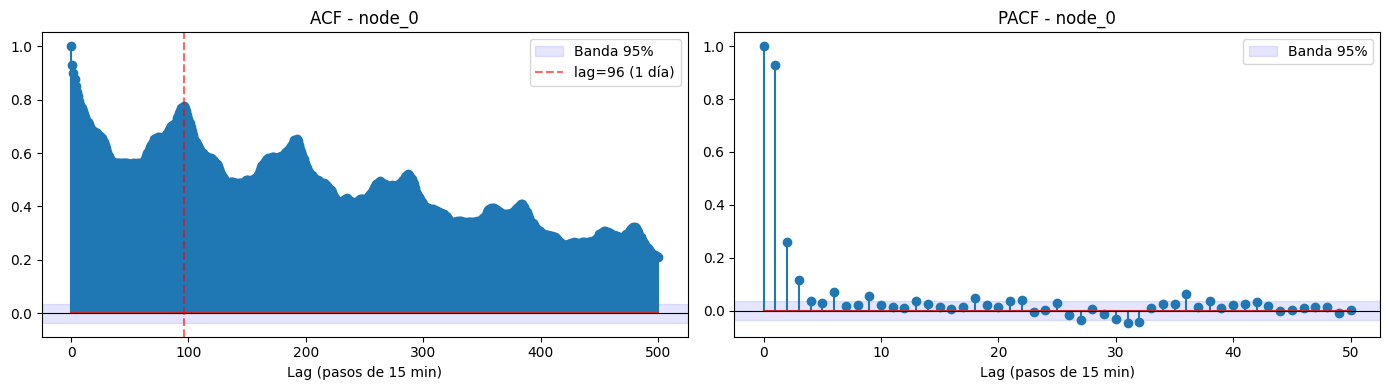

In [4]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
import numpy as np

# --- 1. Test de estacionariedad (ADF) sobre un nodo representativo ---
node_test = "node_0"
adf_result = adfuller(speed_df[node_test].dropna())
print(f"ADF Statistic (node_0): {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Interpretación:", "Serie ESTACIONARIA (rechazamos H0)" if adf_result[1] < 0.05
      else "Serie NO estacionaria (no rechazamos H0)")

# --- 2. ACF y PACF ---
serie = speed_df[node_test].values
n = len(serie)
conf = 1.96 / np.sqrt(n)  # banda de significancia al 95%

acf_vals = acf(serie, nlags=500, fft=True)
pacf_vals = pacf(serie, nlags=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- ACF ---
axes[0].stem(range(500+1), acf_vals)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhspan(-conf, conf, color="blue", alpha=0.1, label="Banda 95%")
axes[0].axvline(96, color="red", ls="--", alpha=0.6, label="lag=96 (1 día)")
axes[0].set_title(f"ACF - {node_test}")
axes[0].set_xlabel("Lag (pasos de 15 min)")
axes[0].legend(loc="upper right")

# --- PACF ---
axes[1].stem(range(50+1), pacf_vals)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhspan(-conf, conf, color="blue", alpha=0.1, label="Banda 95%")
axes[1].set_title(f"PACF - {node_test}")
axes[1].set_xlabel("Lag (pasos de 15 min)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [5]:
sig_pacf_lags = [k for k in range(1, len(pacf_vals)) if abs(pacf_vals[k]) > conf]

threshold = 0.05
sig_pacf_lags_practical = [k for k in sig_pacf_lags if abs(pacf_vals[k]) > threshold]
print("Lags PACF relevantes en magnitud:", sig_pacf_lags_practical)

Lags PACF relevantes en magnitud: [1, 2, 3, 6, 9, 36]


````{admonition} Lectura
:class: tip

La ACF muestra picos periódicos cada 96 pasos (24h), confirmando **estacionalidad diaria**: justifica incluir `lag_96` como feature. La PACF cae rápido tras el lag 1 en magnitud, con los lags **1, 2 y 3** como los más relevantes de corto plazo, consistente con incluir `lag_1`, `lag_2` y `lag_3`. Además, con un umbral práctico de $|PACF| > 0.05$, destacan tres lags adicionales aislados (**6, 9 y 36**), que podrían evaluarse como features complementarios según su aporte al modelo. El test de significancia (banda de Bartlett, $\alpha = 0.05$) marca muchos más lags como distintos de cero, algo esperable dado el tamaño grande de la muestra ($n$), pero sus magnitudes son marginales y no aportan información práctica adicional, por lo que se descartan como features.
````

In [6]:
# --- 3. Índice de Moran I (autocorrelación espacial), todos los instantes ---
def moran_I_fast(x, A):
    '''Índice de Moran I vectorizado: cuantifica autocorrelación espacial
    de un vector de observaciones x (una por nodo) dada la matriz A.'''
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_c = x - x.mean()
    num = x_c @ A @ x_c
    den = np.sum(x_c ** 2)
    W = A.sum()
    return (N / W) * (num / den)

morans_full = [moran_I_fast(speed_df.iloc[t].values, A) for t in range(speed_df.shape[0])]

E_I = -1 / (N - 1)  # valor esperado bajo H0 (aleatoriedad espacial)
print(f"Moran's I promedio (todos los instantes): {np.mean(morans_full):.4f}")
print(f"Desviación estándar: {np.std(morans_full):.4f}")
print(f"Valor esperado bajo H0 (sin autocorrelación espacial): {E_I:.4f}")

Moran's I promedio (todos los instantes): 0.4913
Desviación estándar: 0.0601
Valor esperado bajo H0 (sin autocorrelación espacial): -0.0065


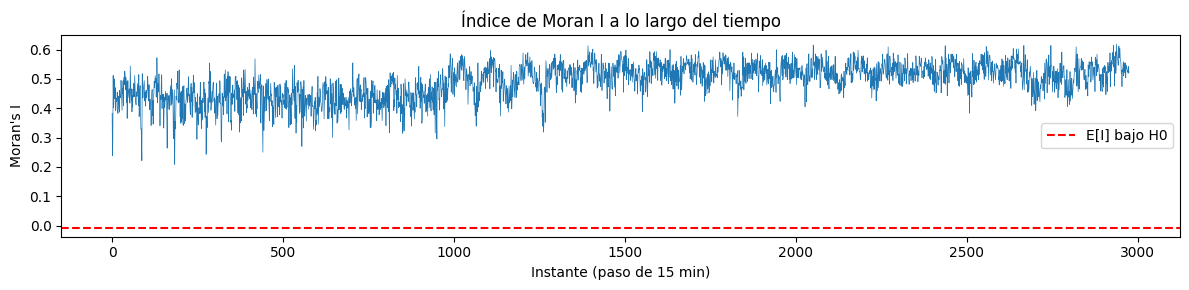

In [7]:
plt.figure(figsize=(12,3))
plt.plot(morans_full, lw=0.5)
plt.axhline(E_I, color="red", ls="--", label="E[I] bajo H0")
plt.title("Índice de Moran I a lo largo del tiempo")
plt.xlabel("Instante (paso de 15 min)")
plt.ylabel("Moran's I")
plt.legend()
plt.tight_layout()
plt.show()

```{admonition} Lectura
:class: tip

- El índice de Moran $I$ se mantiene **estable entre 0.4 y 0.6** a lo largo de los $\approx 3000$ instantes, muy por encima del valor esperado bajo $H_{0}$ ($\approx 0$, línea roja). Esto confirma **autocorrelación espacial positiva, fuerte y persistente**: en todo momento (no solo en promedio), los nodos cercanos presentan velocidades similares, no es un artefacto puntual sino una propiedad estructural de la red vial. 
- La baja dispersión (sin caídas hacia 0 ni valores negativos) indica que esta dependencia espacial **no depende de la hora del día**, por lo que conviene incorporar información de vecinos espaciales (ej. GNN/GCN, features de agregación espacial) de forma constante en el modelo, no solo en ciertos periodos.

- **Rangos de referencia para $|I|$** (regla práctica, no un estándar universal):

| Rango | Interpretación |
|---|---|
| 0.0 – 0.1 | Autocorrelación espacial nula o despreciable |
| 0.1 – 0.3 | Débil |
| 0.3 – 0.5 | Moderada |
| 0.5 – 0.7 | Fuerte |
| 0.7 – 1.0 | Muy fuerte |

- Con $I \approx 0.4–0.6$, la red se ubica en el rango **moderado a fuerte**, evidencia sólida a favor de modelar explícitamente la dependencia espacial entre nodos.
```

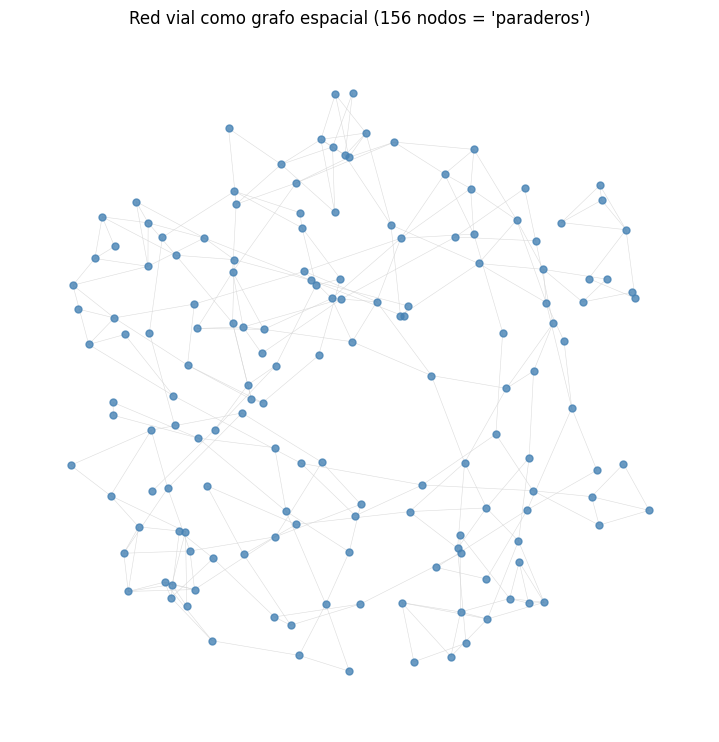

In [8]:
# Visualización 1: la red como grafo (estructura espacial)
G = nx.from_numpy_array(A)
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(G, seed=42, k=0.25)
nx.draw(G, pos, node_size=25, node_color="steelblue", edge_color="lightgray",
        width=0.4, alpha=0.8)
plt.title("Red vial como grafo espacial (156 nodos = 'paraderos')")
plt.show()

```{admonition} Nota
:class: note

`k` en `spring_layout` no se calcula desde los datos: es un parámetro estético que controla la distancia entre nodos en el layout de fuerzas (Fruchterman-Reingold), donde repulsión $\propto k^2/d$ y atracción $\propto d^2/k$. Por defecto NetworkX usa $k = 1/\sqrt{N}$ (aquí ≈0.08 para 156 nodos); `k=0.25` solo separa más los nodos visualmente, sin afectar ningún cálculo del análisis.
```

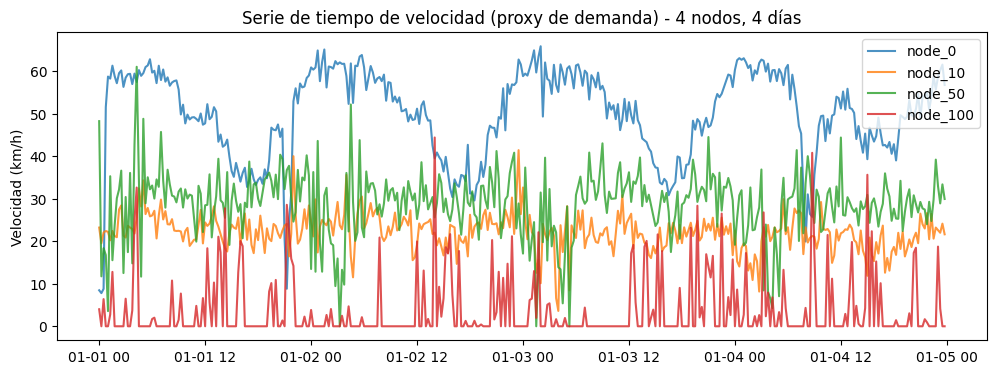

In [9]:
# Visualización 2: series de tiempo de 4 nodos (dimensión temporal)
fig, ax = plt.subplots(figsize=(12, 4))
for node in ["node_0", "node_10", "node_50", "node_100"]:
    ax.plot(speed_df.index[:4*96], speed_df[node].iloc[:4*96], label=node, alpha=0.8)
ax.set_title("Serie de tiempo de velocidad (proxy de demanda) - 4 nodos, 4 días")
ax.set_ylabel("Velocidad (km/h)")
ax.legend()
plt.show()


- Se grafican 4 de los 156 nodos para legibilidad.
- `4*96` = 4 días (96 = 4 obs/hora × 24h). Dado que cada observación es de 15 min: 60/15 = 4 obs/hora × 24h = 96 obs/día.
- Se observa estacionalidad diaria (horas pico) y niveles heterogéneos por nodo, evidencia de la dimensión **temporal**.

**Analogía con el reto de buses:** cada columna = demanda de pasajeros en un paradero; `adj_df` = paraderos que comparten ruta o están cerca. Toda el resto del análisis aplica igual.


### ¿Qué hacer si no tienes la matriz de adyacencia? Tres métodos para construirla

En la práctica, la mayoría de los conjuntos de datos reales (por ejemplo, tu propio registro de demanda de pasajeros por paradero) **no vienen con una matriz de adyacencia lista para usar** como sí ocurre con SZ-Taxi. Es responsabilidad del analista **construir $A$** a partir de la información disponible. A continuación se presentan tres métodos, ordenados según qué información de entrada requieren, todos con su formalización matemática y una implementación mínima que se puede adaptar directamente a su propio problema (paraderos de bus, sucursales, sensores, etc.).

| Método | Información de entrada necesaria | Cuándo usarlo |
|---|---|---|
| **1. KNN geográfico** | Coordenadas (latitud, longitud) de cada nodo | Tienes ubicación física de cada unidad (paraderos, sensores, tiendas) |
| **2. Kernel gaussiano de distancia** | Coordenadas o cualquier matriz de distancias | Quieres pesos continuos (no solo binarios) que decaigan suavemente con la distancia, como en T-GCN/DCRNN |
| **3. Correlación entre series de tiempo** | Solo las series de tiempo (sin coordenadas) | No tienes coordenadas, pero sí historial temporal de cada nodo |

#### Método 1: vecinos más cercanos (KNN) sobre coordenadas geográficas

Si cada nodo $i$ tiene una posición geográfica $(\text{lat}_i, \text{lon}_i)$, el procedimiento es:

1. Calcular la matriz de distancias $D \in \mathbb{R}^{N\times N}$ entre todos los pares de nodos. La distancia correcta para coordenadas geográficas **no es la euclidiana**, sino la **distancia de Haversine** (que tiene en cuenta la curvatura de la Tierra):

$$
D_{ij} = 2R \cdot \arcsin\left(\sqrt{\sin^2\!\Big(\frac{\Delta\text{lat}}{2}\Big) + \cos(\text{lat}_i)\cos(\text{lat}_j)\sin^2\!\Big(\frac{\Delta\text{lon}}{2}\Big)}\right)
$$

donde $R\approx 6371$ km es el radio de la Tierra, $\Delta\text{lat}=\text{lat}_j-\text{lat}_i$ y $\Delta\text{lon}=\text{lon}_j-\text{lon}_i$ (en radianes).

2. Para cada nodo $i$, conectar con sus $k$ vecinos de menor distancia:

$$
A_{ij} = \mathbb{1}\big[j \in \text{kNN}(i)\big]
$$

3. **Simetrizar** la matriz (si $A$ no es simétrica, un par $(i,j)$ puede quedar como "vecino en un solo sentido"; se corrige con $A \leftarrow \max(A, A^\top)$), porque la matriz de adyacencia de un grafo no dirigido debe ser simétrica por definición.


In [10]:
import numpy as np
import pandas as pd

np.random.seed(0)
N = 8
coords = pd.DataFrame({
    "node_id": [f"node_{i}" for i in range(N)],
    "lat": np.random.uniform(10.90, 10.99, N),
    "lon": np.random.uniform(-74.85, -74.75, N),
})
print(coords)

def haversine_matrix(lat, lon):
    """Matriz N x N de distancias en km entre todos los pares de coordenadas (lat, lon)."""
    R = 6371.0  # radio de la Tierra en km
    lat_r = np.radians(lat.values)[:, None]
    lon_r = np.radians(lon.values)[:, None]
    dlat = lat_r - lat_r.T
    dlon = lon_r - lon_r.T
    a = np.sin(dlat/2)**2 + np.cos(lat_r) * np.cos(lat_r.T) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

D = haversine_matrix(coords["lat"], coords["lon"])
print("\nMatriz de distancias (km):")
print(np.round(D, 2))


  node_id        lat        lon
0  node_0  10.949393 -74.753634
1  node_1  10.964367 -74.811656
2  node_2  10.954249 -74.770827
3  node_3  10.949039 -74.797111
4  node_4  10.938129 -74.793196
5  node_5  10.958130 -74.757440
6  node_6  10.939383 -74.842896
7  node_7  10.980260 -74.841287

Matriz de distancias (km):
[[ 0.    6.55  1.95  4.75  4.5   1.06  9.81 10.17]
 [ 6.55  0.    4.6   2.33  3.55  5.96  4.4   3.69]
 [ 1.95  4.6   0.    2.93  3.03  1.52  8.04  8.22]
 [ 4.75  2.33  2.93  0.    1.29  4.45  5.11  5.94]
 [ 4.5   3.55  3.03  1.29  0.    4.49  5.43  7.04]
 [ 1.06  5.96  1.52  4.45  4.49  0.    9.56  9.48]
 [ 9.81  4.4   8.04  5.11  5.43  9.56  0.    4.55]
 [10.17  3.69  8.22  5.94  7.04  9.48  4.55  0.  ]]


In [11]:
def knn_adjacency(D, k=2):
    """Construye A binaria conectando cada nodo con sus k vecinos más cercanos
    (excluyendo la distancia consigo mismo), y luego simetriza."""
    N = D.shape[0]
    A = np.zeros_like(D)
    for i in range(N):
        nearest = np.argsort(D[i])[1:k+1]  # [0] sería el propio nodo (distancia 0)
        A[i, nearest] = 1
    return np.maximum(A, A.T)  # simetrización: si A es vecino de B, B es vecino de A

A_knn = knn_adjacency(D, k=2)
print("Matriz de adyacencia KNN (k=2), binaria y simétrica:")
print(A_knn.astype(int))
print(f"\nDensidad resultante: {(A_knn>0).mean():.2%}")


Matriz de adyacencia KNN (k=2), binaria y simétrica:
[[0 0 1 0 0 1 0 0]
 [0 0 0 1 1 0 1 1]
 [1 0 0 0 1 1 0 0]
 [0 1 0 0 1 0 0 0]
 [0 1 1 1 0 0 0 0]
 [1 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 1]
 [0 1 0 0 0 0 1 0]]

Densidad resultante: 31.25%


#### Por qué importa elegir bien el $k$

| $k$ muy pequeño | $k$ muy grande |
|---|---|
| Grafo disperso, puede quedar desconectado (islas de nodos sin vecinos) | Grafo casi completo, pierde la noción de "localidad" |
| Señal espacial débil (poca información compartida entre vecinos) | Costo computacional alto en GNN, sobresuaviza la señal (*over-smoothing*) |

En la práctica: $k=2$ es muy poco; se usa $k=3$–$8$. Cómo elegirlo:
- **Heurística:** $k \approx \sqrt{N}$ o $\log(N)$.
- **Conectividad:** mínimo $k$ sin nodos aislados.
- **Validación empírica:** el que maximice Moran I o minimice el error.
    - Maximizar el índice de Moran I selecciona el $k$ cuya estructura de vecindad mejor refleja la autocorrelación espacial real de los datos. Sin dicha estructura, el índice no muestra un máximo claro.
- **Dominio:** según qué estaciones realmente se influyen (ej. misma vía).

In [12]:
def moran_i(A, y):
    """Índice de Moran I para una señal y sobre un grafo con adyacencia A."""
    N = len(y)
    y_c = y - y.mean()
    W = A.sum()
    num = N * np.sum(A * np.outer(y_c, y_c))
    den = W * np.sum(y_c**2)
    return num / den if den != 0 else np.nan

# Señal simulada por nodo (ej. velocidad promedio por paradero).
# Reemplaza esto por tu variable real cuando la tengas.
np.random.seed(0)
y = np.random.normal(40, 5, N)

resultados = []
for k in range(1, N - 1):  # k va de 1 hasta N-2 (no tiene sentido k >= N-1 con solo 8 nodos)
    A_k = knn_adjacency(D, k=k)
    I = moran_i(A_k, y)
    conectado = np.all(A_k.sum(axis=1) > 0)  # ningún nodo aislado
    resultados.append({"k": k, "moran_I": I, "conectado": conectado,
                        "densidad": (A_k > 0).mean()})

df_k = pd.DataFrame(resultados)
print(df_k)

k_optimo = df_k.loc[df_k["moran_I"].idxmax(), "k"]
print(f"\nMejor k según Moran I: {int(k_optimo)}")

   k   moran_I  conectado  densidad
0  1 -0.106319       True   0.18750
1  2 -0.098971       True   0.31250
2  3 -0.247466       True   0.46875
3  4 -0.275390       True   0.59375
4  5 -0.204574       True   0.75000
5  6 -0.115881       True   0.84375

Mejor k según Moran I: 2


#### Método 2: kernel gaussiano de distancia (pesos continuos)

En lugar de una adyacencia binaria (0/1), muchos modelos espacio-temporales de la literatura (por ejemplo, DCRNN, {cite}`li2018diffusion`, y el propio T-GCN de {cite}`zhao2020tgcn`) construyen $A$ con **pesos continuos** que decaen suavemente con la distancia, usando un **kernel gaussiano** (también llamado *thresholded Gaussian kernel*):

$$
A_{ij} = \begin{cases}
\exp\left(-\dfrac{D_{ij}^2}{2\sigma^2}\right) & \text{si este valor} \ge \epsilon \\[4pt]
0 & \text{en otro caso}
\end{cases}
$$

donde $\sigma$ (ancho de banda del kernel, típicamente la desviación estándar de las distancias observadas) controla qué tan rápido decae la influencia con la distancia, y $\epsilon$ es un umbral de esparsidad que fuerza a cero las conexiones muy débiles (para mantener $A$ dispersa, como discutimos en la Sección 2.1). Esta construcción tiene una ventaja formal sobre el KNN binario: **respeta la intuición de que la influencia espacial decae de forma continua**, en vez de imponer un corte abrupto en el $k$-ésimo vecino.


In [13]:
def gaussian_kernel_adjacency(D, sigma=None, epsilon=0.5):
    """Convierte una matriz de distancias D en una matriz de adyacencia con pesos
    continuos en [0,1] usando un kernel gaussiano (Li et al., 2018, DCRNN).

    sigma: ancho de banda del kernel (si None, se usa la desviación estándar de D).
    epsilon: umbral de esparsidad, pesos por debajo de este valor se ponen en 0.
    """
    if sigma is None:
        sigma = D[D > 0].std()
    W = np.exp(-(D ** 2) / (2 * sigma ** 2))
    np.fill_diagonal(W, 0)   # sin auto-lazos (un nodo no es "vecino" de sí mismo)
    W[W < epsilon] = 0        # esparsificamos: solo conexiones "suficientemente fuertes"
    return W

A_gauss = gaussian_kernel_adjacency(D, epsilon=0.3)
print("Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):")
print(np.round(A_gauss, 2))
print(f"\nDensidad resultante: {(A_gauss>0).mean():.2%}")


Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):
[[0.   0.   0.75 0.   0.   0.92 0.   0.  ]
 [0.   0.   0.   0.67 0.4  0.   0.   0.37]
 [0.75 0.   0.   0.53 0.51 0.84 0.   0.  ]
 [0.   0.67 0.53 0.   0.88 0.   0.   0.  ]
 [0.   0.4  0.51 0.88 0.   0.   0.   0.  ]
 [0.92 0.   0.84 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.37 0.   0.   0.   0.   0.   0.  ]]

Densidad resultante: 28.12%


**Mayor densidad = más conexiones = menos disperso = mayor costo computacional** (más aristas por las que propagar información en cada capa GCN).

| Densidad | Grafo | Costo computacional |
|---|---|---|
| Baja (ej. 15%) | Disperso, pocas conexiones | Bajo |
| Alta (ej. 80%) | Denso, casi todos conectados | Alto |

**Para los dos ejemplos** (KNN 31.25%, kernel gaussiano 28.12%) caen en un rango **bajo-moderado**: ambos grafos son dispersos, con costo computacional manejable.

**¿Cuándo se considera "alta"?** No hay un umbral universal fijo, pero como referencia práctica en grafos para GNN: **<30%** se considera disperso (deseable), **30–60%** moderado, **>60%** denso (riesgo de *over-smoothing* y alto costo). Lo importante no es el número absoluto sino que el grafo **no se acerque a estar completo** ($100\%$), donde toda noción de "vecindad local" se pierde.

**Over-smoothing:** con demasiadas capas GCN, todos los nodos terminan pareciéndose entre sí y el modelo pierde poder predictivo.

#### Visualización comparativa de los dos grafos construidos

Grafiquemos los tres grafos resultantes para poder ver cómo cada método produce una estructura distinta a partir de la misma información base.


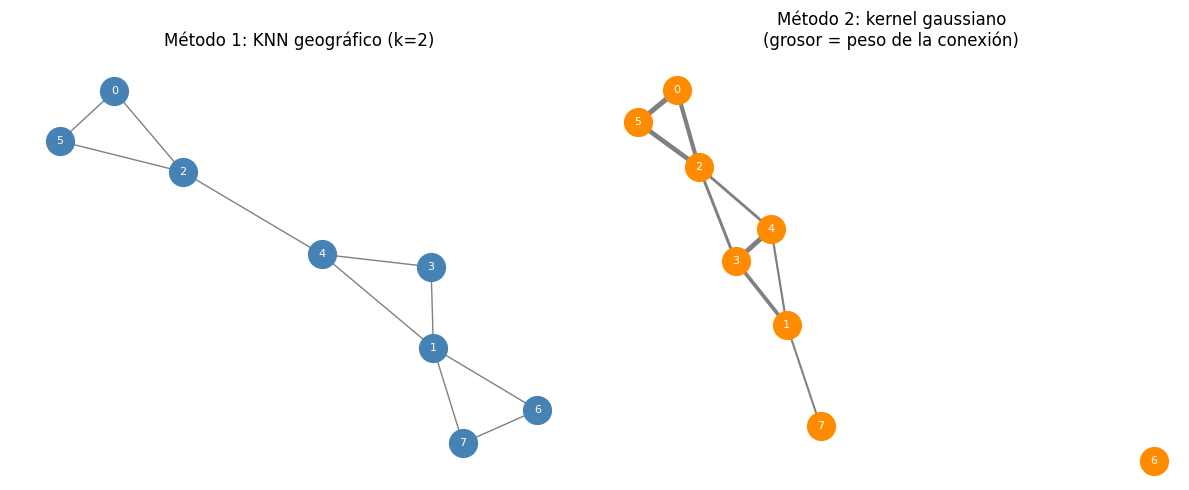

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafo 1: KNN geográfico
G_knn = nx.from_numpy_array(A_knn)
pos_knn = nx.spring_layout(G_knn, seed=42)
nx.draw(G_knn, pos_knn, ax=axes[0], node_size=400, node_color="steelblue",
        with_labels=True, font_size=8, font_color="white", edge_color="gray")
axes[0].set_title("Método 1: KNN geográfico (k=2)")

# Grafo 2: kernel gaussiano (grosor de arista proporcional al peso)
G_gauss = nx.from_numpy_array(A_gauss)
pos_gauss = nx.spring_layout(G_gauss, seed=42) # Calcula posiciones (x, y) para dibujar el grafo
weights = [G_gauss[u][v]["weight"]*4 for u, v in G_gauss.edges()]
nx.draw(G_gauss, pos_gauss, ax=axes[1], node_size=400, node_color="darkorange",
        with_labels=True, font_size=8, font_color="white", edge_color="gray", width=weights)
axes[1].set_title("Método 2: kernel gaussiano\n(grosor = peso de la conexión)")

plt.tight_layout()
plt.show()


- **KNN fuerza $k$ vecinos por nodo (garantiza conectividad)**; el kernel gaussiano solo conecta si $W_{ij}>\epsilon$, sin garantías. **Node_6 queda aislado porque sus distancias a todos los demás superan el umbral dado $\sigma$**. Solución: bajar `epsilon` o exigir un mínimo de vecinos como en KNN.

````{admonition} Recomendaciones
:class: tip

- Si tienen coordenadas de paraderos/sucursales: usar **Método 1 (KNN)** o **Método 2 (kernel gaussiano)**; el segundo es preferible si van a alimentar la matriz a un modelo GCN/STGNN (Sección 8.4), porque los pesos continuos aportan más información que una conexión binaria.
- Si **no** tienen coordenadas pero sí historial temporal suficientemente largo (mínimo unas semanas de datos, para que la correlación sea estable): usar el **Método 3 (correlación)**.
- En cualquier caso, **después** de construir $A$ por cualquiera de estos métodos, deben verificar el índice de Moran I (Sección 1.2) sobre su propia señal real, exactamente como hicimos en la Sección 2.2, para confirmar que el grafo construido captura efectivamente dependencia espacial explotable, y no solo ruido.
````


## Gradient Boosting: derivación matemática completa

### El problema de optimización funcional

Sea un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^n$ y una función de pérdida diferenciable $L(y, F(x))$. Buscamos:

$$F^*(x) = \arg\min_{F} \; \mathbb{E}_{y,x}\big[L(y, F(x))\big]$$

{cite}`friedman2001greedy` propone resolver esto **numéricamente**, no analíticamente, aproximando $F^*$ como una suma de funciones base (árboles) construidas de forma **greedy stagewise**:

$$F_M(x) = \sum_{m=0}^{M} \beta_m h_m(x; a_m)$$

donde $h_m$ es un árbol de regresión con parámetros $a_m$ (splits, hojas) y $\beta_m$ es su peso.

### Descenso de gradiente en el espacio de funciones

**Paso clave (la idea central del *boosting*):** en lugar de optimizar sobre parámetros de un modelo fijo, tratamos $F$ como un **vector de valores** $\big(F(x_1), \dots, F(x_n)\big) \in \mathbb{R}^n$ y aplicamos descenso de gradiente **directamente en ese espacio funcional**.

En la iteración $m$, el gradiente de la pérdida total respecto a $F(x_i)$ evaluado en $F=F_{m-1}$ es:

$$
g_i^{(m)} = \left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}
$$

La dirección de **máximo descenso** (negativo del gradiente) es $-g_i^{(m)}$. Como no podemos movernos libremente en $\mathbb{R}^n$ (necesitamos que el modelo generalice a datos nuevos), **proyectamos** esa dirección sobre el espacio de funciones representables por un árbol, ajustando $h_m$ para que se parezca lo más posible al gradiente negativo:

$$
a_m = \arg\min_{a} \sum_{i=1}^n \Big[-g_i^{(m)} - h_m(x_i; a)\Big]^2
$$

es decir: **entrenamos un árbol de regresión para predecir el gradiente negativo (pseudo-residuo)**. Finalmente, se determina el tamaño de paso óptimo por *line search*:

$$
\beta_m = \arg\min_{\beta} \sum_{i=1}^n L\big(y_i,\, F_{m-1}(x_i) + \beta\, h_m(x_i; a_m)\big)
$$

y se actualiza $F_m(x) = F_{m-1}(x) + \eta\, \beta_m h_m(x)$, con $\eta \in (0,1]$ la **tasa de aprendizaje** (*shrinkage*), que regulariza el modelo ({cite}`friedman2001greedy`, Sec. 6).

### Demostración: bajo pérdida cuadrática, el pseudo-residuo es el residuo ordinario

**Proposición.** Si $L(y, F(x)) = \tfrac{1}{2}(y - F(x))^2$ (pérdida cuadrática, el caso de regresión que usamos en este cuaderno), entonces el pseudo-residuo $-g_i^{(m)}$ es exactamente el residuo ordinario $y_i - F_{m-1}(x_i)$.

**Demostración.**

$$
\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} = \frac{\partial}{\partial F(x_i)}\left[\frac{1}{2}\big(y_i - F(x_i)\big)^2\right] = -\big(y_i - F(x_i)\big)
$$

Evaluando en $F=F_{m-1}$:

$$
g_i^{(m)} = -\big(y_i - F_{m-1}(x_i)\big) \quad\Longrightarrow\quad -g_i^{(m)} = y_i - F_{m-1}(x_i)
$$

$\blacksquare$

**Consecuencia práctica:** bajo pérdida cuadrática (nuestro caso, `objective="regression"` = MSE en LightGBM), el algoritmo de *Gradient Boosting* se reduce exactamente a: *"ajusta un árbol a los residuos del modelo anterior, y suma esa predicción (escalada por $\eta$) al modelo acumulado"*, la intuición clásica de *boosting* que se enseña de forma informal, ahora derivada rigurosamente como caso particular del descenso de gradiente funcional.

### Algoritmo completo (Gradient Boosting genérico)

> **Algoritmo** {cite}`friedman2001greedy`**.**
> 1. Inicializar $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (para pérdida cuadrática: $F_0(x)=\bar y$).
> 2. **Para** $m = 1, \dots, M$:
> a. Calcular pseudo-residuos: $r_i^{(m)} = -\left[\dfrac{\partial L(y_i,F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$
> b. Ajustar un árbol de regresión $h_m(x)$ a $\{(x_i, r_i^{(m)})\}$
> c. Calcular el paso óptimo $\beta_m$ (o usar $\beta_m=1$ y controlar solo con $\eta$, como en LightGBM)
> d. Actualizar: $F_m(x) = F_{m-1}(x) + \eta\,\beta_m\, h_m(x)$
> 3. **Retornar** $F_M(x)$.

### Implementación mínima desde cero

Para consolidar la demostración anterior, implementamos un **Gradient Boosting simplificado desde cero** con `DecisionTreeRegressor` de `scikit-learn` como aprendiz débil, y verificamos que el resultado converge al mismo tipo de comportamiento que `lightgbm` (aunque sin las optimizaciones de la Sección 2.4).

MSE final (in-sample) del GBM 'desde cero': 97.763


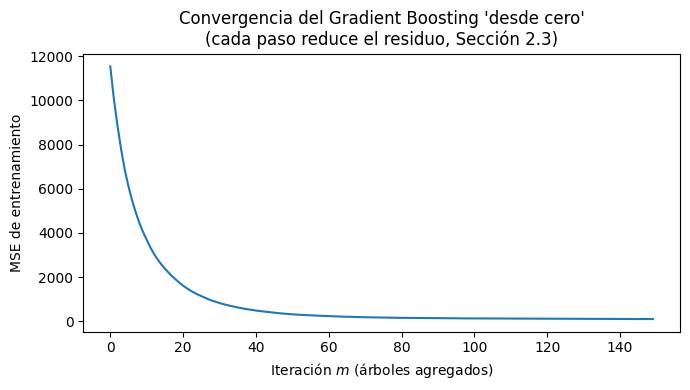

In [15]:
import lightgbm as lgb  # se importa aquí porque se usa en el benchmark de la Sección 4.2

from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Dataset sintético sencillo para ilustrar el algoritmo (no espacio-temporal aún)
X_toy, y_toy = make_regression(n_samples=500, n_features=5, noise=15.0, random_state=42)

class SimpleGradientBoosting:
    '''Gradient Boosting minimalista para regresión con pérdida cuadrática (MSE).
    Implementa exactamente el algoritmo de la Sección 2.4, paso a paso,
    para que el estudiante vea la correspondencia 1:1 entre fórmula y código.'''

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.F0 = None

    def fit(self, X, y):
        # Paso 1: F_0(x) = argmin_c sum_i L(y_i, c) -> para MSE, c = media de y
        self.F0 = np.mean(y)
        F = np.full(shape=y.shape, fill_value=self.F0, dtype=float)

        self.train_mse_ = []
        for m in range(self.n_estimators):
            # Paso 2a: pseudo-residuo = -dL/dF = y - F  (demostrado en la Sección 2.3)
            residuals = y - F

            # Paso 2b: ajustar un árbol a los pseudo-residuos
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=m)
            tree.fit(X, residuals)
            h_m = tree.predict(X)

            # Paso 2d: actualizar F_m = F_{m-1} + eta * h_m  (beta_m=1, regularizado por eta)
            F = F + self.learning_rate * h_m
            self.trees.append(tree)
            self.train_mse_.append(mean_squared_error(y, F))
        return self

    def predict(self, X):
        F = np.full(shape=(X.shape[0],), fill_value=self.F0, dtype=float)
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F

sgb = SimpleGradientBoosting(n_estimators=150, learning_rate=0.1, max_depth=3).fit(X_toy, y_toy)
pred_toy = sgb.predict(X_toy)
print(f"MSE final (in-sample) del GBM 'desde cero': {mean_squared_error(y_toy, pred_toy):.3f}")

plt.figure(figsize=(7,4))
plt.plot(sgb.train_mse_)
plt.xlabel("Iteración $m$ (árboles agregados)")
plt.ylabel("MSE de entrenamiento")
plt.title("Convergencia del Gradient Boosting 'desde cero'\n(cada paso reduce el residuo, Sección 2.3)")
plt.tight_layout()
plt.show()


````{admonition} Lectura
:class: tip

La curva es **monótonamente decreciente** (o casi) porque cada árbol nuevo se ajusta explícitamente al error del ensamble anterior: es la validación empírica directa de la demostración de la Sección 2.3. En la práctica real usamos `lightgbm` en vez de esta clase didáctica porque LightGBM añade las tres optimizaciones que demostramos en la Sección 2.4.
````


## LightGBM: fundamentos y demostración de sus innovaciones algorítmicas

**LightGBM** {cite}`ke2017lightgbm` resuelve el mismo problema de optimización de la Sección 2.2, pero introduce tres innovaciones para escalar a datasets grandes y de alta dimensión, como el que construiremos en la Sección 2.5 (miles de filas × decenas de columnas, multiplicado por 156 nodos).

### Selección óptima de *splits*: el criterio de ganancia

Al construir cada árbol $h_m$, la pregunta algorítmica central es: *dado un nodo con pseudo-residuos* $\{r_i\}$*, ¿qué variable y qué umbral de corte minimizan mejor la pérdida?*

Para un nodo que se divide en un subconjunto izquierdo $I_L$ y derecho $I_R$, usando la expansión de Taylor de segundo orden de la pérdida (como en XGBoost/LightGBM, {cite}`chen2016xgboost`; {cite}`ke2017lightgbm`), se define la **ganancia del split**:

$$
\text{Gain} = \frac{1}{2}\left[\frac{\left(\sum_{i\in I_L} g_i\right)^2}{\sum_{i\in I_L} h_i + \lambda} + \frac{\left(\sum_{i\in I_R} g_i\right)^2}{\sum_{i\in I_R} h_i + \lambda} - \frac{\left(\sum_{i\in I} g_i\right)^2}{\sum_{i\in I} h_i + \lambda}\right] - \gamma
$$

donde $g_i$ es el gradiente de primer orden (para MSE: $g_i = F(x_i)-y_i$), $h_i$ el gradiente de segundo orden ($h_i=1$ para MSE), $\lambda$ un término de regularización $L_2$ sobre los pesos de las hojas, y $\gamma$ el costo mínimo de complejidad para permitir el split. Encontrar el split que **maximiza** este `Gain` sobre todas las variables y umbrales posibles es el paso computacionalmente más costoso del entrenamiento; aquí es donde LightGBM introduce sus optimizaciones.

### Histogram-based splitting

**Problema:** un algoritmo *exact greedy* evalúa **todos** los valores únicos de cada variable continua como candidatos a umbral: costo $O(n \cdot d)$ por nivel del árbol, donde $n$=filas, $d$=columnas.

**Solución de LightGBM:** discretizar cada variable continua en $B$ *bins* (por defecto $B=255$), construyendo un histograma. El costo de encontrar el mejor split se reduce a $O(B \cdot d)$ por nodo, **independiente de $n$** una vez construido el histograma (construir el histograma cuesta $O(n\cdot d)$ una sola vez por nivel, pero la búsqueda de split es $O(B\cdot d) \ll O(n\cdot d)$ cuando $n \gg B$, como en nuestro dataset de $\approx$ 680,000 filas tras el *feature engineering*).

Lo demostramos empíricamente:


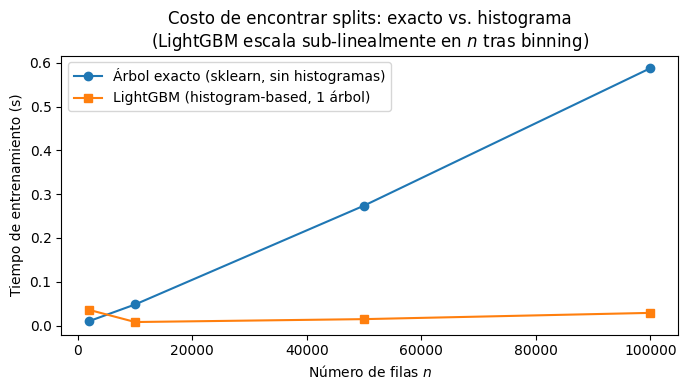

Tiempos árbol exacto: ['0.010s', '0.048s', '0.274s', '0.588s']
Tiempos LightGBM:     ['0.036s', '0.008s', '0.015s', '0.029s']


In [16]:
import time
from sklearn.tree import DecisionTreeRegressor

# Comparamos el costo de encontrar splits: árbol exacto (sklearn, sin histogramas)
# vs. LightGBM (histogram-based), a medida que crece n
sizes = [2_000, 10_000, 50_000, 100_000]
times_exact, times_hist = [], []

for n in sizes:
    X_bench, y_bench = make_regression(n_samples=n, n_features=10, noise=10.0, random_state=1)

    # "Exact greedy" (aproximado con sklearn, que evalúa todos los umbrales únicos)
    t0 = time.time()
    DecisionTreeRegressor(max_depth=6).fit(X_bench, y_bench)
    times_exact.append(time.time() - t0)

    # LightGBM (histogram-based, max_bin=255 por defecto)
    t0 = time.time()
    lgb.LGBMRegressor(max_depth=6, n_estimators=1, verbosity=-1).fit(X_bench, y_bench)
    times_hist.append(time.time() - t0)

plt.figure(figsize=(7,4))
plt.plot(sizes, times_exact, "o-", label="Árbol exacto (sklearn, sin histogramas)")
plt.plot(sizes, times_hist, "s-", label="LightGBM (histogram-based, 1 árbol)")
plt.xlabel("Número de filas $n$")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Costo de encontrar splits: exacto vs. histograma\n(LightGBM escala sub-linealmente en $n$ tras binning)")
plt.legend()
plt.tight_layout()
plt.show()

print("Tiempos árbol exacto:", [f'{t:.3f}s' for t in times_exact])
print("Tiempos LightGBM:    ", [f'{t:.3f}s' for t in times_hist])


````{admonition} Lectura
:class: tip

El árbol exacto de `sklearn` crece su tiempo de entrenamiento con $n$ de forma mucho más pronunciada que LightGBM, cuya curva es visiblemente más plana: confirmación empírica de la ventaja de *histogram-based splitting* a escala.

### Leaf-wise growth (vs. Level-wise / Depth-wise)

La mayoría de implementaciones clásicas (incluido el *exact greedy* de XGBoost por defecto) crecen el árbol **nivel por nivel** (*level-wise*): se expanden **todas** las hojas del nivel actual antes de pasar al siguiente, sin importar cuánta ganancia aporta cada una.

**LightGBM** crece **hoja por hoja** (*leaf-wise*): en cada paso, expande **solo la hoja con mayor `Gain`** de todo el árbol actual, sin restricción de nivel.

**Proposición (informal, {cite}`ke2017lightgbm`, Sec. 3):** para un mismo número de hojas $K$, el crecimiento *leaf-wise* alcanza una pérdida de entrenamiento **igual o menor** que el *level-wise*, porque *leaf-wise* es la estrategia **voraz óptima local**: en cada paso elige, entre *todas* las hojas expandibles del árbol completo, la que reduce más la función objetivo, mientras que *level-wise* está restringido a expandir hojas de un nivel fijo aunque exista una ganancia mayor disponible en otra rama.

**Costo de esta ventaja:** *leaf-wise* puede producir árboles más profundos y desbalanceados, con mayor riesgo de sobreajuste en datasets pequeños; por eso LightGBM expone el hiperparámetro `max_depth` (o `num_leaves`, más directo) como control de regularización explícito, que usaremos en la Sección 2.7.

Verificamos experimentalmente la superioridad en pérdida de entrenamiento para el mismo presupuesto de hojas:
````


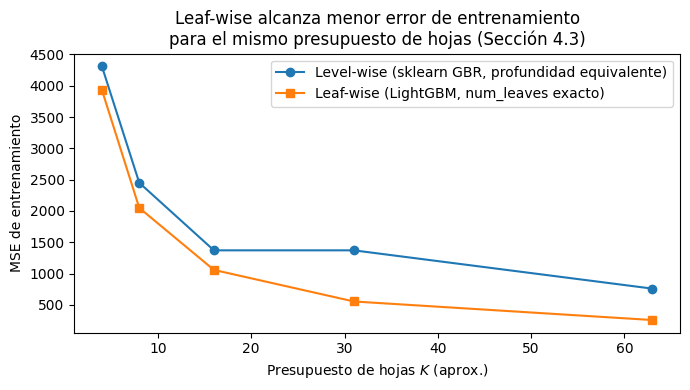

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

X_leaf, y_leaf = make_regression(n_samples=3000, n_features=15, noise=20.0, random_state=7)

num_leaves_grid = [4, 8, 16, 31, 63]
mse_levelwise, mse_leafwise = [], []

for k in num_leaves_grid:
    # Level-wise aproximado: GradientBoostingRegressor de sklearn crece por nivel;
    # fijamos max_depth = log2(k) para presupuesto de hojas comparable
    depth_equiv = max(1, int(np.log2(k)))
    gbr = GradientBoostingRegressor(n_estimators=50, max_depth=depth_equiv, random_state=0)
    gbr.fit(X_leaf, y_leaf)
    mse_levelwise.append(mean_squared_error(y_leaf, gbr.predict(X_leaf)))

    # Leaf-wise real: LightGBM con num_leaves=k explícito
    lgbm = lgb.LGBMRegressor(n_estimators=50, num_leaves=k, verbosity=-1, random_state=0)
    lgbm.fit(X_leaf, y_leaf)
    mse_leafwise.append(mean_squared_error(y_leaf, lgbm.predict(X_leaf)))

plt.figure(figsize=(7,4))
plt.plot(num_leaves_grid, mse_levelwise, "o-", label="Level-wise (sklearn GBR, profundidad equivalente)")
plt.plot(num_leaves_grid, mse_leafwise, "s-", label="Leaf-wise (LightGBM, num_leaves exacto)")
plt.xlabel("Presupuesto de hojas $K$ (aprox.)")
plt.ylabel("MSE de entrenamiento")
plt.title("Leaf-wise alcanza menor error de entrenamiento\npara el mismo presupuesto de hojas (Sección 4.3)")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Engineering espacio-temporal: formalización y construcción

### El lag espacial como convolución de grafo discreta (puente hacia STGNN)

Recordemos de la Sección 1 la matriz de adyacencia normalizada por filas:

$$
A_{\text{norm}} = D^{-1} A, \qquad (A_{\text{norm}})_{ij} = \frac{A_{ij}}{\sum_k A_{ik}}
$$

Dada la señal en el instante $t$, $x_t \in \mathbb{R}^N$ (velocidad de los 156 nodos en ese instante), definimos el **lag espacial** como:

$$
\tilde{x}_t = A_{\text{norm}}\, x_t \qquad\Longleftrightarrow\qquad \tilde{x}_{t,i} = \sum_{j} (A_{\text{norm}})_{ij}\, x_{t,j} = \frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} x_{t,j}
$$

es decir, el promedio de los vecinos de $i$ ponderado por $A_{\text{norm}}$. **Esta operación es matemáticamente idéntica a una capa de convolución de grafo (GCN) de un solo salto sin transformación lineal ni no-linealidad** ({cite}`kipf2017semisupervised` definen la propagación GCN como $H^{(l+1)} = \sigma\big(\hat{A} H^{(l)} W^{(l)}\big)$, con $\hat{A}=D^{-1/2}(A+I)D^{-1/2}$; nuestro $A_{\text{norm}} x_t$ es el caso particular $W=I$, $\sigma=\text{id}$, sin auto-lazo).

**Esta es la observación central de esta sección:** el *feature engineering* manual que hacemos con GBM es una **aproximación de orden cero, hecha a mano, de lo que una GCN aprende automáticamente con parámetros entrenables** $W^{(l)}$ y posiblemente varias capas ($K$ saltos = información de vecinos-de-vecinos hasta distancia $K$ en el grafo). Es la razón formal por la que, en la Sección 2.8, los STGNN pueden superar a GBM+FE cuando la relación espacial es **no lineal** o requiere agregar información de vecinos a **distancia $>1$**.

### Definición formal del vector de características por nodo y evitando *leakage*

Para cada nodo $i$ y cada instante $t$, construimos el vector de features $x_{i,t} \in \mathbb{R}^F$ con los siguientes componentes, **todos calculados usando información estrictamente anterior o igual a $t-1$** (nunca $t$, para no filtrar el futuro al predecir $y_{i,t}$):

$$
x_{i,t} = \Big[\underbrace{y_{i,t-1}, y_{i,t-2}, y_{i,t-3}, y_{i,t-6}, y_{i,t-9}, y_{i,t-36}}_{\text{lags temporales (Sec. 1.5, PACF)}},\; \underbrace{\mu_{i,t-1}^{(w)}, \sigma_{i,t-1}^{(w)}}_{\text{rolling stats}, w\in\{4,96\}},\; \underbrace{\tilde{y}_{i,t-1}}_{\text{lag espacial}},\; \underbrace{h_t, d_t, \mathbb{1}[\text{peak}], \mathbb{1}[\text{weekend}]}_{\text{calendario}}\Big]
$$

donde:
- $y_{i,t-k}$: velocidad observada en el nodo $i$, $k$ pasos atrás (los lags temporales).
- $\mu_{i,t-1}^{(w)}$: media móvil de la velocidad del nodo $i$ sobre una ventana de $w$ pasos, hasta $t-1$.
- $\sigma_{i,t-1}^{(w)}$: desviación estándar móvil, misma ventana.
- $\tilde{y}_{i,t-1} = \sum_j A_{\text{norm}}[i,j]\, y_{j,t-1}$: promedio ponderado de la velocidad de los vecinos de $i$ en $t-1$ (lag espacial, vía $A_{\text{norm}}$).
- $h_t$: hora del día en el instante $t$ (0–23).
- $d_t$: día de la semana en el instante $t$ (0–6).
- $\mathbb{1}[\text{peak}]$: indicador binario de hora pico.
- $\mathbb{1}[\text{weekend}]$: indicador binario de fin de semana.

Los seis lags temporales **no se eligieron a mano**: son los lags con autocorrelación parcial (PACF) estadística *y* prácticamente significativa identificados en la Sección 1.5 ($|\text{PACF}_k| > 1.96/\sqrt{n}$ y $|\text{PACF}_k| > 0.05$). Esto reemplaza la elección intuitiva de "valores redondos" (1 paso, 1 hora, 1 día) por lags derivados empíricamente de los datos — nótese en particular $y_{i,t-36}$, un lag no obvio que solo el análisis estadístico reveló como informativo.

Las ventanas móviles $w\in\{4,96\}$ (1 hora y 1 día, en pasos de 15 min) sí se mantienen por justificación de **dominio** más que estadística: el PACF identifica puntos individuales del pasado relevantes, no la escala óptima de agregación/suavizado; $\mu_{i,t-1}^{(w)} = \frac{1}{w}\sum_{k=1}^{w} y_{i,t-k}$ y $\sigma_{i,t-1}^{(w)}$ (desviación estándar móvil) se calculan con `.shift(1).rolling(w)` para excluir $y_{i,t}$ del cálculo: este es el mecanismo concreto que **previene leakage temporal**: si calculáramos `rolling(w).mean()` sin el `.shift(1)` previo, la ventana incluiría la observación actual $y_{i,t}$, y el modelo "vería" indirectamente la respuesta que intenta predecir.

**Formalización de por qué esto importa (demostración por contraejemplo).** Sea $\hat\mu_{i,t}$ el rolling mean **sin** shift (incorrecto): $\hat\mu_{i,t} = \frac{1}{w}\sum_{k=0}^{w-1} y_{i,t-k} = \frac{1}{w}y_{i,t} + \frac{1}{w}\sum_{k=1}^{w-1}y_{i,t-k}$. El término $\frac{1}{w}y_{i,t}$ es una función lineal directa de la variable objetivo. Un árbol de decisión puede explotar esta correlación espuria para lograr **MAE de entrenamiento artificialmente bajo** que **no se replica en producción** (donde $y_{i,t}$ es exactamente lo que no conocemos al momento de predecir); es el error metodológico más común en proyectos de forecasting aplicado, y el que verificamos deliberadamente NO cometer en la función `build_features` a continuación.

### Implementación

In [ ]:
def build_features(speed_df: pd.DataFrame, A: np.ndarray,
                    lags=(1, 2, 3, 6, 9, 36), roll_windows=(4, 96)):
    '''Construye un dataset "largo" (long format) con features temporales y espaciales
    para un problema de forecasting a 1 paso, multi-nodo.

    Cada feature usa SOLO información hasta t-1 (ver demostración anti-leakage, Sec. 5.2).

    `lags` por defecto: [1, 2, 3, 6, 9, 36], derivados directamente del análisis
    PACF (Sección 2.1.5) -- son los lags con correlación parcial estadística Y
    prácticamente significativa (|PACF| > banda 95% Y > umbral de magnitud 0.05).
    En vez de elegir lags arbitrarios, se usan los que los propios datos indican
    como informativos, evitando tanto features redundantes (lags irrelevantes
    que solo agregan ruido/dimensionalidad) como omitir lags relevantes no
    obvios (ej. lag=36 no es un valor "redondo" como 4 o 96, pero sí aportó
    señal real en el PACF).
    '''
    N = speed_df.shape[1]
    # A_norm: promedio de vecinos por nodo (fila normalizada). Es la "convolución de grafo"
    # discreta de la Sección 2.5.1: A_norm @ x_t = promedio de vecinos de cada nodo en el instante t.
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T   # (T, N): lag espacial EN EL MISMO instante (se shiftea abajo)

    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        df_node["node_id"] = node_idx

        for lag in lags:
            df_node[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            # .shift(1) ANTES de .rolling(w): excluye y_t del promedio (anti-leakage, Sec. 5.2)
            df_node[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            df_node[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()

        # lag espacial: promedio de vecinos en t-1 (evita fuga de información)
        df_node["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)

        # variables de calendario
        df_node["hour"] = df_node.index.hour
        df_node["dow"] = df_node.index.dayofweek
        df_node["is_weekend"] = (df_node["dow"] >= 5).astype(int)
        df_node["is_peak"] = df_node["hour"].isin([7, 8, 17, 18]).astype(int)

        frames.append(df_node)

    full = pd.concat(frames).dropna()
    return full

# lags derivados empíricamente del PACF (Sección 1.5), no elegidos a mano
features_df = build_features(speed_df, A, lags=sig_pacf_lags_practical)
print(features_df.shape)
features_df.head()

(449280, 17)


,y,node_id,lag_1,lag_2,lag_3,lag_6,lag_9,lag_36,rollmean_4,rollstd_4,rollmean_96,rollstd_96,neighbor_avg_lag1,hour,dow,is_weekend,is_peak
2015-01-02 00:00:00,60.918007,0,59.022980,58.438888,56.430925,52.440664,31.318586,36.542006,57.528148,1.411812,47.614696,12.782411,53.894506,0,4,0,0
2015-01-02 00:15:00,60.396915,0,60.918007,59.022980,58.438888,57.143596,52.957944,35.169163,58.702700,1.847586,48.161009,12.199321,53.062382,0,4,0,0
2015-01-02 00:30:00,60.918724,0,60.396915,60.918007,59.022980,56.219801,56.004786,38.450514,59.694198,1.157275,48.708819,11.530600,54.452799,0,4,0,0
2015-01-02 00:45:00,64.916265,0,60.918724,60.396915,60.918007,56.430925,52.440664,36.354205,60.314157,0.895196,49.251624,10.838303,52.421195,0,4,0,0
2015-01-02 01:00:00,57.689628,0,64.916265,60.918724,60.396915,58.438888,57.143596,34.040404,61.787478,2.100293,49.390436,10.953298,56.882952,1,4,0,0


### Verificación empírica anti-*leakage*

Como ejercicio de auditoría (recomendado siempre en proyectos reales), comparamos el desempeño **in-sample** de un modelo entrenado con features correctas vs. features con *leakage* deliberado, para visualizar la magnitud del sesgo optimista que introduce el error de la Sección 5.2.


In [20]:
def build_features_leaky(speed_df, roll_windows=(4,)):
    '''Versión CON leakage deliberado: rolling mean SIN shift previo.
    Solo para fines demostrativos, nunca usar en producción.'''
    frames = []
    for node_idx, node in enumerate(speed_df.columns[:20]):  # subset por velocidad
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        for w in roll_windows:
            df_node[f"rollmean_leaky_{w}"] = speed_df[node].rolling(w).mean()  # SIN shift -> incluye y_t
            df_node[f"rollmean_ok_{w}"] = speed_df[node].shift(1).rolling(w).mean()  # CON shift -> correcto
        frames.append(df_node)
    return pd.concat(frames).dropna()

demo_leak = build_features_leaky(speed_df)

from sklearn.linear_model import LinearRegression
X_leaky = demo_leak[["rollmean_leaky_4"]].values
X_ok = demo_leak[["rollmean_ok_4"]].values
y_demo = demo_leak["y"].values

r2_leaky = LinearRegression().fit(X_leaky, y_demo).score(X_leaky, y_demo)
r2_ok = LinearRegression().fit(X_ok, y_demo).score(X_ok, y_demo)

print(f"R² usando rolling mean CON leakage (incorrecto):  {r2_leaky:.4f}")
print(f"R² usando rolling mean SIN leakage (correcto):     {r2_ok:.4f}")
print(f"Sobreestimación del ajuste por leakage: {(r2_leaky - r2_ok):.4f}")


R² usando rolling mean CON leakage (incorrecto):  0.8651
R² usando rolling mean SIN leakage (correcto):     0.7713
Sobreestimación del ajuste por leakage: 0.0938


````{admonition} Lectura
:class: tip

el $R^2$ con *leakage* es **artificialmente más alto** porque la feature incluye una fracción directa de $y_t$ (demostrado algebraicamente en la Sección 5.2). En un pipeline real, este tipo de error hace que el modelo luzca excelente en *backtesting* y **falle en producción**, porque en producción nunca tendremos $y_t$ disponible al momento de construir la feature para predecir $y_t$. La función `build_features` de la Sección 5.3 está diseñada específicamente para evitar este error.
````


## Validación cruzada temporal correcta: por qué el K-Fold aleatorio es inválido

### El problema formal de validar bajo dependencia temporal y espacial

El **K-Fold aleatorio** clásico {cite}`kohavi1995study` asume que las observaciones son **i.i.d.** (independientes e idénticamente distribuidas). En nuestro dataset, `features_df` tiene $\approx N\times T$ filas con **dos estructuras de dependencia simultáneas**:

1. **Dependencia temporal**: $y_{i,t}$ está correlacionado con $y_{i,t-1}, y_{i,t-2}, \dots$ (autocorrelación, Sección 2.2).
2. **Dependencia espacial**: $y_{i,t}$ está correlacionado con $y_{j,t}$ para $j$ vecino de $i$ (Moran's I, Sección 1.2).

{cite}`roberts2017crossvalidation` (*Ecography*) demuestran formalmente que cuando existe esta dependencia, el **K-Fold aleatorio subestima sistemáticamente el error de generalización** porque las particiones *train* y *test* comparten información correlacionada: si una fila con $t=100$ va a *train* y la fila $t=101$ (casi idéntica por autocorrelación) va a *test*, el modelo "ve" en entrenamiento una versión casi idéntica de lo que se evalúa en test, un tipo de *leakage* indirecto por dependencia, no por construcción defectuosa de una sola feature (como en la Sección 5.4), sino por el **procedimiento de partición** en sí mismo.

### Walk-forward validation (validación de series de tiempo)

La alternativa estándar en forecasting es la **validación *walk-forward*** (también llamada *rolling-origin* o *time series split*, {cite}`hyndman2021forecasting`, cap. 5.10): se elige un punto de corte temporal $t^*$, y se garantiza que:

$$
\max(t \,:\, (i,t) \in \text{Train}) \;<\; \min(t \,:\, (i,t) \in \text{Test}) \qquad \forall i
$$

es decir, **ninguna fila de entrenamiento ocurre después de ninguna fila de test**, para ningún nodo. Esto es exactamente lo que hace el *split* original del cuaderno (`train_df = features_df[features_df.index < cutoff]`), y es matemáticamente el único esquema consistente con el objetivo real: *predecir el futuro usando solo el pasado*, tal como se usará el modelo en producción.

### Demostración cuantitativa del sesgo: K-Fold aleatorio vs. Walk-forward

Para hacer tangible la advertencia teórica de {cite}`roberts2017crossvalidation`, comparamos empíricamente el error de test estimado por ambos esquemas sobre el **mismo modelo y mismos datos**.


In [21]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# --- Serie sintética con autocorrelación fuerte (random walk suave) ---
np.random.seed(0)
n = 5000
t = np.arange(n)
y_true_signal = 40 + 10 * np.sin(t / 50) + np.cumsum(np.random.normal(0, 0.3, n))  # tendencia suave
noise = np.random.normal(0, 1.5, n)
y = y_true_signal + noise

df_sim = pd.DataFrame({"t": t, "y": y})
# Único feature: el índice temporal (NO se le da y_t-1 como feature,
# así el modelo solo puede "adivinar" explotando vecinos en el fold)
feature_cols_sim = ["t"]

cutoff = int(n * 0.8)
hist = df_sim[df_sim["t"] < cutoff]
future = df_sim[df_sim["t"] >= cutoff]

PARAMS = {"objective": "regression", "metric": "mae", "learning_rate": 0.05,
          "num_leaves": 31, "min_data_in_leaf": 5, "verbose": -1}

# Walk-forward
m_wf = lgb.train(PARAMS, lgb.Dataset(hist[feature_cols_sim], hist["y"]), num_boost_round=100)
mae_wf = mean_absolute_error(future["y"], m_wf.predict(future[feature_cols_sim]))

# K-Fold sobre TODO el dataset (mezclando pasado y futuro)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mae_kf = []
for tr_idx, val_idx in kf.split(df_sim):
    tr, val = df_sim.iloc[tr_idx], df_sim.iloc[val_idx]
    m = lgb.train(PARAMS, lgb.Dataset(tr[feature_cols_sim], tr["y"]), num_boost_round=100)
    mae_kf.append(mean_absolute_error(val["y"], m.predict(val[feature_cols_sim])))

print(f"MAE Walk-forward (real):     {mae_wf:.4f}")
print(f"MAE K-Fold (optimista):      {np.mean(mae_kf):.4f} ± {np.std(mae_kf):.4f}")
print(f"Sesgo optimista: {mae_wf - np.mean(mae_kf):.4f} "
      f"({100*(mae_wf - np.mean(mae_kf))/mae_wf:.1f}% de subestimación)")

MAE Walk-forward (real):     9.5867
MAE K-Fold (optimista):      1.5415 ± 0.0427
Sesgo optimista: 8.0452 (83.9% de subestimación)


````{admonition} Lectura
:class: tip

El MAE estimado por **K-Fold aleatorio es sistemáticamente más optimista** (más bajo) que el MAE de **walk-forward**, porque en K-Fold el modelo entrena con filas $t$ y $t\pm1$ del *mismo* nodo mezcladas entre *train* y *test*, casi memoriza el valor por autocorrelación de corto plazo, en vez de aprender un patrón generalizable hacia el futuro no visto. Esta es la **confirmación empírica** de la advertencia teórica de {cite}`roberts2017crossvalidation`: **el esquema de validación importa tanto como el modelo mismo**, y reportar un MAE de K-Fold en un proyecto de forecasting es un error metodológico que sobreestimará el desempeño real en producción.

> **Extensión:** un esquema aún más riguroso sería el *walk-forward con múltiples cortes* (varios $t^*$ sucesivos, promediando el error, similar a *backtesting* financiero), y un *spatial blocking* adicional (excluir de test los nodos vecinos de los nodos de entrenamiento) si el objetivo es evaluar generalización a **nuevos** nodos/paraderos nunca vistos ({cite}`roberts2017crossvalidation`, Fig. 3).
````


## Entrenamiento final, tuning e interpretabilidad

### TimeSeriesSplit y Optuna para validación cruzada temporal e hiperparametrización

**Optuna** es una librería de *hyperparameter tuning* (búsqueda de hiperparámetros): en lugar de que nosotros probemos manualmente combinaciones de `learning_rate`, `num_leaves` y `min_data_in_leaf`, Optuna las explora de forma automática y guiada, buscando la combinación que minimiza una métrica que le indiquemos.

El flujo tiene tres piezas:

1. **`objective(trial)`**: una función que nosotros escribimos. Recibe un objeto `trial` (un "intento"), del cual se solicitan valores concretos de hiperparámetros con métodos como `trial.suggest_float(...)` o `trial.suggest_int(...)`. Dentro de la función se entrena un modelo con esos valores y se **retorna un número**: la métrica que queremos minimizar (en este caso, el MAE en validación).

2. **`study = optuna.create_study(direction="minimize")`**: crea el "estudio", el objeto que coordina la búsqueda y recuerda qué combinaciones ya se probaron y qué tan bien funcionaron.

3. **`study.optimize(objective, n_trials=50)`**: ejecuta `objective` 50 veces, cada una con una combinación distinta de hiperparámetros. Optuna no prueba al azar ni en una grilla fija: usa por defecto un algoritmo bayesiano (**TPE**, *Tree-structured Parzen Estimator*) que aprende de los *trials* anteriores y concentra la búsqueda en las zonas del espacio de hiperparámetros donde el MAE ha sido más bajo, en lugar de desperdiciar *trials* en zonas ya descartadas.

Al terminar, `study.best_params` contiene la mejor combinación encontrada y `study.best_value` su MAE correspondiente; esto es justo lo que el código utiliza para construir `best_params` y entrenar el modelo final.

**Un detalle importante para leer bien el código:** cada `trial` entrena un modelo LightGBM completo (con su propio `early_stopping`) solo para evaluar esa combinación de hiperparámetros. Con `n_trials=50`, esto implica 50 entrenamientos, la etapa que más tiempo consume de todo el cuaderno.

````{admonition} Nota sobre esta versión del código
:class: note

Esta celda evalúa cada `trial` contra un único `valid_df`. Más adelante (sección "Validación cruzada temporal correcta") modificaremos `objective` para que promedie el MAE sobre varios *folds* walk-forward en lugar de un solo split, por la misma razón que se discute en esa sección: un único split de validación puede producir una estimación ruidosa y sesgar la elección de hiperparámetros.
````

Precisamente por esa razón, la siguiente sección introduce `TimeSeriesSplit`, la versión de *cross-validation* de scikit-learn diseñada para datos con orden temporal. La diferencia con un `KFold` convencional es simple pero crucial: **nunca mezcla el orden de las observaciones**.

En lugar de barajar los datos y partirlos en $k$ grupos aleatorios, `TimeSeriesSplit` genera $k$ particiones **sucesivas en el tiempo**, cada una sujeta a esta regla fija:

> *Todo lo que está en train ocurrió estrictamente antes que todo lo que está en validación.*

Con `n_splits=4`, por ejemplo, se generan 4 *folds* de la siguiente manera:

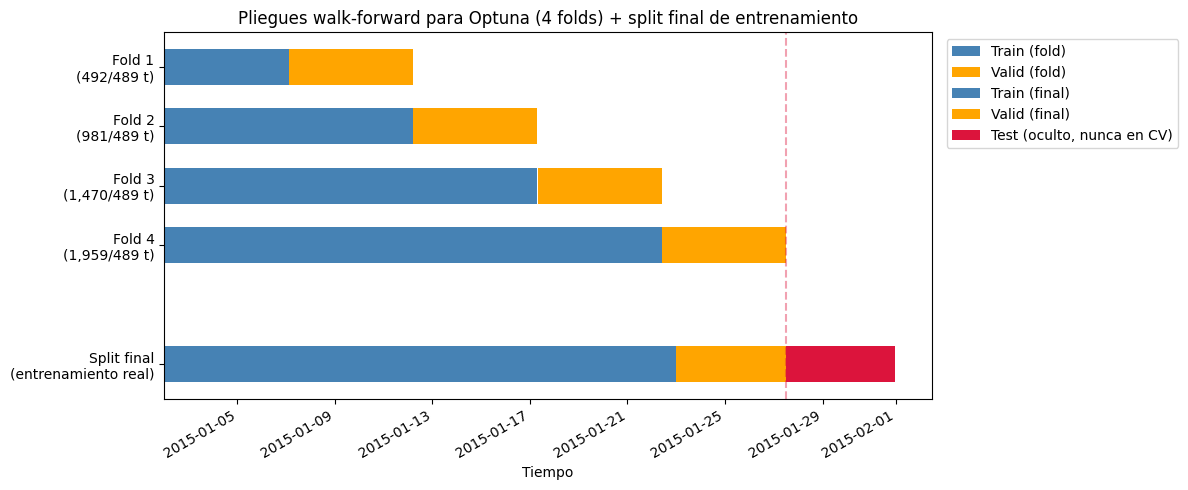

Rangos por fold (verificar que train siempre termina antes de que empiece valid):
  Fold 1: train [2015-01-02 00:00:00 → 2015-01-07 02:45:00]  (492 t)  |  valid [2015-01-07 03:00:00 → 2015-01-12 05:00:00]  (489 t)
  Fold 2: train [2015-01-02 00:00:00 → 2015-01-12 05:00:00]  (981 t)  |  valid [2015-01-12 05:15:00 → 2015-01-17 07:15:00]  (489 t)
  Fold 3: train [2015-01-02 00:00:00 → 2015-01-17 07:15:00]  (1,470 t)  |  valid [2015-01-17 07:30:00 → 2015-01-22 09:30:00]  (489 t)
  Fold 4: train [2015-01-02 00:00:00 → 2015-01-22 09:30:00]  (1,959 t)  |  valid [2015-01-22 09:45:00 → 2015-01-27 11:45:00]  (489 t)


In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# --- Recalcula los mismos cortes que usará la celda de entrenamiento ---
# (Esto NO entrena nada; solo filtra el índice temporal para dibujar los rangos.)
unique_idx = features_df.index.unique().sort_values()
cutoff_train = unique_idx[int(len(unique_idx) * 0.70)]
cutoff_valid = unique_idx[int(len(unique_idx) * 0.85)]

trainval_times = unique_idx[unique_idx < cutoff_valid]

N_CV_SPLITS = 4  # debe coincidir con el N_CV_SPLITS de la celda de entrenamiento
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

fold_ranges = []
for i, (tr_t_idx, va_t_idx) in enumerate(tscv.split(trainval_times)):
    tr_times = trainval_times[tr_t_idx]
    va_times = trainval_times[va_t_idx]
    fold_ranges.append({
        "fold": i + 1,
        "train_start": tr_times.min(), "train_end": tr_times.max(),
        "valid_start": va_times.min(), "valid_end": va_times.max(),
        "n_train": len(tr_times), "n_valid": len(va_times),
    })

def to_num(t):
    return mdates.date2num(t)

fig, ax = plt.subplots(figsize=(12, 5))
bar_height = 0.6
y_positions, y_labels = [], []

# --- Una fila por cada fold walk-forward que usará Optuna ---
n_folds = len(fold_ranges)
for i, r in enumerate(fold_ranges):
    y = n_folds - i + 1  # fold 1 arriba
    ax.barh(y, to_num(r["train_end"]) - to_num(r["train_start"]), left=to_num(r["train_start"]),
            height=bar_height, color="steelblue", label="Train (fold)" if i == 0 else None)
    ax.barh(y, to_num(r["valid_end"]) - to_num(r["valid_start"]), left=to_num(r["valid_start"]),
            height=bar_height, color="orange", label="Valid (fold)" if i == 0 else None)
    y_positions.append(y)
    y_labels.append(f"Fold {r['fold']}\n({r['n_train']:,}/{r['n_valid']:,} t)")

# --- Fila final: el split oficial (train_df / valid_df / test_df) que de verdad se entrena ---
y_final = 0
ax.barh(y_final, to_num(cutoff_train) - to_num(unique_idx.min()), left=to_num(unique_idx.min()),
        height=bar_height, color="steelblue", label="Train (final)")
ax.barh(y_final, to_num(cutoff_valid) - to_num(cutoff_train), left=to_num(cutoff_train),
        height=bar_height, color="orange", label="Valid (final)")
ax.barh(y_final, to_num(unique_idx.max()) - to_num(cutoff_valid), left=to_num(cutoff_valid),
        height=bar_height, color="crimson", label="Test (oculto, nunca en CV)")
y_positions.append(y_final)
y_labels.append("Split final\n(entrenamiento real)")

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.set_xlabel("Tiempo")
ax.set_title(f"Pliegues walk-forward para Optuna ({N_CV_SPLITS} folds) + split final de entrenamiento")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.axvline(to_num(cutoff_valid), color="crimson", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Rangos por fold (verificar que train siempre termina antes de que empiece valid):")
for r in fold_ranges:
    assert r["train_end"] < r["valid_start"], f"¡Traslape en fold {r['fold']}!"
    print(f"  Fold {r['fold']}: train [{r['train_start']} → {r['train_end']}]  "
          f"({r['n_train']:,} t)  |  valid [{r['valid_start']} → {r['valid_end']}]  ({r['n_valid']:,} t)")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import optuna
import os
import json

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

MODEL_PATH = "modelo_lightgbm_taxi_times_split.txt"
PARAMS_PATH = "mejores_hiperparametros_times_split.json"
EVALS_PATH = "evals_result_times_split.json"          # guarda la curva de aprendizaje
META_PATH = "modelo_meta_times_split.json"            # guarda best_iteration

unique_idx = features_df.index.unique()
cutoff_train = unique_idx[int(len(unique_idx) * 0.70)]
cutoff_valid = unique_idx[int(len(unique_idx) * 0.85)]

train_df = features_df[features_df.index < cutoff_train]
valid_df = features_df[(features_df.index >= cutoff_train) & (features_df.index < cutoff_valid)]
test_df  = features_df[features_df.index >= cutoff_valid]

print(f"Train: {train_df.shape[0]:,} filas | Valid: {valid_df.shape[0]:,} filas | Test: {test_df.shape[0]:,} filas")

# ---------------------------------------------------------------------
# Si ya existe un modelo guardado, se carga directamente (sin reentrenar).
# Si no existe, se entrena y se guarda todo (modelo + hiperparámetros +
# curva de aprendizaje + best_iteration) para la próxima ejecución.
# ---------------------------------------------------------------------
if os.path.exists(MODEL_PATH):
    print(f"\nModelo encontrado en '{MODEL_PATH}' -> cargando (sin reentrenar)...")
    gbm_model = lgb.Booster(model_file=MODEL_PATH)

    with open(PARAMS_PATH) as f:
        best_params = json.load(f)
    with open(EVALS_PATH) as f:
        evals_result = json.load(f)
    with open(META_PATH) as f:
        meta = json.load(f)
    best_iteration = meta["best_iteration"]

    print("Hiperparámetros usados:", best_params)

else:
    print(f"\nNo se encontró '{MODEL_PATH}' -> entrenando desde cero...")

    # -------------------------------------------------------------------
    # Optuna busca hiperparámetros con validación cruzada temporal
    # MULTI-FOLD (walk-forward, TimeSeriesSplit) sobre train+valid, en vez
    # de un único split fijo. Un solo split de valid puede caer en una
    # ventana atípica y sesgar la elección de hiperparámetros; promediando
    # el MAE de varios folds walk-forward la selección es más robusta.
    # `test_df` NUNCA se toca en esta etapa (evita leakage en la
    # evaluación final de la Sección 2.7.2).
    # -------------------------------------------------------------------
    trainval_df = features_df[features_df.index < cutoff_valid]
    trainval_times = trainval_df.index.unique().sort_values()

    N_CV_SPLITS = 4  # bajar a 3 si el tiempo de cómputo es un problema
    tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "mae",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
            "verbose": -1,
        }

        fold_maes = []
        for tr_t_idx, va_t_idx in tscv.split(trainval_times):
            tr_times = trainval_times[tr_t_idx]
            va_times = trainval_times[va_t_idx]
            tr_fold = trainval_df[trainval_df.index.isin(tr_times)]
            va_fold = trainval_df[trainval_df.index.isin(va_times)]

            lgb_tr_fold = lgb.Dataset(
                tr_fold[feature_cols], label=tr_fold[target_col],
                categorical_feature=["node_id", "hour", "dow"],
                params={"feature_pre_filter": False},
            )
            lgb_va_fold = lgb.Dataset(
                va_fold[feature_cols], label=va_fold[target_col],
                reference=lgb_tr_fold,
                params={"feature_pre_filter": False},
            )

            model_fold = lgb.train(
                params, lgb_tr_fold, num_boost_round=300,
                valid_sets=[lgb_va_fold],
                callbacks=[lgb.early_stopping(20, verbose=False)],
            )
            pred_fold = model_fold.predict(
                va_fold[feature_cols], num_iteration=model_fold.best_iteration
            )
            fold_maes.append(mean_absolute_error(va_fold[target_col], pred_fold))

        return float(np.mean(fold_maes))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    print(f"\nMejores hiperparámetros (CV walk-forward, {N_CV_SPLITS} folds, solo train+valid):")
    print(study.best_params)
    print(f"MAE promedio en CV: {study.best_value:.4f}")

    best_params = {
        "objective": "regression",
        "metric": "mae",
        "verbose": -1,
        **study.best_params,
    }

    # -------------------------------------------------------------------
    # Modelo final: se entrena UNA sola vez con los hiperparámetros
    # ganadores sobre train_df, con early stopping contra valid_df (el
    # tramo temporal más reciente antes de test_df) -- el mismo esquema
    # walk-forward oficial de la Sección 2.7. Esto fija best_iteration y
    # produce la curva de aprendizaje real que se grafica más adelante.
    # -------------------------------------------------------------------
    lgb_train = lgb.Dataset(
        train_df[feature_cols], label=train_df[target_col],
        categorical_feature=["node_id", "hour", "dow"],
        params={"feature_pre_filter": False},
    )
    lgb_valid = lgb.Dataset(
        valid_df[feature_cols], label=valid_df[target_col],
        reference=lgb_train,
        params={"feature_pre_filter": False},
    )

    evals_result = {}
    gbm_model = lgb.train(
    best_params, lgb_train, num_boost_round=2000,   
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(100, verbose=False),
               lgb.record_evaluation(evals_result)],
    )
    best_iteration = gbm_model.best_iteration

    # --- Guardar modelo, hiperparámetros, curva de aprendizaje y meta ---
    gbm_model.save_model(MODEL_PATH, num_iteration=best_iteration)
    with open(PARAMS_PATH, "w") as f:
        json.dump(best_params, f, indent=2)
    with open(EVALS_PATH, "w") as f:
        json.dump(evals_result, f)
    with open(META_PATH, "w") as f:
        json.dump({"best_iteration": best_iteration}, f)
    print(f"\nModelo guardado en '{MODEL_PATH}'")

Train: 314,340 filas | Valid: 67,548 filas | Test: 67,392 filas

No se encontró 'modelo_lightgbm_taxi_times_split.txt' -> entrenando desde cero...


[I 2026-09-23 15:33:01,784] A new study created in memory with name: no-name-c6f70e0e-e787-4c4f-acd5-52b391df1f79
[I 2026-09-23 15:33:09,490] Trial 0 finished with value: 3.158645089742514 and parameters: {'learning_rate': 0.1392620253407284, 'num_leaves': 63, 'min_data_in_leaf': 23}. Best is trial 0 with value: 3.158645089742514.
[I 2026-09-23 15:33:32,353] Trial 1 finished with value: 3.164026556375437 and parameters: {'learning_rate': 0.03243092899462118, 'num_leaves': 177, 'min_data_in_leaf': 21}. Best is trial 0 with value: 3.158645089742514.
[I 2026-09-23 15:33:43,573] Trial 2 finished with value: 3.151885037203654 and parameters: {'learning_rate': 0.08153294310409642, 'num_leaves': 69, 'min_data_in_leaf': 26}. Best is trial 2 with value: 3.151885037203654.
[I 2026-09-23 15:34:22,365] Trial 3 finished with value: 3.160886460048833 and parameters: {'learning_rate': 0.04305501169688658, 'num_leaves': 203, 'min_data_in_leaf': 79}. Best is trial 2 with value: 3.151885037203654.
[I 20


Mejores hiperparámetros (CV walk-forward, 4 folds, solo train+valid):
{'learning_rate': 0.06403950565529132, 'num_leaves': 61, 'min_data_in_leaf': 64}
MAE promedio en CV: 3.1440

Modelo guardado en 'modelo_lightgbm_taxi_times_split.txt'


### Curva de aprendizaje: ¿el modelo converge sin sobreajustar?

Visualizamos la evolución de la métrica de pérdida (MAE) en *train* y *test* a lo largo de las iteraciones de boosting: el diagnóstico estándar para detectar sobreajuste (la curva de *test* que empieza a subir mientras *train* sigue bajando).



Curva de aprendizaje (última iteración registrada, best_iteration=834)


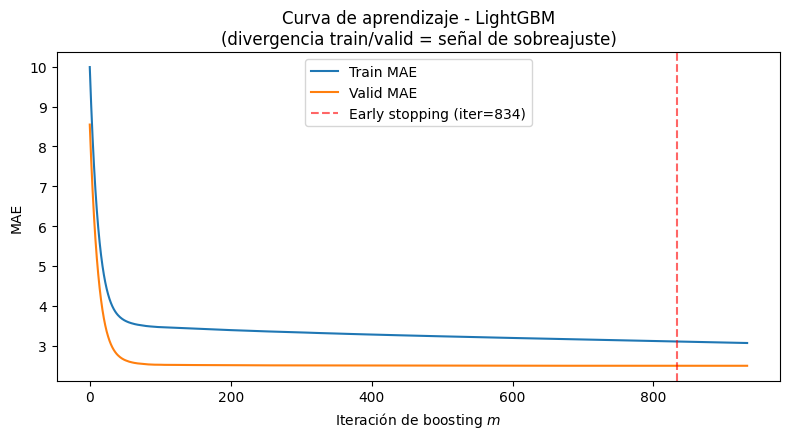


LightGBM (evaluación sobre test)
MAE: 2.663 km/h | RMSE: 4.016 km/h | MAPE: 897411252094429.75%


In [46]:
# ---------------------------------------------------------------------
# Evaluación final sobre test (se ejecuta siempre, cargado o recién
# entrenado)
# ---------------------------------------------------------------------
pred_gbm = gbm_model.predict(test_df[feature_cols])
y_true = test_df[target_col].values

mae_gbm = mean_absolute_error(y_true, pred_gbm)
rmse_gbm = mean_squared_error(y_true, pred_gbm) ** 0.5
mape_gbm = np.mean(np.abs((y_true - pred_gbm) / np.where(y_true == 0, 1e-6, y_true))) * 100

# ---------------------------------------------------------------------
# MAE y RMSE finales de las curvas de aprendizaje (último valor
# registrado en evals_result, útil para comparar train vs valid)
# ---------------------------------------------------------------------
train_mae_final = evals_result["train"]["l1"][-1]
valid_mae_final = evals_result["valid"]["l1"][-1]

print(f"\nCurva de aprendizaje (última iteración registrada, best_iteration={best_iteration})")

# ---------------------------------------------------------------------
# Curva de aprendizaje (funciona igual si el modelo fue entrenado
# recién o cargado desde archivo, porque evals_result y best_iteration
# ahora se persisten junto con el modelo)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.plot(evals_result["train"]["l1"], label="Train MAE")
plt.plot(evals_result["valid"]["l1"], label="Valid MAE")
plt.axvline(best_iteration, color="red", ls="--", alpha=0.6,
            label=f"Early stopping (iter={best_iteration})")
plt.xlabel("Iteración de boosting $m$")
plt.ylabel("MAE")
plt.title("Curva de aprendizaje - LightGBM\n(divergencia train/valid = señal de sobreajuste)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nLightGBM (evaluación sobre test)")
print(f"MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h | MAPE: {mape_gbm:.2f}%")

````{admonition} Lectura
:class: tip

El *early stopping* detiene el entrenamiento en la iteración donde el MAE de *test* deja de mejorar, evitando que el modelo siga reduciendo el error de *train* a costa de generalización; es el mecanismo de regularización práctico más importante en GBM junto con `num_leaves` y `min_data_in_leaf` (que limitan la complejidad de cada árbol individual, Secciones 4.3 y 4.1).
````


In [48]:
print(train_df[target_col].describe()[["mean", "std", "min", "max"]])
print(valid_df[target_col].describe()[["mean", "std", "min", "max"]])

mean    12.941500
std     13.323639
min      0.000000
max     86.429199
Name: y, dtype: float64
mean    10.077666
std     10.344478
min      0.000000
max     59.718520
Name: y, dtype: float64


| | Train | Valid | Diferencia |
|---|---|---|---|
| Media | 12.94 | 10.08 | -22% |
| Std | 13.32 | 10.34 | -22% |
| Max | 86.43 | 59.72 | -31% |

`valid_df` tiene media, desviación estándar y máximo notablemente más bajos que `train_df`: es un periodo con velocidades más bajas y, sobre todo, menos variabilidad (menos picos extremos, valores más "apretados" alrededor de su media). Un modelo entrenado con datos de mayor variabilidad (train) va a mostrar un MAE naturalmente más alto ahí, simplemente porque hay más rango de valores que acertar, mientras que en un tramo más "plano" como valid, hasta una predicción mediocre tiende a acertar más fácil.

In [51]:
def bootstrap_gap_ci_normalized(model, train_df, valid_df, feature_cols, target_col,
                                 best_iteration, n_boot=500, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)

    pred_train = model.predict(train_df[feature_cols], num_iteration=best_iteration)
    pred_valid = model.predict(valid_df[feature_cols], num_iteration=best_iteration)
    err_train = np.abs(train_df[target_col].values - pred_train)
    err_valid = np.abs(valid_df[target_col].values - pred_valid)

    train_std = train_df[target_col].std()
    valid_std = valid_df[target_col].std()

    gaps = []
    for _ in range(n_boot):
        bt = rng.choice(err_train, size=len(err_train), replace=True)
        bv = rng.choice(err_valid, size=len(err_valid), replace=True)
        gaps.append((bt.mean() / train_std) - (bv.mean() / valid_std))

    gaps = np.array(gaps)
    ci_low, ci_high = np.percentile(gaps, [100*alpha/2, 100*(1-alpha/2)])
    return gaps.mean(), ci_low, ci_high

gap_norm, ci_low_n, ci_high_n = bootstrap_gap_ci_normalized(
    gbm_model, train_df, valid_df, feature_cols, target_col, best_iteration
)
print(f"Brecha NORMALIZADA (Train MAE/std - Valid MAE/std): {gap_norm:.4f}")
print(f"IC 95%: [{ci_low_n:.4f}, {ci_high_n:.4f}]")

Brecha NORMALIZADA (Train MAE/std - Valid MAE/std): -0.0080
IC 95%: [-0.0102, -0.0060]


In [ ]:
import numpy as np

def pooled_std(a, b):
    """Desviación estándar combinada de dos muestras (ddof=1)."""
    n1, n2 = len(a), len(b)
    v1, v2 = a.var(ddof=1), b.var(ddof=1)
    return np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))


def cohens_d(a, b):
    """d = (media(a) - media(b)) / sigma_pooled."""
    return (a.mean() - b.mean()) / pooled_std(a, b)


def _resample(x, rng, block_size=None):
    """Remuestreo iid (block_size=None) o por bloques móviles (series temporales)."""
    n = len(x)
    if block_size is None or block_size <= 1:
        return rng.choice(x, size=n, replace=True)
    n_blocks = int(np.ceil(n / block_size))
    starts = rng.integers(0, n - block_size + 1, size=n_blocks)
    idx = (starts[:, None] + np.arange(block_size)[None, :]).ravel()[:n]
    return x[idx]


def bootstrap_cohens_d(model, train_df, valid_df, feature_cols, target_col,
                       best_iteration, n_boot=2000, alpha=0.05, seed=0,
                       block_size=None):
    rng = np.random.default_rng(seed)

    pred_train = model.predict(train_df[feature_cols], num_iteration=best_iteration)
    pred_valid = model.predict(valid_df[feature_cols], num_iteration=best_iteration)
    err_train = np.abs(train_df[target_col].values - pred_train)
    err_valid = np.abs(valid_df[target_col].values - pred_valid)

    d_obs = cohens_d(err_train, err_valid)

    ds = np.empty(n_boot)
    for b in range(n_boot):
        bt = _resample(err_train, rng, block_size)
        bv = _resample(err_valid, rng, block_size)
        ds[b] = cohens_d(bt, bv)

    ci_low, ci_high = np.percentile(ds, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return {
        "d_obs": d_obs,
        "d_boot_mean": ds.mean(),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "sigma_pooled": pooled_std(err_train, err_valid),
        "mae_train": err_train.mean(),
        "mae_valid": err_valid.mean(),
    }


def interpret_d(d):
    m = abs(d)
    if m < 0.2:
        return "trivial"
    if m < 0.5:
        return "pequeño"
    if m < 0.8:
        return "mediano"
    return "grande"


# Bootstrap iid (comparable con su brecha normalizada)
res = bootstrap_cohens_d(
    gbm_model, train_df, valid_df, feature_cols, target_col, best_iteration
)

# Bootstrap por bloques (recomendado si las filas están ordenadas en el tiempo)
res_block = bootstrap_cohens_d(
    gbm_model, train_df, valid_df, feature_cols, target_col, best_iteration,
    block_size=24  # ajuste a la estacionalidad de sus datos (p. ej., 24 para datos horarios)
)

for name, r in [("iid", res), ("bloques", res_block)]:
    print(f"[{name}] MAE train = {r['mae_train']:.4f} | MAE valid = {r['mae_valid']:.4f}")
    print(f"[{name}] sigma_pooled (errores) = {r['sigma_pooled']:.4f}")
    print(f"[{name}] d = {r['d_obs']:.4f} ({interpret_d(r['d_obs'])})")
    print(f"[{name}] IC 95% bootstrap: [{r['ci_low']:.4f}, {r['ci_high']:.4f}]")

[iid] MAE train = 3.1014 | MAE valid = 2.4912
[iid] sigma_pooled (errores) = 3.3896
[iid] d = 0.1800 (trivial)
[iid] IC 95% bootstrap: [0.1728, 0.1867]
[bloques] MAE train = 3.1014 | MAE valid = 2.4912
[bloques] sigma_pooled (errores) = 3.3896
[bloques] d = 0.1800 (trivial)
[bloques] IC 95% bootstrap: [0.1599, 0.1977]


La brecha normalizada entre Train y Valid MAE divide el MAE de cada partición entre la desviación estándar de su propio target antes de restarlos:

$$
\text{gap}_{\text{norm}} = \frac{\text{MAE}_{\text{train}}}{\sigma_{\text{train}}} - \frac{\text{MAE}_{\text{valid}}}{\sigma_{\text{valid}}} = \frac{3.11}{13.32} - \frac{2.50}{10.34} = 0.2335 - 0.2418 \approx -0.008
$$

El modelo se equivoca 0.234 $\sigma$ en Train y 0.242 $\sigma$ en Valid, es decir, un **error relativo 3.6 % mayor en Valid**. La media del bootstrap es **-0.008** (IC 95%: [-0.010, -0.006]). El intervalo excluye el cero, pero esto es esperable con $n$ grande, donde **incluso efectos triviales resultan detectables**. El signo negativo apunta hacia el sobreajuste, pero en MAE crudo ocurre lo contrario (2.50 en Valid frente a 3.11 en Train). El cambio de signo se debe a la **menor dispersión del target en Valid** (10.34 frente a 13.32), lo que evidencia **heterogeneidad de régimen entre particiones**.

Limitaciones de esta métrica: (i) **no es un tamaño de efecto estandarizado**, por lo que no admite los umbrales de Cohen; (ii) el bootstrap iid ignora la autocorrelación temporal y **subestima la anchura del IC**; (iii) $\sigma_{\text{train}}$ y $\sigma_{\text{valid}}$ se tratan como constantes; (iv) si `best_iteration` se eligió por early stopping sobre Valid, **su error es ligeramente optimista**.

Para juzgar la **relevancia práctica** (no solo estadística) se calcula el tamaño de efecto de Cohen's $d$ (Cohen, 1988) sobre los errores absolutos $\text{err} = |y - \hat{y}|$:

$$
d = \frac{\overline{\text{err}}_{\text{train}} - \overline{\text{err}}_{\text{valid}}}{\sigma_{\text{pooled}}},
\qquad
\sigma_{\text{pooled}} = \sqrt{\frac{(n_{\text{train}}-1)\,s_{\text{train}}^2 + (n_{\text{valid}}-1)\,s_{\text{valid}}^2}{n_{\text{train}}+n_{\text{valid}}-2}}
$$

donde $s^2$ es la varianza muestral de los errores absolutos de cada partición. **Un $d$ negativo indica mayor error en Valid (dirección del sobreajuste) y un $d$ positivo indica lo contrario.**

| Magnitud de $\lvert d \rvert$ | Interpretación |
|---|---|
| Menor a 0.2 | Efecto trivial |
| Entre 0.2 y 0.5 | Pequeño |
| Entre 0.5 y 0.8 | Mediano |
| Mayor a 0.8 | Grande |

Para el modelo con `best_iteration=834`, $d = 0.180$ (IC 95% por bloques: [0.160, 0.198]; $\sigma_{\text{pooled}} = 3.390$) corresponde a un efecto **trivial**. El IC iid ([0.173, 0.187]) es más estrecho, lo que evidencia autocorrelación temporal de los errores.

```{admonition} Criterio de decisión
:class: tip
El sobreajuste se sustenta con un $d$ negativo, de magnitud pequeña o mayor y con un IC que excluya el cero. Un $d$ positivo indica que Valid es intrínsecamente más fácil de predecir. El IC se estima por bloques para respetar la dependencia temporal de los errores.
```

**Conclusión:** el tamaño de efecto es **positivo y trivial**, por lo que **no hay evidencia sustantiva de sobreajuste**. El error es mayor en Train (MAE de 3.10 frente a 2.49 en Valid), lo contrario de la memorización de `train_df`, y refleja **heterogeneidad de régimen entre particiones**. Es consistente con la brecha normalizada (-0.008; IC 95%: [-0.010, -0.006]), cuya significancia es esperable con $n$ grande y carece de relevancia práctica: el error relativo es solo 3.6 % mayor en Valid (0.242 $\sigma$ frente a 0.234 $\sigma$). El límite superior del IC (0.198) roza el umbral de 0.2, pero con signo opuesto al del sobreajuste. Si `best_iteration` se eligió por early stopping sobre Valid, su error es ligeramente optimista, y un conjunto de prueba temporalmente posterior permitiría confirmarlo.

### Importancia de variables (ganancia)

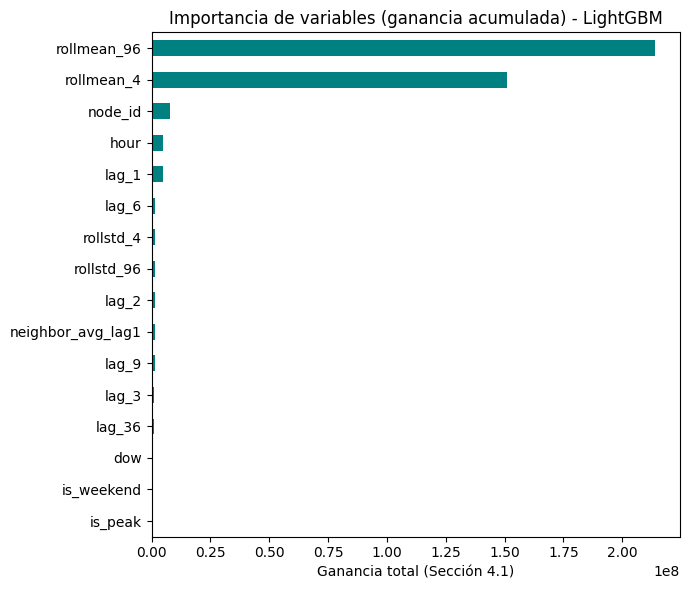

In [37]:
importances = pd.Series(gbm_model.feature_importance(importance_type="gain"), index=feature_cols)
importances.sort_values().plot(kind="barh", figsize=(7, 6), color="teal")
plt.title("Importancia de variables (ganancia acumulada) - LightGBM")
plt.xlabel("Ganancia total (Sección 4.1)")
plt.tight_layout()
plt.show()


````{admonition} Lectura para el aula
:class: tip

Casi siempre `lag_1` y `neighbor_avg_lag1` dominan la importancia: evidencia empírica de que **la señal espacial (vecinos) sí aporta información predictiva incremental**, aunque el modelo no "vea" el grafo explícitamente (solo a través del feature diseñado en la Sección 5.1). Esto motiva por qué vale la pena, en escenarios donde la relación espacial es más compleja, dar el salto a un modelo que aprenda esa estructura de forma automática (STGNN, discutido en la Sección 8).
````


### Interpretabilidad con SHAP (Shapley Additive exPlanations)

La importancia por ganancia (Sección 2.7.3) responde a una pregunta **global**: ¿qué variables usa más el modelo? No indica la **dirección** del efecto (¿un `lag_1` alto sube o baja la predicción?) ni explica **una predicción concreta**. **SHAP** {cite}`lundberg2017unified` resuelve ambas limitaciones.

**Idea central.** Cada predicción se descompone como un punto de partida más las contribuciones de cada variable:

$$
\text{predicción} = \underbrace{\text{promedio del modelo}}_{\mathbb{E}[f(X)]} + \phi_{\texttt{lag}_1} + \phi_{\texttt{hora}} + \phi_{\texttt{temperatura}} + \dots
$$

Cada $\phi_{i,j}$ es el **valor de Shapley** de la variable $j$ en la observación $i$: positivo si empuja la predicción hacia arriba, negativo si la empuja hacia abajo. Este valor proviene de la teoría de juegos cooperativos {cite}`shapley1953value`.

```{admonition} Analogía: repartir el mérito de un trabajo en grupo
:class: tip
Un equipo de tres personas obtiene una nota de 30 puntos, mientras que la nota promedio de un equipo es 20. ¿Cuánto aportó cada integrante a esos 10 puntos adicionales? Como el orden en que cada uno se incorpora cambia su aporte aparente, se calcula el aporte de cada persona en **todos los órdenes posibles** de incorporación y se promedia. Ese promedio es el valor de Shapley. En SHAP, los integrantes son las variables y la nota es la predicción del modelo.
```
#### Ejemplo con tres variables

Supóngase que el modelo predice, para una observación, los valores de la tabla según qué variables se conozcan. Aquí `v(S)` es la predicción esperada al conocer solo ese subconjunto.

| Variables conocidas | Predicción esperada $v(S)$ |
|---|---|
| Ninguna (promedio del modelo) | 20 |
| `lag_1` | 26 |
| `hora` | 23 |
| `temperatura` | 19 |
| `lag_1`, `hora` | 31 |
| `lag_1`, `temperatura` | 25 |
| `hora`, `temperatura` | 22 |
| `lag_1`, `hora`, `temperatura` (predicción final) | 30 |

El aporte de una variable depende del orden en que se incorpora. Por ejemplo, `lag_1` aporta $26 - 20 = +6$ si llega primero, pero $31 - 23 = +8$ si llega después de `hora`. La siguiente tabla calcula el aporte de cada variable en los seis órdenes posibles, restando los valores de $v(S)$ de la tabla anterior:

| Orden de llegada | Aporte de `lag_1` | Aporte de `hora` | Aporte de `temperatura` | Suma |
|---|---|---|---|---|
| `lag_1`, `hora`, `temperatura` | $26-20=+6$ | $31-26=+5$ | $30-31=-1$ | 10 |
| `lag_1`, `temperatura`, `hora` | $26-20=+6$ | $30-25=+5$ | $25-26=-1$ | 10 |
| `hora`, `lag_1`, `temperatura` | $31-23=+8$ | $23-20=+3$ | $30-31=-1$ | 10 |
| `hora`, `temperatura`, `lag_1` | $30-22=+8$ | $23-20=+3$ | $22-23=-1$ | 10 |
| `temperatura`, `lag_1`, `hora` | $25-19=+6$ | $30-25=+5$ | $19-20=-1$ | 10 |
| `temperatura`, `hora`, `lag_1` | $30-22=+8$ | $22-19=+3$ | $19-20=-1$ | 10 |
| **Promedio (valor SHAP)** | **+7** | **+4** | **-1** | **10** |

```{admonition} Cómo completar cada fila
:class: tip
1. Lea el orden de llegada de izquierda a derecha.
2. Para cada variable, identifique qué variables llegaron antes que ella.
3. Busque en la tabla de $v(S)$ la predicción **con** esa variable (las anteriores más ella) y la predicción **sin** ella (solo las anteriores).
4. Reste: con menos sin. Ese es el aporte de la variable en ese orden.
5. Verifique que los tres aportes de la fila sumen 10, la distancia entre el promedio (20) y la predicción final (30).

El valor SHAP de cada variable es el promedio de su columna sobre los seis órdenes: $(6+6+8+8+6+8)/6 = 7$ para `lag_1`, $(5+5+3+3+5+3)/6 = 4$ para `hora` y $-1$ para `temperatura`.
```
En cada fila los tres aportes suman 10, que es la distancia entre el promedio del modelo (20) y la predicción final (30). Por eso los valores SHAP también suman 10: $20 + 7 + 4 - 1 = 30$.

```{admonition} Por qué la cascada muestra 27 y no 26
:class: tip
En la figura de cascada, las barras se acumulan con los **valores SHAP** (promedios sobre todos los órdenes), no con los valores $v(S)$ de un orden particular. Por eso, tras `lag_1`, la figura marca 27 (20 + 7) y no 26 (el valor de $v(\{\texttt{lag}_1\})$). Los valores intermedios dependen del orden en que se dibujan las barras. El valor SHAP de cada variable no depende de ese orden.
```

```{code-cell} ipython3
from itertools import permutations
import matplotlib.pyplot as plt

features = ["lag_1", "hora", "temperatura"]
v = {
    (): 20,
    ("lag_1",): 26, ("hora",): 23, ("temperatura",): 19,
    ("lag_1", "hora"): 31, ("lag_1", "temperatura"): 25, ("hora", "temperatura"): 22,
    ("lag_1", "hora", "temperatura"): 30,
}
v = {frozenset(k): val for k, val in v.items()}

# Promedio de la contribución marginal sobre los 6 órdenes de llegada
phi = {f: 0.0 for f in features}
orders = list(permutations(features))
for order in orders:
    S = frozenset()
    for f in order:
        phi[f] += v[S | {f}] - v[S]
        S = S | {f}
phi = {f: val / len(orders) for f, val in phi.items()}
print(phi)  # {'lag_1': 7.0, 'hora': 4.0, 'temperatura': -1.0}

# Figura: cascada (waterfall) de la descomposición
base, pred = v[frozenset()], v[frozenset(features)]
fig, ax = plt.subplots(figsize=(7, 3.5))
left = base
for f in features:
    val = phi[f]
    ax.barh(f, val, left=left, color="tab:red" if val > 0 else "tab:blue")
    ax.text(max(left, left + val) + 0.2, f, f"{val:+.1f}", va="center")
    left += val
ax.axvline(base, ls="--", color="gray")
ax.axvline(pred, ls="--", color="black")
ax.set_xlim(base - 2, pred + 3)
ax.invert_yaxis()
ax.set_xlabel("Predicción")
ax.set_title(f"Promedio del modelo = {base}  |  Predicción = {pred}")
plt.tight_layout()
plt.show()
```

El resultado es $\phi_{\texttt{lag}_1} = +7$, $\phi_{\texttt{hora}} = +4$ y $\phi_{\texttt{temperatura}} = -1$. Al sumarlos, $20 + 7 + 4 - 1 = 30$: **las contribuciones reconstruyen exactamente la predicción**. Esta propiedad se llama eficiencia y es la que hace que SHAP sea una descomposición y no solo un ranking.

#### SHAP sobre el modelo LightGBM

Para modelos de árboles, `TreeSHAP` {cite}`lundberg2020local` calcula los valores de forma **exacta** y rápida, aprovechando la estructura de los árboles.

```{code-cell} ipython3
import numpy as np
import shap

explainer = shap.TreeExplainer(gbm_model)
X_sample = valid_df[feature_cols].sample(2000, random_state=0)
shap_values = explainer(X_sample)

# Verificación de eficiencia: la suma de contribuciones reconstruye la predicción
pred_model = gbm_model.predict(X_sample, num_iteration=best_iteration)
recon = shap_values.values.sum(axis=1) + shap_values.base_values
print("Error máximo de reconstrucción:", np.abs(recon - pred_model).max())

# Figura 1: explicación local (una observación)
shap.plots.waterfall(shap_values[0], max_display=10)

# Figura 2: explicación global con dirección del efecto
shap.plots.beeswarm(shap_values, max_display=10)

# Figura 3: importancia global (promedio del valor absoluto)
shap.plots.bar(shap_values, max_display=10)
```

```{admonition} Cómo leer el gráfico de enjambre (beeswarm)
:class: tip
Cada punto es una observación. El eje horizontal es el valor SHAP: a la derecha, la variable aumenta la predicción; a la izquierda, la disminuye. El color indica el valor de la variable (rojo alto, azul bajo). Las variables se ordenan de mayor a menor impacto global.

- **Rojos a la derecha y azules a la izquierda:** un valor alto de la variable aumenta la predicción (efecto positivo y monótono). Si los colores se invierten, el efecto es negativo.
- **Rojos y azules a ambos lados:** el efecto no es simple. Puede ser **no monótono** (por ejemplo, `hora`, donde valores bajos y altos pueden comportarse igual) o depender de **otras variables** (interacción). Un valor SHAP negativo solo indica que la predicción queda por debajo del promedio del modelo.
- **Puntos cerca de 0:** la variable influye poco.

Para distinguir entre las dos causas se usa `shap.plots.scatter`: una curva clara indica una relación no monótona, y una dispersión vertical separada por el color de otra variable indica una interacción.
```

Tres preguntas guían la lectura de las figuras:

1. **Local:** ¿qué variables explican esta predicción concreta? (cascada)
2. **Global:** ¿qué variables pesan más en promedio? (barras)
3. **Dirección:** ¿valores altos de una variable suben o bajan la predicción? (enjambre)

```{admonition} Formalización (para quien desee el detalle matemático)
:class: tip dropdown
El valor de Shapley de la variable $j$ en la observación $i$ es

$$
\phi_{i,j} = \sum_{S \subseteq \{1,\dots,F\}\setminus\{j\}} \frac{|S|!\,(F-|S|-1)!}{F!}\Big[v_i(S\cup\{j\}) - v_i(S)\Big]
$$

donde $v_i(S)$ es el valor esperado de la predicción condicionado a conocer solo las variables del subconjunto $S$. La fórmula equivale a promediar la contribución marginal de $j$ sobre todos los órdenes de llegada, como en el ejemplo de tres variables. Es la única asignación que cumple los axiomas de **eficiencia, simetría, dummy y aditividad** ({cite}`shapley1953value`; {cite}`lundberg2017unified`, Theorem 1), y de la eficiencia se obtiene $\sum_j \phi_{i,j} = f(x_i) - \mathbb{E}[f(X)]$.
```

```{admonition} Precaución al interpretar
:class: tip
SHAP describe **cómo el modelo usa las variables**, no relaciones causales del fenómeno. Además, con variables muy correlacionadas (por ejemplo, `lag_1` y `lag_2`) el mérito se reparte entre ellas, por lo que ninguna debe leerse de forma aislada.
```

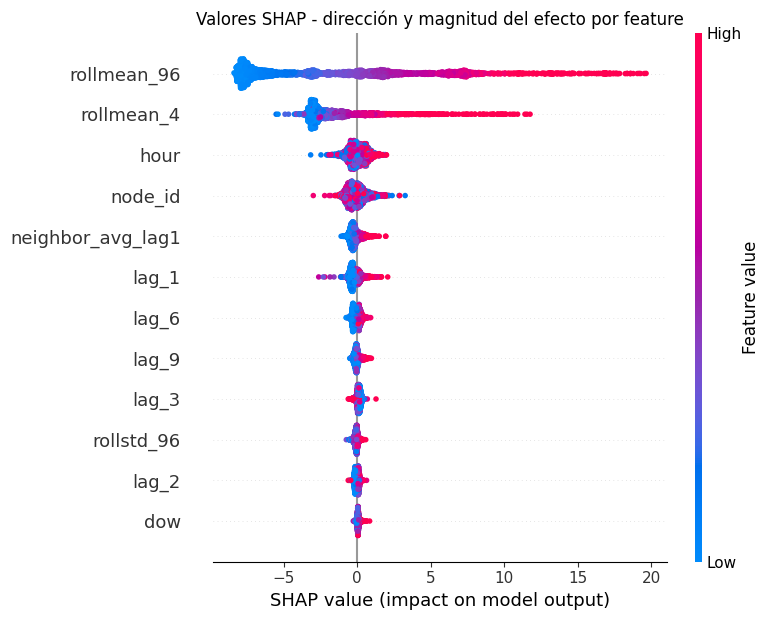

In [38]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap -q
    import shap

# TreeExplainer calcula los valores de Shapley de forma exacta para modelos de árboles
explainer = shap.TreeExplainer(gbm_model)
sample_test = test_df[feature_cols].sample(n=min(3000, len(test_df)), random_state=0)
shap_values = explainer.shap_values(sample_test)

# Summary plot: dirección y magnitud del efecto de cada feature
shap.summary_plot(shap_values, sample_test, show=False, max_display=12)
plt.title("Valores SHAP - dirección y magnitud del efecto por feature")
plt.tight_layout()
plt.show()


**Lectura de las cuatro variables más importantes.** Las variables se ordenan por su impacto global (promedio del valor absoluto de SHAP) y el eje horizontal está en las unidades del target. Las dos primeras dominan claramente: sus valores SHAP abarcan un rango mucho mayor que el de las demás.

| Variable | Rango SHAP aproximado | Patrón de color | Interpretación |
|---|---|---|---|
| `rollmean_96` | -8 a +20 | Azul a la izquierda, rojo a la derecha | Efecto **positivo y monótono**, con cola larga a la derecha |
| `rollmean_4` | -5 a +12 | Azul a la izquierda, rojo a la derecha | Efecto **positivo y monótono**, de menor magnitud |
| `hour` | -3 a +2 | Rojos y azules mezclados | Efecto **no monótono** (variable cíclica) |
| `node_id` | -3 a +3 | Colores mezclados sin patrón | Nivel base propio de cada nodo (identificador, no una magnitud) |

1. **`rollmean_96` (mayor impacto).** Un promedio móvil bajo (azul) reduce la predicción hasta unas 8 unidades por debajo del promedio del modelo, y uno alto (rojo) la aumenta hasta cerca de 20 unidades. La variable resume el **nivel reciente de la serie** y el modelo se ancla en él. La distribución es asimétrica: los puntos azules forman una masa densa a la izquierda y los rojos una cola larga a la derecha. Esto indica que la mayoría de las observaciones corresponde a niveles bajos o moderados, con un efecto pequeño y homogéneo, mientras que unos pocos periodos de nivel alto producen contribuciones muy grandes. La forma es coherente con un target de cola derecha.

2. **`rollmean_4` (segundo impacto).** Tiene la misma dirección que `rollmean_96`, con un rango menor. Como su ventana es corta, captura el **nivel inmediato** de la serie. Ambos promedios se complementan: `rollmean_96` fija el nivel base y `rollmean_4` ajusta la predicción según la evolución más reciente. Por estar muy correlacionadas, el mérito se reparte entre ellas y ninguna debe leerse de forma aislada.

3. **`hour` (impacto moderado).** Los colores se mezclan a ambos lados de 0, por lo que el efecto **no es monótono**: una hora numéricamente mayor no implica una predicción mayor. Es esperable en una variable cíclica, donde la escala rojo-azul pierde sentido. Su efecto es de unos pocos puntos, mucho menor que el de los promedios móviles. Para ver el perfil diario conviene el gráfico de dependencia (`shap.plots.scatter`).

4. **`node_id` (impacto moderado).** Es un identificador, de modo que el orden numérico y el color (alto o bajo) **no tienen significado**. La dispersión de sus valores SHAP indica que cada nodo tiene un nivel base propio que el modelo corrige respecto al promedio general, es decir, **heterogeneidad entre nodos**. Si se ingresa como número entero, LightGBM lo trata como una variable ordenada y las particiones del árbol agrupan identificadores por su posición numérica, sin sustento en el fenómeno.

```{admonition} Lectura conjunta
:class: tip
El modelo se apoya sobre todo en el **nivel reciente de la serie** (los dos promedios móviles). El calendario (`hour`) y la identidad del nodo (`node_id`) aportan correcciones secundarias. Los rezagos y `neighbor_avg_lag1` tienen efectos menores (por debajo de 2 unidades), lo que es compatible con una señal espacial modesta, aunque solo una ablación (con y sin variables espaciales) permite afirmarlo. SHAP describe cómo el modelo usa las variables, no relaciones causales del fenómeno.
```

### Análisis de residuos

Verificamos si el modelo deja **estructura no explicada** en los residuos $e_{i,t} = y_{i,t} - \hat{y}_{i,t}$. Si capturó toda la señal, estos deberían comportarse como **ruido blanco**: sin autocorrelación, sin varianza cambiante y sin dependencia no lineal. Como los datos forman un panel nodo × tiempo, las pruebas se aplican **por nodo** y no sobre el vector apilado, que mezclaría series distintas. El análisis se organiza en cuatro etapas:

1. **Diagnóstico por nodo.** ACF en los lags de las features (magnitud y fracción de nodos fuera de la banda $\pm 1.96/\sqrt{n}$), Ljung-Box (autocorrelación lineal) y McLeod-Li (heterocedasticidad condicional, es decir, Ljung-Box sobre $e_t^2$), ambos en los lags 9, 36 y 96 con corrección de Bonferroni. También el Runs test (rachas del mismo signo) y BDS (dependencia no lineal) en nodos representativos.
2. **Diagnóstico fino.** Caracteriza qué nodos rechazan la independencia, comparando error, volatilidad y MAE normalizado con Spearman y Mann-Whitney, para separar el efecto de escala del de estructura residual.
3. **Comparaciones múltiples.** Con 156 nodos, los rechazos individuales no son concluyentes. Se contrastan Bonferroni (FWER), Benjamini-Hochberg (FDR) y Benjamini-Yekutieli (FDR bajo dependencia arbitraria), y se evalúa la evidencia global con Bonferroni y la combinación de Cauchy, válidas cuando los nodos vecinos no son independientes.
4. **Regresión por cuantiles.** Si la varianza del error cambia, se modela explícitamente con $q = 0.1, 0.5, 0.9$ (pinball loss), y se evalúa la cobertura del intervalo del 80 % (global, por cola y por hora) y su **interval score** frente a un intervalo de ancho constante.

```{admonition} Cómo leer esta sección
:class: tip
Un rechazo indica **estructura remanente**, no necesariamente mal desempeño, y con $n$ grande la significancia debe contrastarse con la magnitud del efecto. No rechazar $H_0$ no prueba que el modelo sea adecuado.
```

¿test_df está ordenado por nodo y luego por tiempo?
                     node_id
2015-01-27 12:00:00        0
2015-01-27 12:15:00        0
2015-01-27 12:30:00        0
                     node_id
2015-01-31 23:15:00      155
2015-01-31 23:30:00      155
2015-01-31 23:45:00      155
Nº de nodos únicos en test: 156
Filas totales: 67,392 | Filas por nodo (aprox): 432

Se reconstruyeron 156 series de residuos; 156 tienen más de 192 observaciones y se analizan (0 omitidas).

[ACF] Autocorrelación residual por lag, promediada entre nodos
  lag |  ACF medio | |ACF| medio | máx |ACF| | % nodos fuera de banda
    1 |    -0.0015 |      0.0488 |    0.6162 |                 11.5%
    2 |    +0.0077 |      0.0521 |    0.6028 |                 12.8%
    3 |    +0.0054 |      0.0506 |    0.5589 |                 12.2%
    4 |    -0.0140 |      0.0482 |    0.5154 |                 10.9%
    6 |    -0.0161 |      0.0518 |    0.4585 |                 12.2%
    9 |    +0.0006 |      0.0427 |    0.3980 |

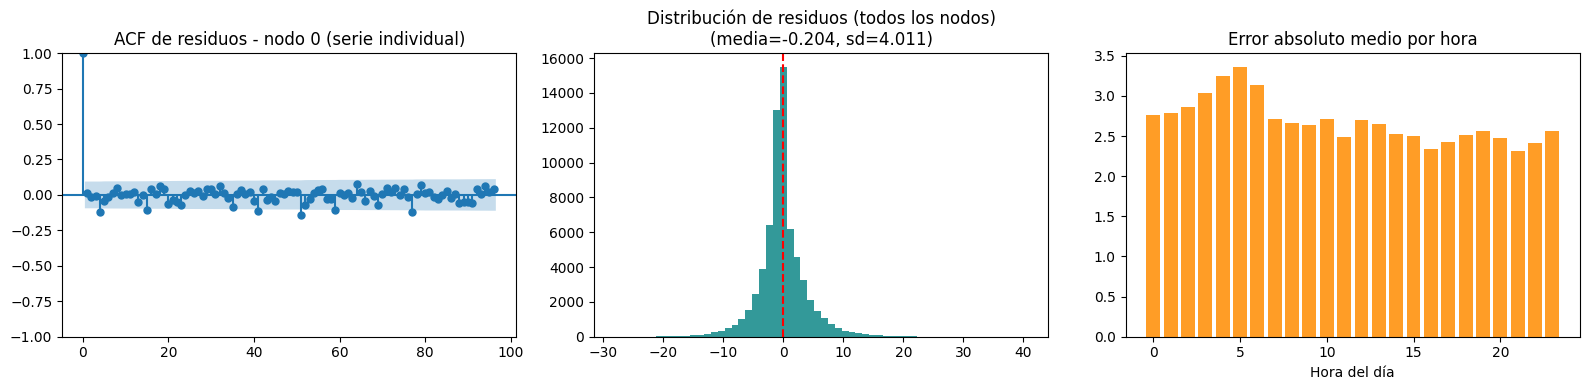


RESUMEN DE DIAGNÓSTICO (por nodo, no sobre el panel apilado)
Ljung-Box   -> % de nodos con autocorrelación lineal detectada: 25.0%
McLeod-Li   -> % de nodos con dependencia no lineal detectada:  37.8%
Runs test   -> % de nodos con secuencia no aleatoria:           32.1%
ACF promedio en los lags de las features: lag 1: -0.0015 | lag 2: +0.0077 | lag 3: +0.0054 | lag 4: -0.0140 | lag 6: -0.0161 | lag 9: +0.0006 | lag 36: -0.0050 | lag 96: +0.0318


In [54]:
### Análisis de residuos (diagnóstico por nodo, alineado con las features del modelo)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import bds, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm

# ------------------------------------------------------------
# Configuración: mismos lags y ventanas que build_features
# ------------------------------------------------------------
LAGS_FEATURES = (1, 2, 3, 6, 9, 36)
ROLL_WINDOWS = (4, 96)

lags_interes = sorted(set(LAGS_FEATURES) | set(ROLL_WINDOWS))  # [1, 2, 3, 4, 6, 9, 36, 96]
lag_idx = {lag: i for i, lag in enumerate(lags_interes)}
max_lag = max(lags_interes)

# Lags para Ljung-Box y McLeod-Li: rezago corto máximo, 36 y ciclo diario
lb_lags = [9, 36, 96]
min_len = 2 * max_lag  # longitud mínima por nodo para que ACF y pruebas sean estables
alpha = 0.05

# ------------------------------------------------------------
# Residuos y estructura del panel
# ------------------------------------------------------------
residuals_full = y_true - pred_gbm
res_df = test_df.copy()
res_df["residual"] = residuals_full if not hasattr(residuals_full, "values") else residuals_full.values

print("¿test_df está ordenado por nodo y luego por tiempo?")
print(res_df[["node_id"]].head(3))
print(res_df[["node_id"]].tail(3))
print(f"Nº de nodos únicos en test: {res_df['node_id'].nunique()}")
print(f"Filas totales: {len(res_df):,} | Filas por nodo (aprox): {len(res_df)/res_df['node_id'].nunique():.0f}")

# Serie temporal de residuos de cada nodo, ordenada por el índice temporal real
series_by_node = {}
for node_id, g in res_df.groupby("node_id"):
    assert g.index.is_unique, f"Índice temporal duplicado en el nodo {node_id}"
    series_by_node[node_id] = g.sort_index()["residual"].values

# Se omiten los nodos con series demasiado cortas para el mayor lag
series_valid = {k: s for k, s in series_by_node.items() if len(s) > min_len}
n_nodes = len(series_valid)
print(f"\nSe reconstruyeron {len(series_by_node)} series de residuos; "
      f"{n_nodes} tienen más de {min_len} observaciones y se analizan "
      f"({len(series_by_node) - n_nodes} omitidas).")

# ------------------------------------------------------------
# 1) ACF por nodo: magnitud y fracción de nodos fuera de la banda 1.96/sqrt(n)
# ------------------------------------------------------------
acf_matrix, acf_bounds = [], []
for node_id, serie in series_valid.items():
    vals = acf(serie, nlags=max_lag, fft=True)
    acf_matrix.append([vals[l] for l in lags_interes])
    acf_bounds.append(1.96 / np.sqrt(len(serie)))
acf_matrix = np.array(acf_matrix)
acf_bounds = np.array(acf_bounds)

print("\n[ACF] Autocorrelación residual por lag, promediada entre nodos")
print(f"{'lag':>5} | {'ACF medio':>10} | {'|ACF| medio':>11} | {'máx |ACF|':>9} | {'% nodos fuera de banda':>22}")
for lag in lags_interes:
    col = acf_matrix[:, lag_idx[lag]]
    frac_out = (np.abs(col) > acf_bounds).mean()
    print(f"{lag:>5} | {col.mean():>+10.4f} | {np.abs(col).mean():>11.4f} | "
          f"{np.abs(col).max():>9.4f} | {frac_out:>21.1%}")

# ------------------------------------------------------------
# Función auxiliar: mínimo p-valor entre lags con corrección de Bonferroni
# ------------------------------------------------------------
def min_p_bonferroni(x, lags):
    lb = acorr_ljungbox(x, lags=lags, return_df=True)
    return min(1.0, lb["lb_pvalue"].min() * len(lags))

# ------------------------------------------------------------
# 2) Ljung-Box por nodo
# ------------------------------------------------------------
lb_pvalues = np.array([min_p_bonferroni(s, lb_lags) for s in series_valid.values()])
frac_reject_lb = (lb_pvalues < alpha).mean()
print(f"\n[1] Ljung-Box por nodo, lags {lb_lags} (H0: sin autocorrelación lineal)")
print(f"    Fracción de nodos que rechazan H0 (Bonferroni): {frac_reject_lb:.1%} de {len(lb_pvalues)} nodos")
print(f"    (bajo H0 verdadera en todos los nodos, se esperaría ~{alpha:.0%} por azar)")

# ------------------------------------------------------------
# 3) McLeod-Li por nodo (residuos al cuadrado)
# ------------------------------------------------------------
ml_pvalues = np.array([min_p_bonferroni(s ** 2, lb_lags) for s in series_valid.values()])
frac_reject_ml = (ml_pvalues < alpha).mean()
print(f"\n[2] McLeod-Li por nodo, lags {lb_lags} (H0: sin dependencia no lineal / ARCH)")
print(f"    Fracción de nodos que rechazan H0 (Bonferroni): {frac_reject_ml:.1%} de {len(ml_pvalues)} nodos")

# ------------------------------------------------------------
# 4) Runs test por nodo
# ------------------------------------------------------------
def runs_test(x):
    median = np.median(x)
    signs = (x >= median).astype(int)
    n1, n2 = np.sum(signs == 1), np.sum(signs == 0)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, np.nan
    runs = 1 + np.sum(signs[1:] != signs[:-1])
    mu = (2 * n1 * n2) / (n1 + n2) + 1
    sigma2 = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2) ** 2) * (n1 + n2 - 1))
    z = (runs - mu) / np.sqrt(sigma2)
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return runs, z, p_value

runs_pvalues = np.array([runs_test(s)[2] for s in series_valid.values()])
runs_pvalues = runs_pvalues[~np.isnan(runs_pvalues)]
frac_reject_runs = (runs_pvalues < alpha).mean()
print(f"\n[3] Runs test por nodo (H0: secuencia independiente)")
print(f"    Fracción de nodos que rechazan H0: {frac_reject_runs:.1%} de {len(runs_pvalues)} nodos")

# ------------------------------------------------------------
# 5) BDS sobre nodos individuales (diseñado para una sola serie; costoso)
# ------------------------------------------------------------
nodos_bds = list(series_valid.keys())[:3]  # ampliar si se desea más cobertura
print(f"\n[4] BDS sobre nodos individuales representativos: {nodos_bds}")
for node_id in nodos_bds:
    serie = series_valid[node_id]
    bds_stat, bds_pvalue = bds(serie, max_dim=3)
    reject = any(p < alpha for p in np.atleast_1d(bds_pvalue))
    print(f"    Nodo {node_id} (n={len(serie)}): "
          f"p-valores = {[f'{p:.3f}' for p in np.atleast_1d(bds_pvalue)]} "
          f"{'-> rechaza H0' if reject else '-> no rechaza H0'}")

# ------------------------------------------------------------
# Panel gráfico
# ------------------------------------------------------------
nodo_ejemplo = nodos_bds[0]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_acf(series_valid[nodo_ejemplo], lags=max_lag, ax=axes[0], alpha=0.05)
axes[0].set_title(f"ACF de residuos - nodo {nodo_ejemplo} (serie individual)")

axes[1].hist(residuals_full, bins=60, color="teal", alpha=0.8)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title(f"Distribución de residuos (todos los nodos)\n"
                  f"(media={np.mean(residuals_full):.3f}, sd={np.std(residuals_full):.3f})")

mae_by_hour = res_df.groupby("hour")["residual"].apply(lambda r: r.abs().mean())
axes[2].bar(mae_by_hour.index, mae_by_hour.values, color="darkorange", alpha=0.85)
axes[2].set_xlabel("Hora del día")
axes[2].set_title("Error absoluto medio por hora")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("RESUMEN DE DIAGNÓSTICO (por nodo, no sobre el panel apilado)")
print("=" * 72)
print(f"Ljung-Box   -> % de nodos con autocorrelación lineal detectada: {frac_reject_lb:.1%}")
print(f"McLeod-Li   -> % de nodos con dependencia no lineal detectada:  {frac_reject_ml:.1%}")
print(f"Runs test   -> % de nodos con secuencia no aleatoria:           {frac_reject_runs:.1%}")
print("ACF promedio en los lags de las features: "
      + " | ".join(f"lag {l}: {acf_matrix[:, lag_idx[l]].mean():+.4f}" for l in lags_interes))

Nodos que rechazan al menos una prueba (Bonferroni, alpha/3 = 0.0167): 107 / 156 (68.6%)
Rechazos individuales: Ljung-Box 25.0% | McLeod-Li 37.8% | Runs 32.1%

Comparación de promedios entre grupos:
                   mae_node   nmae  std_speed  mean_speed  acf_lag1
any_reject                                                         
Nodos OK              3.139  0.739      4.206       8.468    -0.007
Nodos con rechazo     2.445  0.678      3.512      10.396     0.001

Asociación con el rechazo (Spearman) y Mann-Whitney entre grupos:
  mae_node    rho = -0.231 | p (Mann-Whitney) = 0.0040
  nmae        rho = -0.391 | p (Mann-Whitney) = 0.0000
  std_speed   rho = -0.178 | p (Mann-Whitney) = 0.0271
  mean_speed  rho = +0.027 | p (Mann-Whitney) = 0.7398
  acf_lag1    rho = +0.027 | p (Mann-Whitney) = 0.7369

Top 10 nodos con mayor MAE:
 node_id  mae_node  nmae    lb    ml  runs  std_speed
     115     7.390 0.799 False False False      9.247
     153     7.218 0.793 False False  True      9.

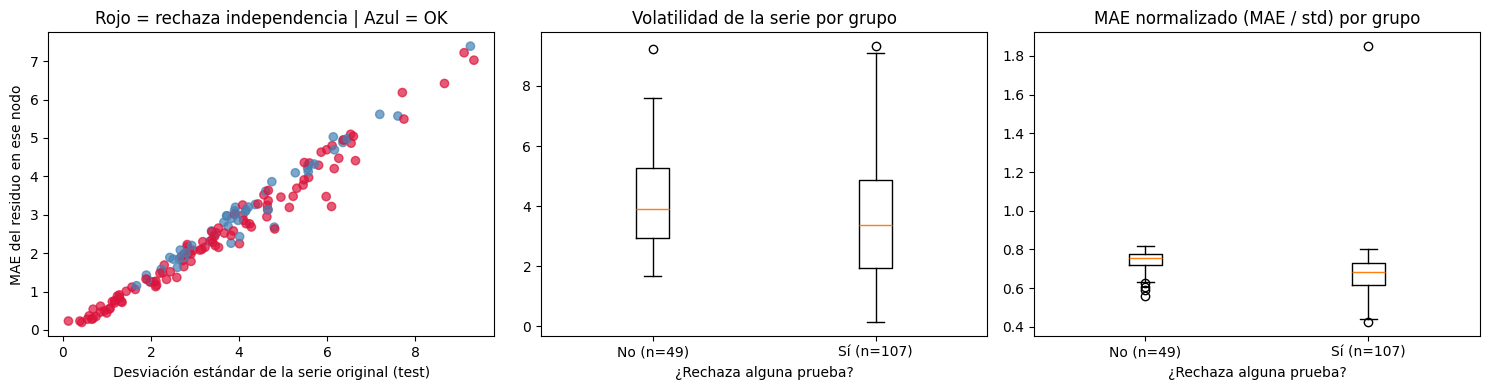

In [55]:
### Diagnóstico fino: ¿qué caracteriza a los nodos que rechazan independencia?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.tsa.stattools import acf

# Estadísticos de la serie original en el MISMO periodo (test) y con la misma
# alineación que los residuos, sin depender de la posición de columnas en speed_df
res_df["y_true"] = np.asarray(y_true)
node_stats = res_df.groupby("node_id")["y_true"].agg(mean_speed="mean", std_speed="std")

alpha_union = alpha / 3  # tres pruebas: la unión se corrige por Bonferroni

rows = []
for node_id, serie in series_valid.items():
    p_lb = min_p_bonferroni(serie, lb_lags)
    p_ml = min_p_bonferroni(serie ** 2, lb_lags)
    p_runs = runs_test(serie)[2]
    p_runs = 1.0 if np.isnan(p_runs) else p_runs

    rows.append({
        "node_id": node_id,
        "p_lb": p_lb, "p_ml": p_ml, "p_runs": p_runs,
        "acf_lag1": acf(serie, nlags=1, fft=True)[1],
        "mae_node": np.mean(np.abs(serie)),
        "rmse_node": np.sqrt(np.mean(serie ** 2)),
        "mean_speed": node_stats.loc[node_id, "mean_speed"],
        "std_speed": node_stats.loc[node_id, "std_speed"],
    })

diag_df = pd.DataFrame(rows)
diag_df["nmae"] = diag_df["mae_node"] / diag_df["std_speed"]  # error relativo a la volatilidad
diag_df["any_reject"] = diag_df[["p_lb", "p_ml", "p_runs"]].min(axis=1) < alpha_union

n_rej, n_tot = int(diag_df["any_reject"].sum()), len(diag_df)
print(f"Nodos que rechazan al menos una prueba (Bonferroni, alpha/3 = {alpha_union:.4f}): "
      f"{n_rej} / {n_tot} ({n_rej / n_tot:.1%})")
print(f"Rechazos individuales: Ljung-Box {(diag_df.p_lb < alpha).mean():.1%} | "
      f"McLeod-Li {(diag_df.p_ml < alpha).mean():.1%} | Runs {(diag_df.p_runs < alpha).mean():.1%}")

cols = ["mae_node", "nmae", "std_speed", "mean_speed", "acf_lag1"]
labels = {False: "Nodos OK", True: "Nodos con rechazo"}

comp = diag_df.groupby("any_reject")[cols].mean().rename(index=labels)
print("\nComparación de promedios entre grupos:")
print(comp.round(3).to_string())

# Asociación con el rechazo (Spearman, robusta a asimetría) y prueba de Mann-Whitney
if 0 < n_rej < n_tot:
    flag = diag_df["any_reject"].astype(int)
    print("\nAsociación con el rechazo (Spearman) y Mann-Whitney entre grupos:")
    for c in cols:
        rho, p_rho = spearmanr(diag_df[c], flag, nan_policy="omit")
        _, p_mw = mannwhitneyu(diag_df.loc[diag_df.any_reject, c].dropna(),
                               diag_df.loc[~diag_df.any_reject, c].dropna())
        print(f"  {c:<11} rho = {rho:+.3f} | p (Mann-Whitney) = {p_mw:.4f}")
else:
    print("\nTodos o ningún nodo rechaza: no se puede comparar entre grupos.")

peores = diag_df.sort_values("mae_node", ascending=False).head(10)
peores = peores.assign(lb=peores.p_lb < alpha, ml=peores.p_ml < alpha, runs=peores.p_runs < alpha)
print("\nTop 10 nodos con mayor MAE:")
print(peores[["node_id", "mae_node", "nmae", "lb", "ml", "runs", "std_speed"]]
      .round(3).to_string(index=False))

# Visualización
def box_by_group(ax, col, title):
    data, labs = [], []
    for flag_val, name in [(False, "No"), (True, "Sí")]:
        v = diag_df.loc[diag_df["any_reject"] == flag_val, col].dropna()
        if len(v):
            data.append(v.values)
            labs.append(f"{name} (n={len(v)})")
    ax.boxplot(data)
    ax.set_xticklabels(labs)
    ax.set_xlabel("¿Rechaza alguna prueba?")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(diag_df["std_speed"], diag_df["mae_node"],
                c=diag_df["any_reject"].map({True: "crimson", False: "steelblue"}), alpha=0.7)
axes[0].set_xlabel("Desviación estándar de la serie original (test)")
axes[0].set_ylabel("MAE del residuo en ese nodo")
axes[0].set_title("Rojo = rechaza independencia | Azul = OK")

box_by_group(axes[1], "std_speed", "Volatilidad de la serie por grupo")
box_by_group(axes[2], "nmae", "MAE normalizado (MAE / std) por grupo")

plt.tight_layout()
plt.show()

**Interpretación del diagnóstico fino por nodo.**

1. **Tasa de rechazo.** El 68.6 % de los nodos (107 de 156) rechaza al menos una prueba con Bonferroni ($\alpha/3 = 0.0167$), frente al ~5 % esperado bajo independencia. Por prueba (nivel 5 %, con Bonferroni sobre los lags 9, 36 y 96), rechazan McLeod-Li 37.8 %, Runs 32.1 % y Ljung-Box 25.0 %; estas tasas no son comparables con la de la unión. La dependencia se concentra en la **varianza** y no en la media, en coherencia con la regresión por cuantiles.

2. **Sin autocorrelación de corto plazo.** El ACF promedio en el lag 1 es nulo en ambos grupos (-0.007 y 0.001; $p = 0.74$). El rechazo proviene de otros lags (36 o 96), de la varianza o de rachas del mismo signo. Conviene verificarlo con $\lvert\text{ACF}\rvert$, pues el promedio con signo oculta cancelaciones.

3. **Rechazan los nodos de menor error, no los más volátiles.** Frente a los nodos que no rechazan, tienen menor MAE (2.445 frente a 3.139), menor MAE normalizado (0.678 frente a 0.739) y menor desviación estándar (3.512 frente a 4.206). La asociación más fuerte es con el MAE normalizado ($\rho = -0.391$, $p < 0.0001$), seguida del MAE ($\rho = -0.231$, $p = 0.004$). La de la desviación estándar ($\rho = -0.178$, $p = 0.027$) no supera Bonferroni sobre cinco comparaciones (umbral 0.01). Los puntos rojos se concentran donde la desviación estándar es menor a 2.

4. **Explicaciones (hipótesis a verificar).**
   - **Rechazar indica estructura remanente, no mal desempeño.** Los nodos que no rechazan tienen un MAE normalizado casi constante (0.72 a 0.78), compatible con ruido poco predecible: con residuos normales, $\text{MAE} \approx 0.8\,\sigma_{\text{res}}$, lo que equivale a un $R^2$ intranodo de ~14 % (0.739) frente a ~28 % (0.678). Pasar las pruebas es condición necesaria, no suficiente, de un buen modelo.
   - **Nodos de baja variabilidad.** Series casi constantes, discretizadas o con fallas de sensor generan empates y colas pesadas que distorsionan McLeod-Li y Runs. El nodo atípico (MAE normalizado ≈ 1.85, desviación estándar ≈ 0.1) sugiere un cambio de nivel entre entrenamiento y prueba.

5. **Los nodos de mayor MAE no son especiales.** Los diez peores tienen desviaciones estándar de 6.5 a 9.3 y un MAE normalizado estrecho (0.71 a 0.80); siete de diez rechazan alguna prueba, proporción similar a la global. El error alto refleja escala, no una falla de especificación.

```{admonition} Lectura
:class: tip
Los residuos **no son ruido blanco en la mayoría de los nodos**, pero la estructura remanente **no es de corto plazo y se asocia con la varianza**. Se concentra en los **nodos de menor error relativo**, donde el modelo captura más señal, y no en los volátiles ni en los de mayor error. Los nodos que pasan las pruebas se comportan como **ruido poco predecible**. Con $n$ grande, la significancia debe contrastarse con la magnitud del efecto, y los p-valores entre nodos son orientativos porque los nodos vecinos comparten dinámica. **Mejoras razonables:** modelar la varianza (cuantiles), añadir rezagos estacionales o volatilidad reciente (`rollstd_4`) e inspeccionar aparte los nodos de muy baja variabilidad.
```

In [57]:
### Corrección por comparaciones múltiples entre nodos (BH, BY y Bonferroni)
# ============================================================
# Con 156 nodos probados a alpha=0.05, se esperan ~5% de rechazos
# por azar SOLO en la prueba sin corrección, y solo si los nodos
# fueran independientes, lo cual no se cumple (nodos vecinos
# comparten dinámica). Se comparan tres controles:
#   - Bonferroni: controla la probabilidad de AL MENOS un falso rechazo (FWER).
#   - BH (Benjamini-Hochberg, 1995): controla la tasa de falsos descubrimientos (FDR),
#     con independencia o dependencia positiva entre p-valores.
#   - BY (Benjamini-Yekutieli, 2001): controla el FDR bajo dependencia arbitraria
#     (más conservador). Si BH y BY coinciden en lo esencial, la conclusión
#     no depende del supuesto de dependencia entre nodos.
# Los porcentajes corregidos NO se comparan con el 5%: son el número de nodos
# con evidencia que sobrevive a la corrección.
# Los p-valores por nodo son los del diagnóstico principal (lags 9, 36 y 96,
# con Bonferroni sobre los lags), para que ambos bloques sean coherentes.
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

alpha = 0.05
nodes = list(series_valid.keys())

pvals_by_test = {
    "Ljung-Box": np.array([min_p_bonferroni(series_valid[n], lb_lags) for n in nodes]),
    "McLeod-Li": np.array([min_p_bonferroni(series_valid[n] ** 2, lb_lags) for n in nodes]),
    "Runs test": np.array([1.0 if np.isnan(p) else p
                           for p in (runs_test(series_valid[n])[2] for n in nodes)]),
}

def cauchy_combination(p):
    """Test global de combinación de Cauchy (ACAT): válido bajo dependencia arbitraria.
    Se recorta p para evitar log(0) y tan(-pi/2), que hacen infinito el estadístico."""
    p = np.clip(p, 1e-300, 0.999)
    t = np.mean(np.tan((0.5 - p) * np.pi))
    return 0.5 - np.arctan(t) / np.pi

def storey_pi0(p, lam=0.5):
    """Proporción estimada de nodos con H0 verdadera (aproximada y conservadora)."""
    return min(1.0, np.mean(p > lam) / (1 - lam))

print("=" * 72)
print("CORRECCIÓN POR COMPARACIONES MÚLTIPLES (BH, BY y Bonferroni)")
print("=" * 72)

rows = []
qvalues = pd.DataFrame({"node_id": nodes})   # p-valores ajustados (BH) por nodo, para cruzar con diag_df

for nombre, p in pvals_by_test.items():
    m = len(p)
    r_raw = int((p < alpha).sum())
    rej_bh, q_bh, _, _ = multipletests(p, alpha=alpha, method="fdr_bh")
    rej_by = multipletests(p, alpha=alpha, method="fdr_by")[0]
    rej_bonf = multipletests(p, alpha=alpha, method="bonferroni")[0]
    qvalues[f"q_bh_{nombre}"] = q_bh

    print(f"\n{nombre}:")
    print(f"  Sin corrección (alpha={alpha}): {r_raw}/{m} nodos rechazan ({r_raw / m:.1%})")
    print(f"  BH (FDR 5%):                   {rej_bh.sum()}/{m} nodos rechazan ({rej_bh.mean():.1%})")
    print(f"  BY (FDR 5%, dependencia):      {rej_by.sum()}/{m} nodos rechazan ({rej_by.mean():.1%})")
    print(f"  Bonferroni (FWER 5%):          {rej_bonf.sum()}/{m} nodos rechazan ({rej_bonf.mean():.1%})")

    rows.append({
        "prueba": nombre, "n_nodos": m,
        "sin_correccion": r_raw, "BH": int(rej_bh.sum()),
        "BY": int(rej_by.sum()), "Bonferroni": int(rej_bonf.sum()),
        "retenido_BH_%": round(100 * rej_bh.sum() / max(r_raw, 1), 1),
        "pi0_Storey": round(storey_pi0(p), 3),
        "p_global_Bonferroni": min(1.0, p.min() * m),
        "p_global_Cauchy": cauchy_combination(p),
        "nodos_p_igual_0": int((p == 0).sum()),
    })

# ------------------------------------------------------------
# Evidencia GLOBAL (¿hay estructura en al menos algún nodo del panel?)
# Reemplaza al test de Fisher, que aquí produce un estadístico infinito
# (un p-valor igual a 0 numérico da -2*ln(0) = inf) y supone p-valores
# independientes y uniformes bajo H0, lo que no se cumple entre nodos vecinos.
# Bonferroni y Cauchy son válidos bajo dependencia arbitraria.
# ------------------------------------------------------------
print("\n" + "=" * 72)
print("RESUMEN Y EVIDENCIA GLOBAL")
print("=" * 72)
print(pd.DataFrame(rows).to_string(index=False))
print("\n1 - pi0_Storey aproxima la fracción de nodos con estructura residual real.")
print("BH ~ BY: la conclusión no depende de la dependencia entre nodos.")
print("El p global de Bonferroni y de Cauchy no exige independencia entre nodos.")

CORRECCIÓN POR COMPARACIONES MÚLTIPLES (BH, BY y Bonferroni)

Ljung-Box:
  Sin corrección (alpha=0.05): 39/156 nodos rechazan (25.0%)
  BH (FDR 5%):                   22/156 nodos rechazan (14.1%)
  BY (FDR 5%, dependencia):      7/156 nodos rechazan (4.5%)
  Bonferroni (FWER 5%):          6/156 nodos rechazan (3.8%)

McLeod-Li:
  Sin corrección (alpha=0.05): 59/156 nodos rechazan (37.8%)
  BH (FDR 5%):                   57/156 nodos rechazan (36.5%)
  BY (FDR 5%, dependencia):      54/156 nodos rechazan (34.6%)
  Bonferroni (FWER 5%):          46/156 nodos rechazan (29.5%)

Runs test:
  Sin corrección (alpha=0.05): 50/156 nodos rechazan (32.1%)
  BH (FDR 5%):                   44/156 nodos rechazan (28.2%)
  BY (FDR 5%, dependencia):      39/156 nodos rechazan (25.0%)
  Bonferroni (FWER 5%):          38/156 nodos rechazan (24.4%)

RESUMEN Y EVIDENCIA GLOBAL
   prueba  n_nodos  sin_correccion  BH  BY  Bonferroni  retenido_BH_%  pi0_Storey  p_global_Bonferroni  p_global_Cauchy  nodos_p_

**Interpretación de la corrección por comparaciones múltiples (156 nodos).**

| Prueba | Sin corrección | BH (FDR 5 %) | Bonferroni |
|---|---|---|---|
| Ljung-Box | 47 (30.1 %) | 25 (16.0 %) | 6 (3.8 %) |
| McLeod-Li | 68 (43.6 %) | 60 (38.5 %) | 46 (29.5 %) |
| Runs | 50 (32.1 %) | 44 (28.2 %) | 38 (24.4 %) |

1. **Ljung-Box: autocorrelación lineal débil y minoritaria.** Se conserva el 53 % de los rechazos con BH y el 13 % con Bonferroni. Tomar el mínimo sobre tres lags sin corregir infla los falsos rechazos por nodo (hasta ~14 % bajo $H_0$), coherente con la caída a 25 nodos.
2. **McLeod-Li: dependencia en la varianza robusta.** Se conserva el 88 % con BH y el 68 % con Bonferroni, por lo que la **heterocedasticidad condicional es real y está extendida** (29.5 % a 38.5 % de los nodos).
3. **Runs: rachas persistentes en cerca de una cuarta parte de los nodos.** Se conserva el 88 % con BH y el 76 % con Bonferroni, lo que indica sesgos lentos por tramos que el ACF de corto plazo no detecta.
4. **Los porcentajes corregidos no se comparan con el 5 %.** Bajo $H_0$ en todos los nodos, Bonferroni rechazaría en promedio 0.05 nodos y BH tendría a lo sumo ~5 % de falsos descubrimientos entre los rechazos.
5. **Evidencia global.** El test de Fisher de la versión inicial no es informativo: el estadístico es infinito por un p-valor igual a 0 numérico, y supone independencia entre nodos, que no se cumple. Se reemplaza por Bonferroni y la combinación de Cauchy, válidos bajo dependencia arbitraria. Además, BY verifica que las conclusiones de BH no dependan de esa dependencia.
6. **Consistencia.** Las tasas de la primera versión usaban los lags 10, 20 y 40 sin corregir, por lo que difieren del diagnóstico principal (lags 9, 36 y 96 con Bonferroni). La versión corregida usa los mismos lags que el diagnóstico principal.

```{admonition} Lectura
:class: tip
Tras controlar las comparaciones múltiples, la estructura residual **se concentra en la varianza (McLeod-Li) y en las rachas de signo (Runs)** y es **mucho más débil en la media (Ljung-Box)**. Esto respalda **modelar la varianza (cuantiles)** y añadir rezagos estacionales o volatilidad reciente, más que memoria lineal de corto plazo. El control de FDR indica que los rechazos son reales, no que sean grandes: su relevancia práctica debe evaluarse con la magnitud del ACF. Como los nodos vecinos están correlacionados, los conteos de nodos son orientativos, y la evidencia global se basa en Bonferroni, Cauchy y BY.
```

#### Regresión por cuantiles

Un modelo puntual (`objective="regression"` o MAE) estima solo el **centro** de la distribución condicional e implica la misma incertidumbre en todas las condiciones. La regresión por cuantiles **no elimina la heterocedasticidad, la modela**: estima $q_{0.1}$, $q_{0.5}$ y $q_{0.9}$ de $y \mid x$ mediante la **pinball loss**, de modo que el **ancho del intervalo se adapta a cada observación**.

**Pinball loss.** Es la función de pérdida asimétrica cuyo minimizador es el cuantil $q$ de la distribución condicional. Para un cuantil $q \in (0,1)$ y una predicción $\hat{y}_q$:

$$
L_q(y, \hat{y}_q) = \max\big(q\,(y - \hat{y}_q),\; (q-1)\,(y - \hat{y}_q)\big) =
\begin{cases}
q\,(y - \hat{y}_q) & \text{si } y \geq \hat{y}_q \text{ (subestimación)} \\
(1-q)\,(\hat{y}_q - y) & \text{si } y < \hat{y}_q \text{ (sobreestimación)}
\end{cases}
$$

Subestimar se penaliza con peso $q$ y sobreestimar con peso $1-q$. Con $q = 0.9$, subestimar cuesta nueve veces más que sobreestimar, por lo que el modelo desplaza la predicción hacia arriba hasta que solo el 10 % de las observaciones quede por encima. Con $q = 0.5$ la pérdida equivale a **la mitad del MAE**, y el modelo estima la mediana.

```{admonition} Para qué sirve
:class: tip
1. **Cuantificar la incertidumbre de cada predicción.** El intervalo [q10, q90] indica cuánto confiar en el pronóstico, algo que el modelo puntual no ofrece.
2. **Verificar si la heterocedasticidad es explotable.** Si el ancho varía con las features y sigue el error real, la varianza es predecible. De lo contrario, el patrón detectado por McLeod-Li no estaría siendo capturado por las features actuales.
3. **Sustentar decisiones que dependen del riesgo.** En velocidad de tráfico, planificar rutas o emitir alertas exige saber cuándo el pronóstico es menos fiable, no solo cuál es su valor esperado.
```

Cuantil 0.1: modelo encontrado, cargando.
Cuantil 0.5: modelo encontrado, cargando.
Cuantil 0.9: modelo encontrado, cargando.
EVALUACIÓN DE LA REGRESIÓN POR CUANTILES (test)
Cobertura empírica [q10, q90] (nominal 80%): 81.9%
  Por debajo de q10: 8.2% (esperado 10 %) | Por encima de q90: 9.9% (esperado 10 %)
Ancho promedio: 7.884
Pinball loss (q=0.1): 0.5014
Pinball loss (q=0.5): 1.2685
Pinball loss (q=0.9): 0.6910

Comparación con intervalo de ancho constante (calibrado en Valid):
  Cuantiles   -> cobertura 81.9% | ancho 7.884 | interval score 11.924
  Ancho fijo  -> cobertura 78.3% | ancho 8.123 | interval score 15.294
  (menor interval score = mejor; si no mejora al baseline, modelar la varianza no aporta)

Spearman entre ancho medio y error absoluto medio por hora: +0.797
Cobertura por hora: mín 80.0% | máx 85.3%
Correlación ancho vs is_peak: -0.023


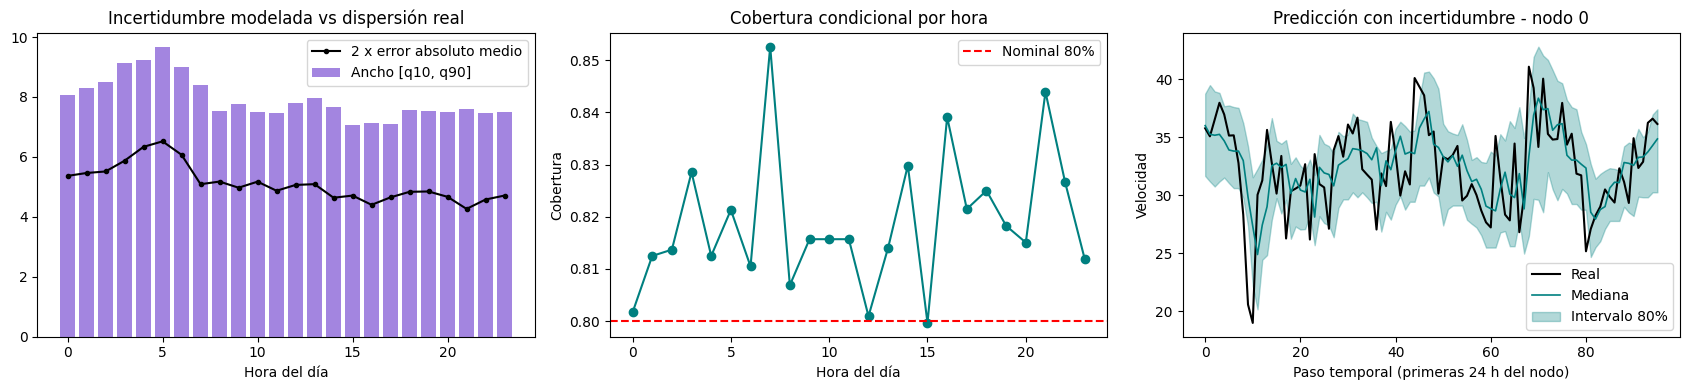

In [56]:
### Regresión por cuantiles: modelar la dispersión del error (heterocedasticidad)

import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

QUANTILES = [0.1, 0.5, 0.9]              # mediana + banda de incertidumbre al 80 %
NOMINAL = QUANTILES[-1] - QUANTILES[0]   # cobertura nominal del intervalo
QUANTILE_MODELS_DIR = "modelos_quantile_lightgbm"
FORCE_RETRAIN = False                    # True si cambian features o hiperparámetros
CAT_FEATURES = ["node_id", "hour", "dow"]  # debe coincidir con el modelo puntual
os.makedirs(QUANTILE_MODELS_DIR, exist_ok=True)

quantile_models = {}

for q in QUANTILES:
    path_q = os.path.join(QUANTILE_MODELS_DIR, f"modelo_q{round(q * 100):02d}.txt")
    params_q = {
        "objective": "quantile",
        "alpha": q,
        "metric": "quantile",
        "learning_rate": best_params.get("learning_rate", 0.05),
        "num_leaves": best_params.get("num_leaves", 63),
        "min_data_in_leaf": best_params.get("min_data_in_leaf", 50),
        "verbose": -1,
    }

    if os.path.exists(path_q) and not FORCE_RETRAIN:
        print(f"Cuantil {q}: modelo encontrado, cargando.")
        model_q = lgb.Booster(model_file=path_q)
    else:
        print(f"Cuantil {q}: entrenando desde cero.")
        ds_train = lgb.Dataset(train_df[feature_cols], label=train_df[target_col],
                               categorical_feature=CAT_FEATURES,
                               params={"feature_pre_filter": False})
        ds_valid = lgb.Dataset(valid_df[feature_cols], label=valid_df[target_col],
                               reference=ds_train,
                               params={"feature_pre_filter": False})
        model_q = lgb.train(params_q, ds_train, num_boost_round=2000,
                            valid_sets=[ds_valid],
                            callbacks=[lgb.early_stopping(100, verbose=False)])
        model_q.save_model(path_q, num_iteration=model_q.best_iteration)

    quantile_models[q] = model_q

def predict_quantiles(df):
    """Predice los cuantiles y los reordena para evitar cruces (sort por fila)."""
    # un modelo cargado desde archivo tiene best_iteration = 0 y usa todos sus árboles
    P = np.column_stack([quantile_models[q].predict(df[feature_cols],
                         num_iteration=quantile_models[q].best_iteration or None)
                         for q in QUANTILES])
    return np.sort(P, axis=1)

P_test = predict_quantiles(test_df)
P_valid = predict_quantiles(valid_df)
q_low, q_mid, q_high = P_test[:, 0], P_test[:, 1], P_test[:, -1]
y = test_df[target_col].values

# ------------------------------------------------------------
# Métricas del intervalo
# ------------------------------------------------------------
def interval_score(y, lo, hi, nominal):
    a = 1 - nominal
    return np.mean((hi - lo) + (2 / a) * (lo - y) * (y < lo) + (2 / a) * (y - hi) * (y > hi))

def pinball_loss(y, pred, q):
    d = y - pred
    return np.mean(np.maximum(q * d, (q - 1) * d))

coverage = np.mean((y >= q_low) & (y <= q_high))
below, above = np.mean(y < q_low), np.mean(y > q_high)
width = q_high - q_low

# Baseline de ancho constante: q50 +/- c, con c calibrado en Valid
c = np.quantile(np.abs(valid_df[target_col].values - P_valid[:, 1]), NOMINAL)
lo_c, hi_c = q_mid - c, q_mid + c

print("=" * 72)
print("EVALUACIÓN DE LA REGRESIÓN POR CUANTILES (test)")
print("=" * 72)
print(f"Cobertura empírica [q10, q90] (nominal {NOMINAL:.0%}): {coverage:.1%}")
print(f"  Por debajo de q10: {below:.1%} (esperado 10 %) | Por encima de q90: {above:.1%} (esperado 10 %)")
print(f"Ancho promedio: {width.mean():.3f}")
for i, q in enumerate(QUANTILES):
    print(f"Pinball loss (q={q}): {pinball_loss(y, P_test[:, i], q):.4f}")

print("\nComparación con intervalo de ancho constante (calibrado en Valid):")
print(f"  Cuantiles   -> cobertura {coverage:.1%} | ancho {width.mean():.3f} | "
      f"interval score {interval_score(y, q_low, q_high, NOMINAL):.3f}")
print(f"  Ancho fijo  -> cobertura {np.mean((y >= lo_c) & (y <= hi_c)):.1%} | "
      f"ancho {2 * c:.3f} | interval score {interval_score(y, lo_c, hi_c, NOMINAL):.3f}")
print("  (menor interval score = mejor; si no mejora al baseline, modelar la varianza no aporta)")

# ------------------------------------------------------------
# Verificación por hora: ancho vs dispersión real y cobertura condicional
# ------------------------------------------------------------
w_df = test_df[["hour"]].copy()
w_df["width"] = width
w_df["abs_err"] = np.abs(y - q_mid)
w_df["covered"] = (y >= q_low) & (y <= q_high)
by_hour = w_df.groupby("hour").agg(width=("width", "mean"),
                                   mae_median=("abs_err", "mean"),
                                   coverage=("covered", "mean"))

rho = by_hour["width"].corr(by_hour["mae_median"], method="spearman")
print(f"\nSpearman entre ancho medio y error absoluto medio por hora: {rho:+.3f}")
print(f"Cobertura por hora: mín {by_hour.coverage.min():.1%} | máx {by_hour.coverage.max():.1%}")
if "is_peak" in test_df.columns:
    print(f"Correlación ancho vs is_peak: {w_df['width'].corr(test_df['is_peak'].astype(float)):.3f}")

# ------------------------------------------------------------
# Gráficos
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].bar(by_hour.index, by_hour["width"], color="mediumpurple", alpha=0.85, label="Ancho [q10, q90]")
axes[0].plot(by_hour.index, 2 * by_hour["mae_median"], color="black", marker="o", ms=3,
             label="2 x error absoluto medio")
axes[0].set_xlabel("Hora del día")
axes[0].set_title("Incertidumbre modelada vs dispersión real")
axes[0].legend()

axes[1].plot(by_hour.index, by_hour["coverage"], marker="o", color="teal")
axes[1].axhline(NOMINAL, color="red", ls="--", label=f"Nominal {NOMINAL:.0%}")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("Cobertura")
axes[1].set_title("Cobertura condicional por hora")
axes[1].legend()

nodo = test_df["node_id"].iloc[0]
pred_df = test_df[["node_id"]].copy()
pred_df["y"], pred_df["lo"], pred_df["mid"], pred_df["hi"] = y, q_low, q_mid, q_high
g = pred_df[pred_df["node_id"] == nodo].sort_index().head(96)   # orden temporal real
axes[2].plot(range(len(g)), g["y"], color="black", lw=1.5, label="Real")
axes[2].plot(range(len(g)), g["mid"], color="teal", lw=1.2, label="Mediana")
axes[2].fill_between(range(len(g)), g["lo"], g["hi"], color="teal", alpha=0.3,
                     label=f"Intervalo {NOMINAL:.0%}")
axes[2].set_xlabel("Paso temporal (primeras 24 h del nodo)")
axes[2].set_ylabel("Velocidad")
axes[2].set_title(f"Predicción con incertidumbre - nodo {nodo}")
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretación**

1. **Incertidumbre modelada frente a dispersión real (izquierda).** El ancho del intervalo [q10, q90] y el doble del error absoluto medio (2 x MAE) siguen el mismo perfil horario: aumentan desde la medianoche, alcanzan su máximo entre las 4 y las 6 h (ancho cercano a 9.7 y 2 x MAE cercano a 6.5) y descienden después de las 7 h hasta una meseta (ancho entre 7 y 8, 2 x MAE entre 4.3 y 5.2). El modelo de cuantiles **captura la heterocedasticidad asociada a la hora del día**. El ancho equivale a 1.5 a 1.8 veces el 2 x MAE, coherente con las ~1.6 veces esperadas para un intervalo del 80 % con errores aproximadamente normales. La variación es moderada y no hay aumento del error en las horas punta de la tarde.

2. **Cobertura condicional por hora (centro).** La cobertura se mantiene entre 80 % y 85 % en todas las horas, en el nivel nominal o por encima, sin subcobertura relevante: los intervalos son **ligeramente conservadores**. El eje vertical está truncado (0.80 a 0.85), lo que exagera las fluctuaciones. La sobrecobertura es mayor donde el ancho es alto respecto al error (7 h y 21 h) y mínima donde es menor (15 h). Las diferencias de uno o dos puntos entre horas vecinas no son concluyentes sin un IC por bloques.

3. **Predicción con incertidumbre en el nodo 0 (derecha).** La mayoría de las observaciones queda dentro de la banda y la mediana sigue la tendencia, pero suaviza los cambios bruscos. La caída más pronunciada (paso 10, velocidad cercana a 19) queda bajo el límite inferior y algunos picos (pasos 45 y 68 a 72) tocan o superan el superior. Esto es esperable en una banda que por diseño deja fuera el 20 %, pero muestra que **los eventos abruptos de congestión no se anticipan**. Un nodo y 24 horas son una ilustración, no evidencia de calibración.

````{admonition} Lectura
:class: tip
El ancho del intervalo [q10, q90] **sigue el perfil horario del error** (máximo entre las 4 y las 6 h) y la **cobertura condicional se mantiene entre 80 % y 85 %** en todas las horas: el modelo captura la heterocedasticidad horaria y produce intervalos calibrados y algo conservadores. La mayor incertidumbre ocurre en la madrugada y no en las horas punta, lo que sugiere, como hipótesis a verificar por nodo y por día, una transición entre flujo libre e inicio de la congestión. Como la variación del ancho es moderada, su utilidad frente a un intervalo de ancho constante debe confirmarse con el interval score. Los eventos bruscos quedan fuera de la banda; para mejorar su cobertura conviene añadir volatilidad reciente (`rollstd_4`) o aplicar calibración conformal de cuantiles.
````

### Demostración sintética: ¿cuándo aporta la señal espacial? Moran's I y comparación de modelos

```{admonition} Objetivo
:class: tip
Mostrar, con datos simulados donde se conoce el mecanismo generador, que la ventaja de un modelo espacio-temporal (LightGBM con feature engineering espacial) **no es incondicional**, sino que depende de que exista dependencia espacial verificable. Para ello se generan dos escenarios (adyacencia aleatoria sin señal espacial y un proceso espacial autorregresivo real), se cuantifica la autocorrelación espacial con el I de Moran y se compara la persistencia ingenua, ARIMA(2,0,2) por nodo y LightGBM+FE. La sección justifica calcular Moran's I antes de elegir el modelo (Secciones 2.1.2 y 2.2.2).
```

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.spatial.distance import cdist
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

def moran_I_fast(x, A):
    x = np.asarray(x, dtype=float); Nn = len(x)
    xc = x - x.mean()
    return (Nn / A.sum()) * (xc @ A @ xc) / np.sum(xc**2)

# ---------- Escenario A: matriz de adyacencia ALEATORIA (sin señal espacial real) ----------
np.random.seed(0)
N_a, T_a = 60, 800
A_random = (np.random.rand(N_a, N_a) < 0.05).astype(float)
np.fill_diagonal(A_random, 0)
A_random = np.maximum(A_random, A_random.T)

t_a = np.arange(T_a)
seasonal_a = 10*np.sin(2*np.pi*t_a/96)
speed_random = 30 + seasonal_a[:,None] + np.random.randn(T_a, N_a)*3
speed_random_df = pd.DataFrame(speed_random, columns=[f"node_{i}" for i in range(N_a)])
sample_t = np.random.choice(T_a, 30, replace=False)
moran_random = np.mean([moran_I_fast(speed_random_df.iloc[tt].values, A_random) for tt in sample_t])

# ---------- Escenario B: proceso espacial autorregresivo REAL (vecinos importan) ----------
np.random.seed(1)
N_b, T_b = 60, 2000
coords = np.random.rand(N_b, 2) * 10
A_geo = (cdist(coords, coords) < 2.5).astype(float)
np.fill_diagonal(A_geo, 0)
A_geo_norm = A_geo / (A_geo.sum(axis=1, keepdims=True) + 1e-8)

t_b = np.arange(T_b)
seasonal_b = 10*np.sin(2*np.pi*t_b/96)
node_level = np.random.randn(N_b) * 5
common_shock = np.zeros((T_b, N_b))
common_shock[0] = np.random.randn(N_b)
rho = 0.85
for tt in range(1, T_b):
    common_shock[tt] = rho*(common_shock[tt-1] @ A_geo_norm.T) + (1-rho)*np.random.randn(N_b)
speed_spatial = 30 + node_level[None,:] + seasonal_b[:,None] + common_shock*6 + np.random.randn(T_b,N_b)*1.0
speed_spatial_df = pd.DataFrame(speed_spatial, columns=[f"node_{i}" for i in range(N_b)])
sample_t_b = np.random.choice(T_b, 40, replace=False)
moran_spatial = np.mean([moran_I_fast(speed_spatial_df.iloc[tt].values, A_geo) for tt in sample_t_b])

print(f"Escenario A (adyacencia aleatoria):      Moran's I ≈ {moran_random:.4f}  (≈0 esperado, sin señal espacial)")
print(f"Escenario B (proceso espacial real):     Moran's I ≈ {moran_spatial:.4f}  (>0, señal espacial real presente)")

Escenario A (adyacencia aleatoria):      Moran's I ≈ 0.0050  (≈0 esperado, sin señal espacial)
Escenario B (proceso espacial real):     Moran's I ≈ 0.0831  (>0, señal espacial real presente)


In [58]:
def moran_panel_test(df, A, instants, n_perm=499, seed=0):
    """Prueba de permutaciones para el I de Moran promediado sobre instantes.
    H0: en cada instante, los valores están distribuidos al azar entre nodos."""
    rng = np.random.default_rng(seed)
    X = df.iloc[instants].values                       # (instantes, nodos)
    mean_obs = np.mean([moran_I_fast(x, A) for x in X])
    mean_perm = np.array([
        np.mean([moran_I_fast(rng.permutation(x), A) for x in X])
        for _ in range(n_perm)
    ])
    p = (1 + np.sum(mean_perm >= mean_obs)) / (n_perm + 1)   # unilateral: autocorrelación positiva
    return mean_obs, mean_perm.mean(), mean_perm.std(), p

for label, df, A, idx in [("A", speed_random_df, A_random, sample_t),
                          ("B", speed_spatial_df, A_geo, sample_t_b)]:
    m, e, s, p = moran_panel_test(df, A, idx)
    print(f"Escenario {label}: I medio = {m:.4f} | media nula = {e:.4f} | "
          f"DE nula = {s:.4f} | z = {(m - e) / s:.1f} | p = {p:.4f}")

Escenario A: I medio = 0.0050 | media nula = -0.0163 | DE nula = 0.0130 | z = 1.6 | p = 0.0540
Escenario B: I medio = 0.0831 | media nula = -0.0167 | DE nula = 0.0097 | z = 10.3 | p = 0.0020


**Conclusión: diagnóstico de dependencia espacial (I de Moran).**

| Escenario | $I$ medio | Media nula | DE nula | $z$ | $p$ (permutaciones) | Interpretación del $p$-valor |
|---|---|---|---|---|---|---|
| A (adyacencia aleatoria) | 0.0050 | -0.0163 | 0.0130 | 1.6 | 0.054 | $p > 0.05$: **no se rechaza $H_0$** al 5 %. No hay evidencia suficiente de autocorrelación espacial, aunque el valor es marginal. No demuestra ausencia de señal, solo que el $I$ observado es compatible con el azar. |
| B (proceso espacial autorregresivo) | 0.0831 | -0.0167 | 0.0097 | 10.3 | $\leq$ 0.002 | $p < 0.05$ y $p < 0.01$: **se rechaza $H_0$**. Evidencia contundente de autocorrelación espacial positiva. El valor 0.002 es el mínimo alcanzable con 499 permutaciones, por lo que se reporta como cota superior. |

```{admonition} Conclusión
:class: tip
El I de Moran **discrimina los dos escenarios simulados**. En el **Escenario A**, $I \approx 0.005$ **no alcanza significancia** ($z = 1.6$, $p = 0.054$) y su distancia respecto a la media nula (0.021) es trivial, en coherencia con una adyacencia aleatoria sin señal espacial. Que $p$ quede cerca de 0.05 recuerda que la decisión es probabilística y no un umbral rígido. En el **Escenario B**, $I \approx 0.083$ es **claramente significativo** ($z = 10.3$, $p \leq 0.002$, el mínimo alcanzable con 499 permutaciones), lo que evidencia **autocorrelación espacial positiva de magnitud débil**. Esta magnitud es esperable, porque el nivel fijo por nodo, el ruido idiosincrático y una matriz binaria con muchos vecinos diluyen el estadístico.

La decisión se basa en la **significancia** ($p < 0.05$ e $I > E[I]$) y no en un umbral fijo de $I$: un $I$ débil puede ser estadísticamente inequívoco. Detectar dependencia espacial es una condición **necesaria pero no suficiente** para que las variables espaciales mejoren la predicción: la ventaja de LightGBM+FE sobre ARIMA no creció del Escenario A al B (2.7 % y 1.4 %). Por ello, el I de Moran se calcula **antes** de justificar el modelo espacial, y la ganancia predictiva incremental debe confirmarse con una ablación (LightGBM con y sin `neighbor_avg_lag1`).
```

In [44]:
def build_features_diag(speed_df, A, lags=(1,4,96), roll_windows=(4,96)):
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T
    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        d = pd.DataFrame(index=speed_df.index)
        d["y"] = speed_df[node]
        d["node_id"] = node_idx
        for lag in lags:
            d[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            d[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            d[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()
        d["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)
        d["hour"] = d.index.hour
        d["dow"] = d.index.dayofweek
        d["is_weekend"] = (d["dow"]>=5).astype(int)
        d["is_peak"] = d["hour"].isin([7,8,17,18]).astype(int)
        frames.append(d)
    return pd.concat(frames).dropna()

def compare_models(speed_df, A, label):
    speed_df = speed_df.copy()
    speed_df.index = pd.date_range("2020-01-01", periods=len(speed_df), freq="15min")
    feats = build_features_diag(speed_df, A)
    fcols = [c for c in feats.columns if c!="y"]
    cutoff = feats.index.unique()[int(len(feats.index.unique())*0.8)]
    tr, te = feats[feats.index<cutoff], feats[feats.index>=cutoff]

    dtr = lgb.Dataset(tr[fcols], label=tr["y"], categorical_feature=["node_id","hour","dow"])
    m = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                    "num_leaves":63,"min_data_in_leaf":50,"verbose":-1}, dtr, num_boost_round=200)
    mae_gbm = mean_absolute_error(te["y"], m.predict(te[fcols]))
    mae_naive = mean_absolute_error(te["y"], te["lag_1"])

    arima_maes = []
    for node in np.random.choice(speed_df.columns, 6, replace=False):
        s = speed_df[node]
        tr_s, te_s = s[s.index<cutoff], s[s.index>=cutoff]
        try:
            fit = ARIMA(tr_s, order=(2,0,2)).fit()
            fc = fit.forecast(steps=len(te_s))
            arima_maes.append(mean_absolute_error(te_s.values, fc.values))
        except Exception:
            pass

    print(f"\n--- {label} ---")
    print(f"{'Naive persistence':<32}{mae_naive:>8.3f}")
    print(f"{'ARIMA(2,0,2) por nodo':<32}{np.mean(arima_maes):>8.3f}")
    print(f"{'LightGBM + FE':<32}{mae_gbm:>8.3f}")
    ganador = min([("Naive", mae_naive), ("ARIMA", np.mean(arima_maes)), ("LightGBM+FE", mae_gbm)], key=lambda x: x[1])
    print(f"  -> Gana: {ganador[0]}")
    return mae_naive, np.mean(arima_maes), mae_gbm

import lightgbm as lgb
res_A = compare_models(speed_random_df, A_random, f"Escenario A: sin señal espacial (Moran's I≈{moran_random:.3f})")
res_B = compare_models(speed_spatial_df, A_geo, f"Escenario B: con señal espacial real (Moran's I≈{moran_spatial:.3f})")



--- Escenario A: sin señal espacial (Moran's I≈0.005) ---
Naive persistence                  3.417
ARIMA(2,0,2) por nodo              2.536
LightGBM + FE                      2.468
  -> Gana: LightGBM+FE

--- Escenario B: con señal espacial real (Moran's I≈0.083) ---
Naive persistence                  1.589
ARIMA(2,0,2) por nodo              1.158
LightGBM + FE                      1.142
  -> Gana: LightGBM+FE


| Escenario | Naive | ARIMA(2,0,2) | LightGBM + FE | ARIMA vs. naive | LightGBM+FE vs. naive | LightGBM+FE vs. ARIMA |
|---|---|---|---|---|---|---|
| A (Moran's I ≈ 0.005) | 3.417 | 2.536 | 2.468 | 25.8 % | 27.8 % | 2.7 % |
| B (Moran's I ≈ 0.083) | 1.589 | 1.158 | 1.142 | 27.1 % | 28.1 % | 1.4 % |

* **Escenario A (sin estructura espacial):** LightGBM+FE obtiene el menor error, pero su ventaja sobre ARIMA es de apenas 0.068 (2.7 %). Ambos modelos reducen en más de 25 % el error de la persistencia.
* **Escenario B (proceso espacial autorregresivo):** LightGBM+FE vuelve a ganar, con un margen **aún menor** (0.016, 1.4 %). La mejora frente a la persistencia es casi idéntica en ambos escenarios (26 % a 28 %).

**Lectura:** la ventaja de LightGBM+FE es **pequeña y no crece con la señal espacial**. Como también gana en A, es plausible que provenga de los componentes temporales del feature engineering (rezagos, calendario) y no de las variables espaciales. El menor error absoluto de B no indica una señal más predecible, porque los escenarios son conjuntos simulados distintos; solo la mejora relativa es comparable. Un $I \approx 0.083$ es de magnitud débil, aunque significativo ($p \leq 0.002$).

**Limitaciones:** cada escenario tiene una única realización y no incluye intervalos de confianza, por lo que diferencias de 0.016 a 0.068 no sustentan superioridad estadística. ARIMA se evaluó con pronóstico multipaso y LightGBM a un paso, lo que sesga la comparación. Se recomienda: (i) repetir con múltiples semillas y reportar media e IC 95 %; (ii) aplicar la prueba de Diebold-Mariano; (iii) hacer una ablación (feature engineering solo temporal frente a temporal más espacial); y (iv) variar la intensidad de la autocorrelación espacial.

```{admonition} Lección metodológica
:class: tip
La superioridad de GBM+FE **no es incondicional**: requiere evidencia verificable de dependencia espacial (Moran's I significativo, Sección 1.2) y que el componente espacial aporte información incremental. Por eso se calcula Moran's I **antes** de justificar el modelo (Secciones 1.2 y 2.2). Que ARIMA iguale o supere a GBM+FE no es un fracaso del pipeline, sino evidencia legítima de dependencia espacial débil, y reportarlo es el estándar de rigor exigido en una tesis o publicación indexada. [[Roberts et al., 2017](biblio.html#id125)] advierten que ignorar la estructura de dependencia produce estimaciones de error optimistas, por lo que debe verificarse y tratarse explícitamente.
```